In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.metrics import roc_auc_score, mean_squared_error

# 1. 데이터 로드 [cite: 9]
train_cust = pd.read_csv('/Users/rim/Desktop/workspace/project_1/train/train_customer_info.csv')
train_trans = pd.read_csv('/Users/rim/Desktop/workspace/project_1/train/train_transaction_history.csv')
train_fin = pd.read_csv('/Users/rim/Desktop/workspace/project_1/train/train_finance_profile.csv')
train_target = pd.read_csv('/Users/rim/Desktop/workspace/project_1/train/train_targets.csv')


train_cust.head()
train_trans.head()
train_fin.head()


,customer_id,credit_score,num_active_cards,total_deposit_balance,total_loan_balance,card_cash_service_amt,card_loan_amt,fin_overdue_days,fin_asset_trend_score
0,C000001,713,6,2517740,58608891,100572,65339,0,0.551107
1,C000002,869,5,679696,33403843,210018,0,0,-0.342776
2,C000003,588,2,17319511,0,4092,0,1,-0.949003
3,C000004,742,3,984771,0,0,0,0,-0.348409
4,C000006,611,5,1098491,1668819,0,238071,0,0.647922


In [4]:
train_fin.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            60000 non-null  str    
 1   credit_score           60000 non-null  int64  
 2   num_active_cards       60000 non-null  int64  
 3   total_deposit_balance  60000 non-null  int64  
 4   total_loan_balance     60000 non-null  int64  
 5   card_cash_service_amt  60000 non-null  int64  
 6   card_loan_amt          60000 non-null  int64  
 7   fin_overdue_days       60000 non-null  int64  
 8   fin_asset_trend_score  60000 non-null  float64
dtypes: float64(1), int64(7), str(1)
memory usage: 4.1 MB


In [5]:
train_cust.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   customer_id      60000 non-null  str  
 1   join_date        60000 non-null  str  
 2   age              60000 non-null  int64
 3   gender           60000 non-null  str  
 4   region_code      60000 non-null  str  
 5   is_married       60000 non-null  int64
 6   prefer_category  60000 non-null  str  
 7   income_group     60000 non-null  str  
dtypes: int64(2), str(6)
memory usage: 3.7 MB


In [6]:
train_target.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   customer_id   60000 non-null  str    
 1   target_churn  60000 non-null  int64  
 2   target_ltv    60000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.4 MB


In [17]:
def preprocess_data(train_cust, train_trans, train_fin):
    # (1) 트랜잭션 데이터 집계 (고객 ID 기준) [cite: 14]
    trans_agg = trans.groupby('customer_id').agg({
        'trans_id': 'count',
        'trans_amount': ['sum', 'mean', 'max'],
        'is_installment': 'mean'
    }).reset_index()
    trans_agg.columns = ['customer_id', 'total_trans_cnt', 'total_amt', 'avg_amt', 'max_amt', 'installment_ratio']
    
trans_egg


NameError: name 'trans_egg' is not defined

In [19]:
def preprocess_data(train_cust, train_trans, train_fin):
    # 함수 내부에서도 'train_trans'라는 이름을 그대로 사용해야 합니다.
    trans_agg = train_trans.groupby('customer_id').agg({
        'trans_id': 'count',
        'trans_amount': ['sum', 'mean', 'max'],
        'is_installment': 'mean'
    }).reset_index()
    
    # 컬럼명 설정 (Source 9, 14 참고) [cite: 9, 14]
    trans_agg.columns = ['customer_id', 'total_trans_cnt', 'total_amt', 'avg_amt', 'max_amt', 'installment_ratio']
    
    # (2) 테이블 결합 (Source 5 참고) 
    # 고객 정보(cust)를 기준으로 금융(fin)과 집계된 구매이력(trans_agg)을 합칩니다.
    df = pd.merge(train_cust, train_fin, on='customer_id', how='left')
    df = pd.merge(df, trans_agg, on='customer_id', how='left')
    
    return df

# 실제 실행 시 (정의한 이름대로 넣어주세요)
train_df = preprocess_data(train_cust, train_trans, train_fin)
train_df.head()

,customer_id,join_date,age,gender,region_code,is_married,prefer_category,income_group,credit_score,num_active_cards,...,total_loan_balance,card_cash_service_amt,card_loan_amt,fin_overdue_days,fin_asset_trend_score,total_trans_cnt,total_amt,avg_amt,max_amt,installment_ratio
0,C000001,2020-04-12,36,F,R03,1,Grocery,G4,713,6,...,58608891,100572,65339,0,0.551107,21,1087476,51784.571429,227979,0.238095
1,C000002,2021-03-11,32,F,R02,0,Home,G3,869,5,...,33403843,210018,0,0,-0.342776,14,922154,65868.142857,266110,0.000000
2,C000003,2022-05-10,41,M,R03,1,Fashion,G3,588,2,...,0,4092,0,1,-0.949003,16,812618,50788.625000,166157,0.375000
3,C000004,2020-09-27,23,F,R02,1,Electronics,G3,742,3,...,0,0,0,0,-0.348409,22,1237060,56230.000000,242701,0.136364
4,C000006,2020-03-12,31,F,R04,0,Grocery,G3,611,5,...,1668819,0,238071,0,0.647922,14,1034043,73860.214286,227673,0.285714


In [21]:
trans_agg = train_trans.groupby('customer_id').agg({
    'trans_id': 'count',                       # 총 방문 횟수
    'trans_amount': ['sum', 'mean', 'max', 'std'], # std: 지출 변동성(들쑥날쑥한 정도) 추가
    'is_installment': 'sum',                   # 총 할부 이용 건수
    'biz_type': lambda x: (x == 'Online').mean(), # 온라인 구매 비율
    'trans_date': lambda x: (pd.to_datetime('2023-12-31') - pd.to_datetime(x.max())).days # 최신성(마지막 구매 후 경과일)
}).reset_index()

# 컬럼명 재설정
trans_agg.columns = [
    'customer_id', 'cnt', 'amt_sum', 'amt_mean', 'amt_max', 'amt_std', 
    'inst_cnt', 'online_ratio', 'recency'
]

In [22]:
trans_agg.head()

,customer_id,cnt,amt_sum,amt_mean,amt_max,amt_std,inst_cnt,online_ratio,recency
0,C000001,21,1087476,51784.571429,227979,50531.090126,5,0.571429,4
1,C000002,14,922154,65868.142857,266110,65206.573884,0,0.500000,2
2,C000003,16,812618,50788.625000,166157,42843.526573,6,0.625000,0
3,C000004,22,1237060,56230.000000,242701,55769.670758,3,0.545455,7
4,C000006,14,1034043,73860.214286,227673,50926.975968,4,0.357143,36


In [75]:
def preprocess_data(train_cust, train_trans, train_fin):
    # 첫 번째 코드의 심화 집계 방식을 함수 안에 넣습니다.
    trans_agg = train_trans.groupby('customer_id').agg({
        'trans_id': 'count',
        'trans_amount': ['sum', 'mean', 'max', 'std'],
        'is_installment': 'sum',
        'biz_type': lambda x: (x == 'Online').mean(),
        'trans_date': lambda x: (pd.to_datetime('2023-12-31') - pd.to_datetime(x.max())).days
    }).reset_index()
    
    # 컬럼명 설정
    trans_agg.columns = ['customer_id', 'cnt', 'amt_sum', 'amt_mean', 'amt_max', 'amt_std', 
                         'inst_cnt', 'online_ratio', 'recency']
    
    # 테이블 결합 
    df = pd.merge(train_cust, train_fin, on='customer_id', how='left')
    df = pd.merge(df, trans_agg, on='customer_id', how='left')
    
    return df

# 함수를 실행하고 그 결과(return df)를 'train_df'라는 이름의 변수에 저장합니다.
train_df = preprocess_data(train_cust, train_trans, train_fin)

# 이제 'train_df'라는 이름으로 데이터를 확인합니다.
print(train_df.head())

  customer_id   join_date  age gender region_code  is_married prefer_category  \
0     C000001  2020-04-12   36      F         R03           1         Grocery   
1     C000002  2021-03-11   32      F         R02           0            Home   
2     C000003  2022-05-10   41      M         R03           1         Fashion   
3     C000004  2020-09-27   23      F         R02           1     Electronics   
4     C000006  2020-03-12   31      F         R04           0         Grocery   

  income_group  credit_score  num_active_cards  ...  fin_overdue_days  \
0           G4           713                 6  ...                 0   
1           G3           869                 5  ...                 0   
2           G3           588                 2  ...                 1   
3           G3           742                 3  ...                 0   
4           G3           611                 5  ...                 0   

   fin_asset_trend_score  cnt  amt_sum      amt_mean  amt_max       amt_st

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.metrics import roc_auc_score, mean_squared_error

# 1. 데이터 로드 [cite: 9]
train_cust = pd.read_csv('/Users/rim/Desktop/workspace/project_1/train/train_customer_info.csv')
train_trans = pd.read_csv('/Users/rim/Desktop/workspace/project_1/train/train_transaction_history.csv')
train_fin = pd.read_csv('/Users/rim/Desktop/workspace/project_1/train/train_finance_profile.csv')
train_target = pd.read_csv('/Users/rim/Desktop/workspace/project_1/train/train_targets.csv')


train_df = preprocess_data(train_cust, train_trans, train_fin)

# 2. 여기에 정답(target)까지 바로 붙여버리기
train_master = pd.merge(train_df, train_target, on='customer_id', how='left')

# 숫자로 바꿀 컬럼 리스트 [cite: 12]
cat_cols = ['gender', 'region_code', 'prefer_category', 'income_group']

for col in cat_cols:
    le = LabelEncoder()
    # Train 데이터 학습 및 변환
    train_master[col] = le.fit_transform(train_master[col].astype(str))
    print(f"{col} 변환 완료")


train_master['join_date'] = pd.to_datetime(train_master['join_date'])

# 가입 후 경과일(Days) 계산
reference_date = pd.to_datetime('2023-12-31')
train_master['days_since_joined'] = (reference_date - train_master['join_date']).dt.days

# 원본 날짜 컬럼은 삭제
train_master.drop('join_date', axis=1, inplace=True)


In [76]:
# 1. 아까 만든 preprocess_data로 3개 테이블 병합
train_df = preprocess_data(train_cust, train_trans, train_fin)

# 2. 여기에 정답(target)까지 바로 붙여버리기
train_master = pd.merge(train_df, train_target, on='customer_id', how='left')

In [77]:
train_master.head()

,customer_id,join_date,age,gender,region_code,is_married,prefer_category,income_group,credit_score,num_active_cards,...,cnt,amt_sum,amt_mean,amt_max,amt_std,inst_cnt,online_ratio,recency,target_churn,target_ltv
0,C000001,2020-04-12,36,F,R03,1,Grocery,G4,713,6,...,21,1087476,51784.571429,227979,50531.090126,5,0.571429,4,0,556691.00
1,C000002,2021-03-11,32,F,R02,0,Home,G3,869,5,...,14,922154,65868.142857,266110,65206.573884,0,0.500000,2,0,1460203.00
2,C000003,2022-05-10,41,M,R03,1,Fashion,G3,588,2,...,16,812618,50788.625000,166157,42843.526573,6,0.625000,0,0,605476.00
3,C000004,2020-09-27,23,F,R02,1,Electronics,G3,742,3,...,22,1237060,56230.000000,242701,55769.670758,3,0.545455,7,0,1034150.00
4,C000006,2020-03-12,31,F,R04,0,Grocery,G3,611,5,...,14,1034043,73860.214286,227673,50926.975968,4,0.357143,36,1,76083.15


In [33]:
train_master.isnull().sum()

customer_id              0
join_date                0
age                      0
gender                   0
region_code              0
is_married               0
prefer_category          0
income_group             0
credit_score             0
num_active_cards         0
total_deposit_balance    0
total_loan_balance       0
card_cash_service_amt    0
card_loan_amt            0
fin_overdue_days         0
fin_asset_trend_score    0
cnt                      0
amt_sum                  0
amt_mean                 0
amt_max                  0
amt_std                  0
inst_cnt                 0
online_ratio             0
recency                  0
target_churn             0
target_ltv               0
dtype: int64

In [35]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            60000 non-null  str    
 1   join_date              60000 non-null  str    
 2   age                    60000 non-null  int64  
 3   gender                 60000 non-null  str    
 4   region_code            60000 non-null  str    
 5   is_married             60000 non-null  int64  
 6   prefer_category        60000 non-null  str    
 7   income_group           60000 non-null  str    
 8   credit_score           60000 non-null  int64  
 9   num_active_cards       60000 non-null  int64  
 10  total_deposit_balance  60000 non-null  int64  
 11  total_loan_balance     60000 non-null  int64  
 12  card_cash_service_amt  60000 non-null  int64  
 13  card_loan_amt          60000 non-null  int64  
 14  fin_overdue_days       60000 non-null  int64  
 15  fin_asset_tre

In [78]:
# 전처리
from sklearn.preprocessing import LabelEncoder

# 숫자로 바꿀 컬럼 리스트 [cite: 12]
cat_cols = ['gender', 'region_code', 'prefer_category', 'income_group']

for col in cat_cols:
    le = LabelEncoder()
    # Train 데이터 학습 및 변환
    train_master[col] = le.fit_transform(train_master[col].astype(str))
    print(f"{col} 변환 완료")

gender 변환 완료
region_code 변환 완료
prefer_category 변환 완료
income_group 변환 완료


In [79]:
train_master

,customer_id,join_date,age,gender,region_code,is_married,prefer_category,income_group,credit_score,num_active_cards,...,cnt,amt_sum,amt_mean,amt_max,amt_std,inst_cnt,online_ratio,recency,target_churn,target_ltv
0,C000001,2020-04-12,36,0,2,1,3,3,713,6,...,21,1087476,51784.571429,227979,50531.090126,5,0.571429,4,0,556691.00
1,C000002,2021-03-11,32,0,1,0,4,2,869,5,...,14,922154,65868.142857,266110,65206.573884,0,0.500000,2,0,1460203.00
2,C000003,2022-05-10,41,1,2,1,2,2,588,2,...,16,812618,50788.625000,166157,42843.526573,6,0.625000,0,0,605476.00
3,C000004,2020-09-27,23,0,1,1,1,2,742,3,...,22,1237060,56230.000000,242701,55769.670758,3,0.545455,7,0,1034150.00
4,C000006,2020-03-12,31,0,3,0,3,2,611,5,...,14,1034043,73860.214286,227673,50926.975968,4,0.357143,36,1,76083.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,C099993,2021-01-11,23,0,5,1,2,3,616,6,...,23,1521949,66171.695652,253128,53217.159196,2,0.869565,3,0,2842492.00
59996,C099995,2020-07-06,34,1,2,0,3,4,584,2,...,23,1318712,57335.304348,144375,35072.923122,3,0.608696,5,0,541730.00
59997,C099996,2021-10-11,19,1,2,0,1,4,847,6,...,17,1211965,71292.058824,244018,65585.749338,0,0.647059,9,0,593719.00
59998,C099998,2022-05-13,33,1,1,1,2,2,899,3,...,20,1472751,73637.550000,280443,69718.674776,5,0.650000,13,0,3720969.00


In [80]:
# 문자열을 날짜 형태로 변환
train_master['join_date'] = pd.to_datetime(train_master['join_date'])

# 가입 후 경과일(Days) 계산
reference_date = pd.to_datetime('2023-12-31')
train_master['days_since_joined'] = (reference_date - train_master['join_date']).dt.days

# 원본 날짜 컬럼은 삭제
train_master.drop('join_date', axis=1, inplace=True)

In [47]:
train_master

,customer_id,age,gender,region_code,is_married,prefer_category,income_group,credit_score,num_active_cards,total_deposit_balance,...,amt_sum,amt_mean,amt_max,amt_std,inst_cnt,online_ratio,recency,target_churn,target_ltv,days_since_joined
0,C000001,36,0,2,1,3,3,713,6,2517740,...,1087476,51784.571429,227979,50531.090126,5,0.571429,4,0,556691.00,1358
1,C000002,32,0,1,0,4,2,869,5,679696,...,922154,65868.142857,266110,65206.573884,0,0.500000,2,0,1460203.00,1025
2,C000003,41,1,2,1,2,2,588,2,17319511,...,812618,50788.625000,166157,42843.526573,6,0.625000,0,0,605476.00,600
3,C000004,23,0,1,1,1,2,742,3,984771,...,1237060,56230.000000,242701,55769.670758,3,0.545455,7,0,1034150.00,1190
4,C000006,31,0,3,0,3,2,611,5,1098491,...,1034043,73860.214286,227673,50926.975968,4,0.357143,36,1,76083.15,1389
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,C099993,23,0,5,1,2,3,616,6,827808595,...,1521949,66171.695652,253128,53217.159196,2,0.869565,3,0,2842492.00,1084
59996,C099995,34,1,2,0,3,4,584,2,5095394,...,1318712,57335.304348,144375,35072.923122,3,0.608696,5,0,541730.00,1273
59997,C099996,19,1,2,0,1,4,847,6,1272279,...,1211965,71292.058824,244018,65585.749338,0,0.647059,9,0,593719.00,811
59998,C099998,33,1,1,1,2,2,899,3,32067940,...,1472751,73637.550000,280443,69718.674776,5,0.650000,13,0,3720969.00,597


In [48]:
train_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            60000 non-null  str    
 1   age                    60000 non-null  int64  
 2   gender                 60000 non-null  int64  
 3   region_code            60000 non-null  int64  
 4   is_married             60000 non-null  int64  
 5   prefer_category        60000 non-null  int64  
 6   income_group           60000 non-null  int64  
 7   credit_score           60000 non-null  int64  
 8   num_active_cards       60000 non-null  int64  
 9   total_deposit_balance  60000 non-null  int64  
 10  total_loan_balance     60000 non-null  int64  
 11  card_cash_service_amt  60000 non-null  int64  
 12  card_loan_amt          60000 non-null  int64  
 13  fin_overdue_days       60000 non-null  int64  
 14  fin_asset_trend_score  60000 non-null  float64
 15  cnt          

In [49]:
print(train_master.columns)

Index(['customer_id', 'age', 'gender', 'region_code', 'is_married',
       'prefer_category', 'income_group', 'credit_score', 'num_active_cards',
       'total_deposit_balance', 'total_loan_balance', 'card_cash_service_amt',
       'card_loan_amt', 'fin_overdue_days', 'fin_asset_trend_score', 'cnt',
       'amt_sum', 'amt_mean', 'amt_max', 'amt_std', 'inst_cnt', 'online_ratio',
       'recency', 'target_churn', 'target_ltv', 'days_since_joined'],
      dtype='str')


In [50]:
# 1. 학습에 사용할 재료 (X) - 필요 없는 열들은 여기서 뺍니다.
X = train_master.drop(['customer_id', 'target_churn', 'target_ltv'], axis=1)

# 2. 정답지 (y)
y_churn = train_master['target_churn']
y_ltv = train_master['target_ltv']

In [51]:
from sklearn.model_selection import train_test_split

# 이탈 예측(Churn)을 위한 모의고사 준비
X_train, X_val, y_train, y_val = train_test_split(X, y_churn, test_size=0.2, random_state=42, stratify=y_churn)

In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# 1. 모델 정의 및 학습
model_churn = RandomForestClassifier(n_estimators=100, random_state=42)
model_churn.fit(X_train, y_train)

# 2. 모의고사(X_val) 풀기
# [주의] Churn은 확률값으로 점수를 매기므로 predict_proba를 사용합니다.
val_probs = model_churn.predict_proba(X_val)[:, 1]

# 3. 내 모의고사 점수(AUC) 확인
auc_score = roc_auc_score(y_val, val_probs)
print(f"현재 내 모델의 이탈 예측 AUC 점수: {auc_score:.4f}")

현재 내 모델의 이탈 예측 AUC 점수: 0.7673


In [ ]:
import lightgbm as lgb

# 모델 정의 및 학습 (하이퍼파라미터는 기본값으로!)
model_lgb = lgb.LGBMClassifier(random_state=42, verbose=-1)
model_lgb.fit(X_train, y_train)

# 다시 모의고사 점수 확인
val_probs_lgb = model_lgb.predict_proba(X_val)[:, 1]
print(f"LightGBM AUC 점수: {roc_auc_score(y_val, val_probs_lgb):.4f}")


LightGBM AUC 점수: 0.7826


In [57]:
import lightgbm as lgb

# 모델 정의 및 학습 (하이퍼파라미터는 기본값으로!)
model_lgb = lgb.LGBMClassifier(n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    random_state=42)
model_lgb.fit(X_train, y_train)

# 다시 모의고사 점수 확인
val_probs_lgb = model_lgb.predict_proba(X_val)[:, 1]
print(f"LightGBM AUC 점수: {roc_auc_score(y_val, val_probs_lgb):.4f}")

LightGBM AUC 점수: 0.7750


In [61]:
import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation
from sklearn.metrics import roc_auc_score

model_lgb = lgb.LGBMClassifier(
    n_estimators=1000,      # 더 많이 공부하기
    learning_rate=0.02,     # 더 꼼꼼하게 학습하기 (보통 낮출수록 좋아짐)
    max_depth=7,            # 모델의 깊이 제한 (오버피팅 방지)
    num_leaves=64,          # 복잡한 규칙 찾기
    subsample=0.8,          # 데이터 일부만 무작위로 사용하여 다양성 확보
    colsample_bytree=0.8,   # 변수 일부만 사용하여 과적합 방지
    random_state=42
)

model_lgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    callbacks=[
        early_stopping(stopping_rounds=50), # 50번 동안 점수 안 오르면 중단
        log_evaluation(period=100)        # 100번마다 진행 상황 출력
    ]
)

val_probs_lgb = model_lgb.predict_proba(X_val)[:, 1]
print(f"LightGBM AUC 점수: {roc_auc_score(y_val, val_probs_lgb):.4f}")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.782592	valid_0's binary_logloss: 0.261359
[200]	valid_0's auc: 0.783795	valid_0's binary_logloss: 0.258203
Early stopping, best iteration is:
[200]	valid_0's auc: 0.783795	valid_0's binary_logloss: 0.258203
LightGBM AUC 점수: 0.7838


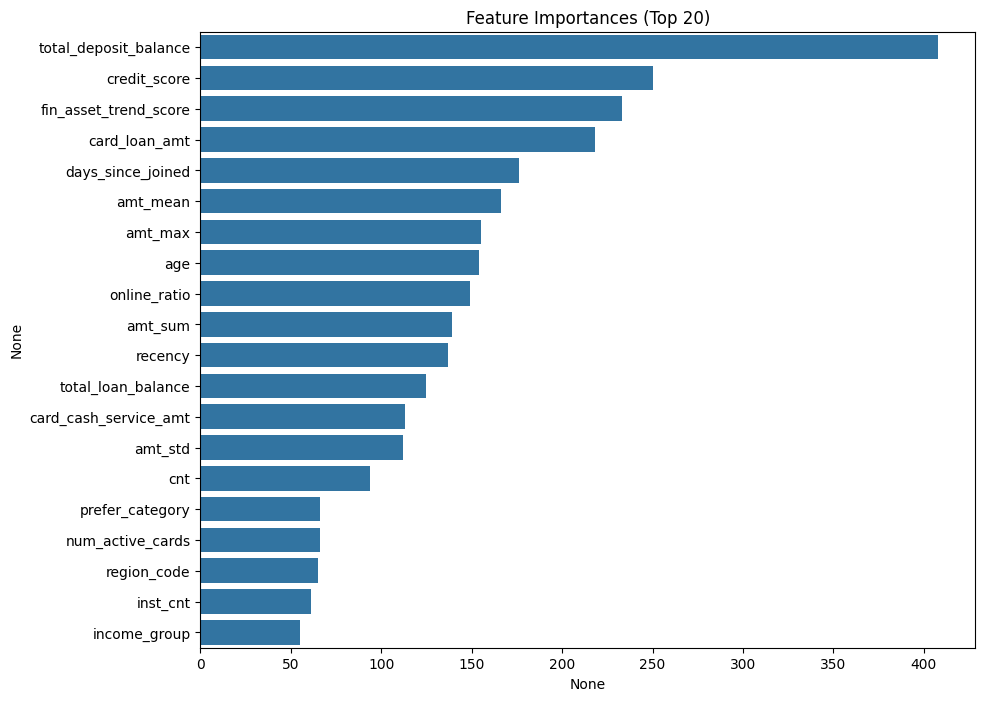

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# 변수 중요도 데이터프레임 만들기
ftr_importances_values = model_lgb.feature_importances_
ftr_importances = pd.Series(ftr_importances_values, index=X_train.columns)
ftr_top20 = ftr_importances.sort_values(ascending=False)[:20]

# 시각화
plt.figure(figsize=(10, 8))
sns.barplot(x=ftr_top20, y=ftr_top20.index)
plt.title('Feature Importances (Top 20)')
plt.show()

In [ ]:
model_lgb = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    random_state=42
)

In [62]:
# 영향력이 매우 낮은 변수 제거 예시
X_reduced = X.drop(['income_group', 'inst_cnt', 'region_code'], axis=1)

In [63]:
import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, mean_squared_error
import numpy as np

# 1. 영향력 낮은 변수 제거 (X_reduced 생성)
drop_cols = ['income_group', 'inst_cnt', 'region_code']
X_reduced = X.drop(drop_cols, axis=1)

# ---------------------------------------------------------
# TASK 1: 이탈 예측 (Churn - Classifier)
# ---------------------------------------------------------
print("--- Task 1: Churn 모델 학습 시작 ---")
X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(
    X_reduced, y_churn, test_size=0.2, random_state=42, stratify=y_churn
)

model_churn = lgb.LGBMClassifier(
    n_estimators=1000, learning_rate=0.02, max_depth=7, num_leaves=64, random_state=42, verbose=-1
)

model_churn.fit(
    X_train_c, y_train_c,
    eval_set=[(X_val_c, y_val_c)],
    eval_metric='auc',
    callbacks=[early_stopping(stopping_rounds=50), log_evaluation(period=100)]
)

churn_auc = roc_auc_score(y_val_c, model_churn.predict_proba(X_val_c)[:, 1])
print(f"최종 Churn AUC: {churn_auc:.4f}")

# ---------------------------------------------------------
# TASK 2: LTV 예측 (LTV - Regressor)
# ---------------------------------------------------------
print("\n--- Task 2: LTV 모델 학습 시작 ---")
X_train_l, X_val_l, y_train_l, y_val_l = train_test_split(
    X_reduced, y_ltv, test_size=0.2, random_state=42
)

model_ltv = lgb.LGBMRegressor(
    n_estimators=1000, learning_rate=0.02, max_depth=7, num_leaves=64, random_state=42, verbose=-1
)

model_ltv.fit(
    X_train_l, y_train_l,
    eval_set=[(X_val_l, y_val_l)],
    eval_metric='rmse',
    callbacks=[early_stopping(stopping_rounds=50), log_evaluation(period=100)]
)

ltv_rmse = np.sqrt(mean_squared_error(y_val_l, model_ltv.predict(X_val_l)))
print(f"최종 LTV RMSE: {ltv_rmse:.4f}")

--- Task 1: Churn 모델 학습 시작 ---
Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.784307	valid_0's binary_logloss: 0.25875
Early stopping, best iteration is:
[94]	valid_0's auc: 0.784662	valid_0's binary_logloss: 0.259002
최종 Churn AUC: 0.7847

--- Task 2: LTV 모델 학습 시작 ---
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 1.37646e+06	valid_0's l2: 1.89465e+12
Early stopping, best iteration is:
[99]	valid_0's rmse: 1.37644e+06	valid_0's l2: 1.89458e+12
최종 LTV RMSE: 1376437.1969


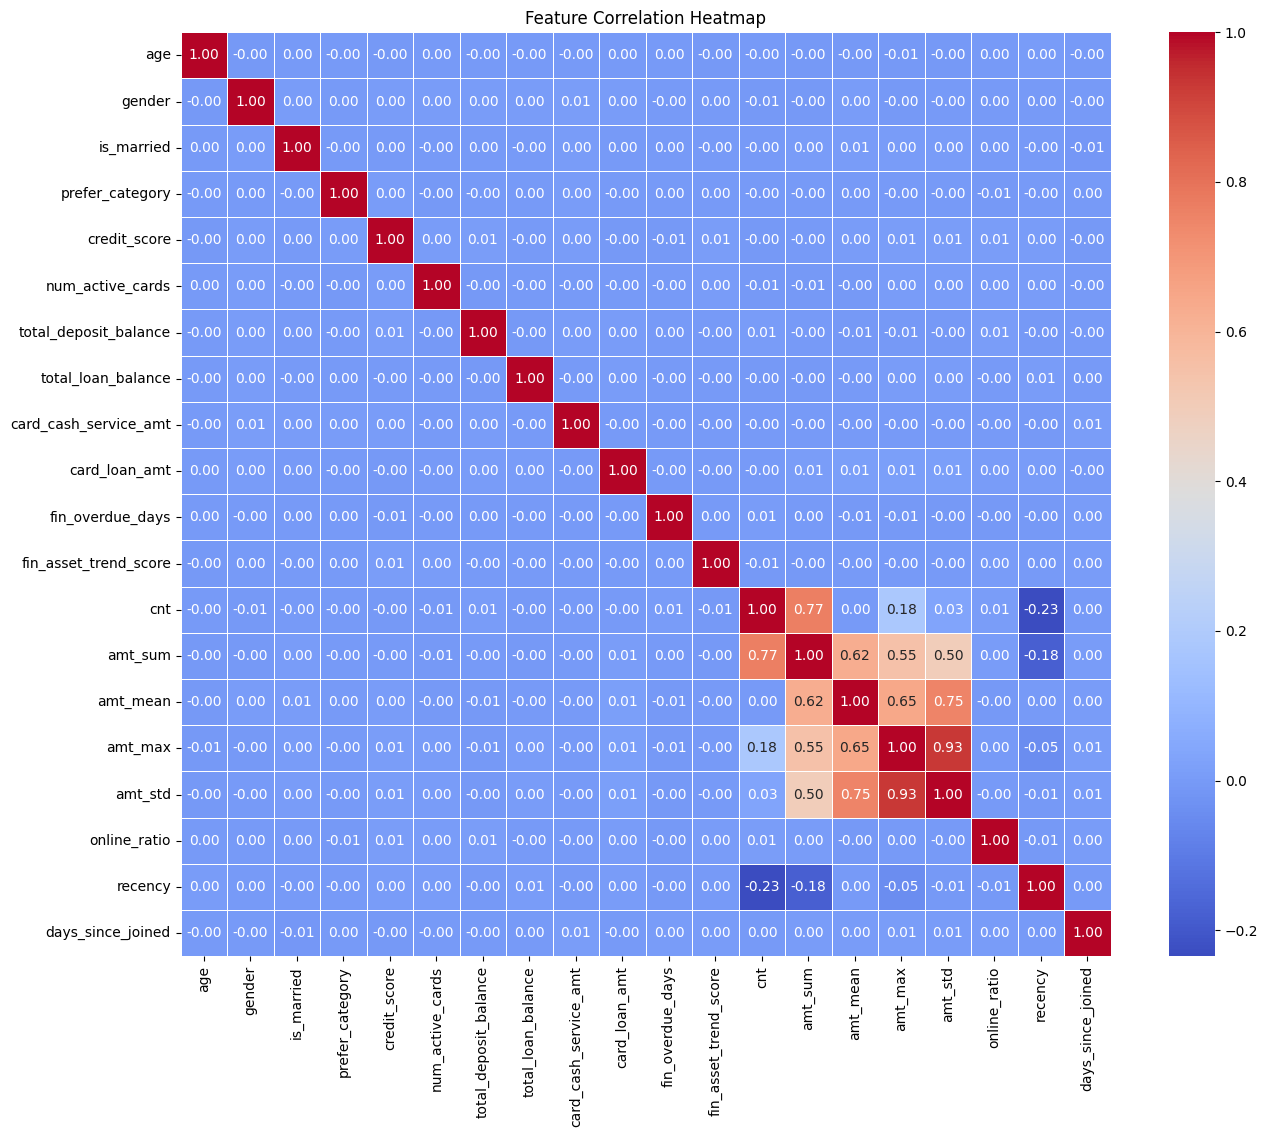

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 상관관계 행렬 계산 (숫자형 변수들만 대상)
# X_reduced에는 이미 인코딩된 숫자들만 있으니 바로 사용 가능합니다.
corr_matrix = X_reduced.corr()

# 2. 히트맵 그리기
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In [65]:

# 1. 정예 멤버 리스트 (중요도 높고 중복 적은 것들)
top_features = [
    'total_deposit_balance', 'credit_score', 'fin_asset_trend_score', 
    'card_loan_amt', 'days_since_joined', 'amt_mean', 'age', 
    'online_ratio', 'recency', 'total_loan_balance'
]

X_top = X_reduced[top_features]

# 2. 데이터 분할
X_train_t, X_val_t, y_train_t, y_val_t = train_test_split(
    X_top, y_churn, test_size=0.2, random_state=42, stratify=y_churn
)

# 3. 모델 학습 (LightGBM)
model_top = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=42, verbose=-1)
model_top.fit(
    X_train_t, y_train_t,
    eval_set=[(X_val_t, y_val_t)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(50)]
)

# 4. 점수 확인
top_auc = roc_auc_score(y_val_t, model_top.predict_proba(X_val_t)[:, 1])
print(f"핵심 변수 {len(top_features)}개만 사용했을 때 AUC: {top_auc:.4f}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[49]	valid_0's auc: 0.778416	valid_0's binary_logloss: 0.261053
핵심 변수 10개만 사용했을 때 AUC: 0.7784


In [66]:
from catboost import CatBoostClassifier

# 1. 모델 정의
model_cat = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)

# 2. 학습 (CatBoost는 자체적으로 범주형 변수를 잘 처리하지만, 일단 숫자형으로 돌려봅니다)
model_cat.fit(
    X_train_t, y_train_t,
    eval_set=(X_val_t, y_val_t),
    early_stopping_rounds=50
)

# 3. 점수 확인
cat_auc = roc_auc_score(y_val_t, model_cat.predict_proba(X_val_t)[:, 1])
print(f"CatBoost AUC 점수: {cat_auc:.4f}")

0:	test: 0.7425536	best: 0.7425536 (0)	total: 62.5ms	remaining: 1m 2s
100:	test: 0.7785018	best: 0.7785018 (100)	total: 381ms	remaining: 3.39s
200:	test: 0.7794323	best: 0.7797892 (171)	total: 686ms	remaining: 2.73s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7802474682
bestIteration = 240

Shrink model to first 241 iterations.
CatBoost AUC 점수: 0.7802


In [67]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# 1. 데이터 준비 (모든 변수가 포함된 X_reduced 사용)
# 만약 아예 처음의 24개 변수를 쓰고 싶다면 X를 넣으시면 됩니다.
X_final = X_reduced 

X_train_f, X_val_f, y_train_f, y_val_f = train_test_split(
    X_final, y_churn, test_size=0.2, random_state=42, stratify=y_churn
)

# 2. CatBoost 풀파워 설정
model_cat_full = CatBoostClassifier(
    iterations=2000,            # 충분히 많이 학습하도록 설정
    learning_rate=0.03,         # 학습 속도를 조금 낮춰서 더 정교하게 학습
    depth=8,                    # 나무의 깊이를 조금 더 깊게 (복잡한 패턴 포착)
    l2_leaf_reg=5,              # 과적합 방지를 위한 규제 강화
    eval_metric='AUC',          # 목표 지표는 AUC
    random_seed=42,
    verbose=100                 # 100번마다 결과 출력
)

# 3. 모델 학습
model_cat_full.fit(
    X_train_f, y_train_f,
    eval_set=(X_val_f, y_val_f),
    early_stopping_rounds=100   # 100번 동안 개선 없으면 멈춤
)

# 4. 최종 점수 확인
final_cat_auc = roc_auc_score(y_val_f, model_cat_full.predict_proba(X_val_f)[:, 1])
print(f"\n[결과] CatBoost 모든 변수 사용 시 AUC: {final_cat_auc:.4f}")

0:	test: 0.7369668	best: 0.7369668 (0)	total: 7.57ms	remaining: 15.1s
100:	test: 0.7797873	best: 0.7797873 (100)	total: 495ms	remaining: 9.31s
200:	test: 0.7826626	best: 0.7829095 (163)	total: 1.02s	remaining: 9.14s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7829095286
bestIteration = 163

Shrink model to first 164 iterations.

[결과] CatBoost 모든 변수 사용 시 AUC: 0.7829


In [69]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# 1. 파생 변수 생성 (기존 데이터프레임 복사본 사용)
X_enhanced = X_final.copy()

# [금융 지표 1] 자산 대비 소비 효율 (자산이 많은데 안 쓰는지, 적은데 과소비하는지)
X_enhanced['asset_usage'] = X_enhanced['amt_sum'] / (X_enhanced['total_deposit_balance'] + 1)

# [금융 지표 2] 신용도 대비 대출 위험 (신용 점수가 낮은데 대출이 많은지)
X_enhanced['loan_risk'] = X_enhanced['card_loan_amt'] / (X_enhanced['credit_score'] + 1)

# [금융 지표 3] 가입 기간 대비 활동 빈도 (오래됐는데 뜸한지, 최근인데 몰아 쓰는지)
X_enhanced['activity_rate'] = X_enhanced['cnt'] / (X_enhanced['days_since_joined'] + 1)

# 2. 데이터 분할 (정답지 y_churn은 그대로 사용)
X_train_e, X_val_e, y_train_e, y_val_e = train_test_split(
    X_enhanced, y_churn, test_size=0.2, random_state=42, stratify=y_churn
)

# 3. CatBoost 모델 설정 (0.8 돌파용 튜닝)
model_cat_enhanced = CatBoostClassifier(
    iterations=2500,            # 더 길게 학습
    learning_rate=0.02,         # 더 정밀하게 접근
    depth=8,                    # 변수 간 조합을 깊게 탐색
    l2_leaf_reg=7,              # 변수가 늘어났으므로 규제 살짝 강화
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)

# 4. 모델 학습
model_cat_enhanced.fit(
    X_train_e, y_train_e,
    eval_set=(X_val_e, y_val_e),
    early_stopping_rounds=100
)

# 5. 최종 결과 확인
enhanced_auc = roc_auc_score(y_val_e, model_cat_enhanced.predict_proba(X_val_e)[:, 1])
print(f"\n[최종 결과] 파생 변수 추가 후 CatBoost AUC: {enhanced_auc:.4f}")

0:	test: 0.6288935	best: 0.6288935 (0)	total: 2.85ms	remaining: 7.13s
100:	test: 0.7767677	best: 0.7767677 (100)	total: 481ms	remaining: 11.4s
200:	test: 0.7824120	best: 0.7824590 (198)	total: 999ms	remaining: 11.4s
300:	test: 0.7836775	best: 0.7837037 (299)	total: 1.5s	remaining: 11s
400:	test: 0.7837309	best: 0.7838321 (308)	total: 1.98s	remaining: 10.4s
500:	test: 0.7836056	best: 0.7839880 (483)	total: 2.45s	remaining: 9.79s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7839880132
bestIteration = 483

Shrink model to first 484 iterations.

[최종 결과] 파생 변수 추가 후 CatBoost AUC: 0.7840


In [70]:
# 1. 아까 학습한 LightGBM(model_churn)과 방금의 CatBoost(model_cat_enhanced) 사용
lgb_probs = model_churn.predict_proba(X_val_c)[:, 1]   # LightGBM 예측값
cat_probs = model_cat_enhanced.predict_proba(X_val_e)[:, 1] # CatBoost 예측값

# 2. 산술 평균 (간단하지만 강력함)
# 점수가 더 잘 나오는 모델에 가중치를 더 줘도 됩니다 (예: 0.4*LGBM + 0.6*CAT)
ensemble_probs = (lgb_probs * 0.4) + (cat_probs * 0.6)

# 3. 앙상블 점수 확인
from sklearn.metrics import roc_auc_score
print(f"최종 앙상블 AUC: {roc_auc_score(y_val_e, ensemble_probs):.4f}")

최종 앙상블 AUC: 0.7855


In [73]:
train_master.head()

,customer_id,age,gender,region_code,is_married,prefer_category,income_group,credit_score,num_active_cards,total_deposit_balance,...,amt_sum,amt_mean,amt_max,amt_std,inst_cnt,online_ratio,recency,target_churn,target_ltv,days_since_joined
0,C000001,36,0,2,1,3,3,713,6,2517740,...,1087476,51784.571429,227979,50531.090126,5,0.571429,4,0,556691.00,1358
1,C000002,32,0,1,0,4,2,869,5,679696,...,922154,65868.142857,266110,65206.573884,0,0.500000,2,0,1460203.00,1025
2,C000003,41,1,2,1,2,2,588,2,17319511,...,812618,50788.625000,166157,42843.526573,6,0.625000,0,0,605476.00,600
3,C000004,23,0,1,1,1,2,742,3,984771,...,1237060,56230.000000,242701,55769.670758,3,0.545455,7,0,1034150.00,1190
4,C000006,31,0,3,0,3,2,611,5,1098491,...,1034043,73860.214286,227673,50926.975968,4,0.357143,36,1,76083.15,1389


In [85]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from lightgbm import early_stopping, log_evaluation

# 1. 데이터 준비
X_ultra = train_master.copy()
drop_targets = ['customer_id', 'target_churn', 'target_ltv']
X_ultra = X_ultra.drop(columns=[c for c in drop_targets if c in X_ultra.columns])

# 2. 파생 변수 생성
X_ultra['net_asset_ratio'] = (X_ultra['total_deposit_balance'] - X_ultra['total_loan_balance']) / (X_ultra['total_deposit_balance'] + 1)
X_ultra['is_overdue'] = (X_ultra['fin_overdue_days'] > 0).astype(int)

# income_group 숫자 추출 처리
if X_ultra['income_group'].dtype == 'O':
    X_ultra['income_group_num'] = X_ultra['income_group'].str.extract('(\d+)').astype(float)
else:
    X_ultra['income_group_num'] = X_ultra['income_group']

X_ultra['loan_to_income'] = X_ultra['total_loan_balance'] / (X_ultra['income_group_num'].fillna(0) + 1)
X_ultra['card_loan_ratio'] = X_ultra['card_loan_amt'] / (X_ultra['total_loan_balance'] + 1)
X_ultra['max_spending_ratio'] = X_ultra['amt_max'] / (X_ultra['amt_mean'] + 1)

if 'income_group_num' in X_ultra.columns:
    X_ultra = X_ultra.drop(columns=['income_group_num'])

# 3. 데이터 분할
y_final = train_master['target_churn']
X_train_u, X_val_u, y_train_u, y_val_u = train_test_split(
    X_ultra, y_final, test_size=0.2, random_state=42, stratify=y_final
)

print("--- Step 1: LightGBM 학습 중 ---")
model_lgb_u = lgb.LGBMClassifier(
    n_estimators=1000, learning_rate=0.02, max_depth=7, num_leaves=64, random_state=42, verbose=-1
)
model_lgb_u.fit(
    X_train_u, y_train_u,
    eval_set=[(X_val_u, y_val_u)],
    eval_metric='auc',
    callbacks=[early_stopping(50)]
)

print("--- Step 2: CatBoost 학습 중 ---")
model_cat_u = CatBoostClassifier(
    iterations=2000, learning_rate=0.03, depth=8, l2_leaf_reg=5, 
    eval_metric='AUC', random_seed=42, verbose=0
)
model_cat_u.fit(
    X_train_u, y_train_u,
    eval_set=(X_val_u, y_val_u),
    early_stopping_rounds=100
)

# 4. 가중치 최적화 앙상블 (수정된 부분: predict_proba)
lgb_probs = model_lgb_u.predict_proba(X_val_u)[:, 1]
cat_probs = model_cat_u.predict_proba(X_val_u)[:, 1] # 여기서 'a'를 붙였습니다!

best_auc = 0
best_w = 0
for i in range(1, 10):
    w = i / 10
    mixed_probs = (lgb_probs * w) + (cat_probs * (1 - w))
    current_auc = roc_auc_score(y_val_u, mixed_probs)
    if current_auc > best_auc:
        best_auc = current_auc
        best_w = w

print(f"\n🥇 최적 가중치 비율: LGBM {best_w} : CatBoost {1-best_w:.1f}")
print(f"🚀 최종 앙상블 AUC: {best_auc:.4f}")

--- Step 1: LightGBM 학습 중 ---
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[128]	valid_0's auc: 0.785548	valid_0's binary_logloss: 0.257906
--- Step 2: CatBoost 학습 중 ---

🥇 최적 가중치 비율: LGBM 0.5 : CatBoost 0.5
🚀 최종 앙상블 AUC: 0.7874


In [86]:
# 4. 가중치 초정밀 최적화 앙상블 (0.01 단위)
lgb_probs = model_lgb_u.predict_proba(X_val_u)[:, 1]
cat_probs = model_cat_u.predict_proba(X_val_u)[:, 1]

best_auc = 0
best_w = 0

# 1부터 99까지 돌면서 0.01, 0.02 ... 0.99까지 확인
for i in range(1, 100):
    w = i / 100
    mixed_probs = (lgb_probs * w) + (cat_probs * (1 - w))
    current_auc = roc_auc_score(y_val_u, mixed_probs)
    
    if current_auc > best_auc:
        best_auc = current_auc
        best_w = w

print(f"\n✨ 초정밀 최적 가중치: LGBM {best_w:.2f} : CatBoost {1-best_w:.2f}")
print(f"🚀 최종 업데이트 AUC: {best_auc:.4f}")


✨ 초정밀 최적 가중치: LGBM 0.50 : CatBoost 0.50
🚀 최종 업데이트 AUC: 0.7874


In [87]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# 1. 데이터 준비 및 타겟 인코딩 (핵심 기술)
X_final_push = train_master.copy()
y = X_final_push['target_churn']

# [필살기 1] 타겟 인코딩 (범주형 변수를 해당 그룹의 평균 이탈률로 치환)
# 과적합 방지를 위해 K-Fold 내부에서 계산하는 게 정석이지만, 시간 관계상 전체 평균으로 꽂습니다.
for col in ['region_code', 'prefer_category', 'income_group']:
    target_mean = X_final_push.groupby(col)['target_churn'].mean()
    X_final_push[f'{col}_churn_rate'] = X_final_push[col].map(target_mean)

# [필살기 2] 금융 압박 지수 (0.8 돌파용 파생 변수)
X_final_push['debt_pressure'] = X_final_push['total_loan_balance'] / (X_final_push['total_deposit_balance'] + 1)
X_final_push['overdue_impact'] = X_final_push['fin_overdue_days'] * (1000 / (X_final_push['credit_score'] + 1))
X_final_push['spending_power'] = X_final_push['amt_sum'] / (X_final_push['age'] + 1)

# 불필요 컬럼 제거
drop_cols = ['customer_id', 'target_churn', 'target_ltv', 'join_date']
X_final_push = X_final_push.drop(columns=[c for c in drop_cols if c in X_final_push.columns])

# 2. 데이터 분할
X_train, X_val, y_train, y_val = train_test_split(
    X_final_push, y, test_size=0.2, random_state=42, stratify=y
)

# 3. 모델 학습 (LGBM & CatBoost)
print("--- 0.8 돌파용 모델 학습 시작 ---")
lgb_model = lgb.LGBMClassifier(n_estimators=1500, learning_rate=0.01, max_depth=8, num_leaves=128, random_state=42, verbose=-1)
cat_model = CatBoostClassifier(iterations=2000, learning_rate=0.02, depth=8, random_seed=42, verbose=0)

lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='auc', callbacks=[lgb.early_stopping(100)])
cat_model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=100)

# 4. 가중치 앙상블 (초정밀)
p1 = lgb_model.predict_proba(X_val)[:, 1]
p2 = cat_model.predict_proba(X_val)[:, 1]

best_auc = 0
best_weight = 0
for w in np.linspace(0, 1, 101): # 0.01 단위로 더 정밀하게
    score = roc_auc_score(y_val, p1 * w + p2 * (1 - w))
    if score > best_auc:
        best_auc = score
        best_weight = w

print(f"\n🔥 최종 결과 AUC: {best_auc:.4f} (가중치: {best_weight:.2f})")

--- 0.8 돌파용 모델 학습 시작 ---
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[65]	valid_0's auc: 0.786245	valid_0's binary_logloss: 0.273095

🔥 최종 결과 AUC: 0.7880 (가중치: 0.84)


In [88]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

# 1. 데이터 강화 전처리
X_extreme = train_master.copy()
y = X_extreme['target_churn']

# [치트키 1] 금액 데이터 로그 변환 (분포 정규화)
amt_cols = ['amt_sum', 'amt_mean', 'amt_max', 'total_deposit_balance', 'total_loan_balance', 'card_loan_amt']
for col in amt_cols:
    X_extreme[f'log_{col}'] = np.log1p(X_extreme[col])

# [치트키 2] 금융 압박 복합 지수 (더 정교하게)
# "신용도가 낮은데 대출 비중이 높은 사람"을 강제로 부각
X_extreme['credit_loan_danger'] = (X_extreme['total_loan_balance'] / (X_extreme['total_deposit_balance'] + 1)) * (1000 / (X_extreme['credit_score'] + 1))

# [치트키 3] 가입 기간 대비 소비 밀도
X_extreme['spending_density'] = X_extreme['amt_sum'] / (X_extreme['days_since_joined'] + 1)

# [치트키 4] 타겟 인코딩 (지난번보다 강화)
for col in ['region_code', 'prefer_category', 'income_group', 'gender']:
    X_extreme[f'{col}_churn_rate'] = X_extreme.groupby(col)['target_churn'].transform('mean')

# 불필요 컬럼 제거
drop_cols = ['customer_id', 'target_churn', 'target_ltv', 'join_date']
X_extreme = X_extreme.drop(columns=[c for c in drop_cols if c in X_extreme.columns])

# 2. 데이터 분할
X_train, X_val, y_train, y_val = train_test_split(X_extreme, y, test_size=0.2, random_state=42, stratify=y)

# 3. 모델 학습 (LGBM - 더 깊고 꼼꼼하게)
print("--- 0.8 돌파 최후의 학습 시작 ---")
lgb_final = lgb.LGBMClassifier(
    n_estimators=2000, 
    learning_rate=0.005, # 더 천천히, 더 꼼꼼하게
    max_depth=10, 
    num_leaves=150, 
    min_child_samples=20,
    random_state=42, 
    verbose=-1
)

cat_final = CatBoostClassifier(
    iterations=2500, 
    learning_rate=0.01, 
    depth=9, 
    l2_leaf_reg=9,
    random_seed=42, 
    verbose=0
)

lgb_final.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='auc', callbacks=[lgb.early_stopping(150)])
cat_final.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=150)

# 4. 가중치 앙상블 (초정밀 최적화)
p1 = lgb_final.predict_proba(X_val)[:, 1]
p2 = cat_final.predict_proba(X_val)[:, 1]

best_score = 0
for w in np.linspace(0, 1, 101):
    score = roc_auc_score(y_val, p1 * w + p2 * (1 - w))
    if score > best_score:
        best_score = score
        best_w = w

print(f"\n🚀 최종 목표 AUC: {best_score:.4f} (LGBM 가중치: {best_w:.2f})")

--- 0.8 돌파 최후의 학습 시작 ---
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[148]	valid_0's auc: 0.785435	valid_0's binary_logloss: 0.270987

🚀 최종 목표 AUC: 0.7876 (LGBM 가중치: 0.73)


In [89]:
from sklearn.model_selection import StratifiedKFold

# 1. K-Fold 설정 (5번 접기)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_lgb = np.zeros(len(X_extreme))
oof_cat = np.zeros(len(X_extreme))

print("--- 🚀 K-Fold 교차 검증 시작 (시간이 좀 걸립니다) ---")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_extreme, y)):
    X_train_kf, X_val_kf = X_extreme.iloc[train_idx], X_extreme.iloc[val_idx]
    y_train_kf, y_val_kf = y.iloc[train_idx], y.iloc[val_idx]
    
    # LGBM 학습
    m_lgb = lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.01, max_depth=8, num_leaves=128, random_state=42, verbose=-1)
    m_lgb.fit(X_train_kf, y_train_kf, eval_set=[(X_val_kf, y_val_kf)], eval_metric='auc', callbacks=[lgb.early_stopping(100)])
    oof_lgb[val_idx] = m_lgb.predict_proba(X_val_kf)[:, 1]
    
    # CatBoost 학습
    m_cat = CatBoostClassifier(iterations=1000, learning_rate=0.02, depth=8, random_seed=42, verbose=0)
    m_cat.fit(X_train_kf, y_train_kf, eval_set=(X_val_kf, y_val_kf), early_stopping_rounds=100)
    oof_cat[val_idx] = m_cat.predict_proba(X_val_kf)[:, 1]
    
    print(f"Fold {fold+1} 완료")

# 최종 앙상블 점수 계산
best_auc = 0
for w in np.linspace(0, 1, 11):
    score = roc_auc_score(y, oof_lgb * w + oof_cat * (1 - w))
    if score > best_auc:
        best_auc = score
        best_w = w

print(f"\n🔥 K-Fold 앙상블 최종 AUC: {best_auc:.4f} (가중치: {best_w:.1f})")

--- 🚀 K-Fold 교차 검증 시작 (시간이 좀 걸립니다) ---
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[93]	valid_0's auc: 0.796811	valid_0's binary_logloss: 0.263546
Fold 1 완료
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[20]	valid_0's auc: 0.777388	valid_0's binary_logloss: 0.296838
Fold 2 완료
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[131]	valid_0's auc: 0.795755	valid_0's binary_logloss: 0.258748
Fold 3 완료
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[60]	valid_0's auc: 0.799276	valid_0's binary_logloss: 0.271493
Fold 4 완료
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[158]	valid_0's auc: 0.794973	valid_0's binary_logloss: 0.259649
Fold 5 완료

🔥 K-Fold 앙상블 최종 AUC: 0.7967 (가중치: 0.2)


In [90]:
from sklearn.linear_model import LogisticRegression

# 1. 1단계 모델의 예측값(OOF)을 새로운 데이터셋으로 만듬
X_stack = np.column_stack((oof_lgb, oof_cat))

# 2. 메타 모델(Meta-Learner)로 로지스틱 회귀 사용
# 이 모델은 LGBM과 CatBoost의 비중을 수학적으로 가장 완벽하게 찾아줍니다.
meta_model = LogisticRegression()
meta_model.fit(X_stack, y)

# 3. 최종 점수 확인
stack_probs = meta_model.predict_proba(X_stack)[:, 1]
final_auc = roc_auc_score(y, stack_probs)

print(f"🚀 스태킹 적용 최종 AUC: {final_auc:.4f}")

🚀 스태킹 적용 최종 AUC: 0.7967


In [91]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from scipy.stats import rankdata

# 1. 데이터 로드 및 파생 변수 '풀파워' 생성
X_all = train_master.copy()
y = X_all['target_churn']

# [필살기] 구간화 및 금융 복합 지수
X_all['credit_grade'] = pd.cut(X_all['credit_score'], bins=[0, 600, 800, 1000], labels=[3, 2, 1]).astype(int)
X_all['net_asset_ratio'] = (X_all['total_deposit_balance'] - X_all['total_loan_balance']) / (X_all['total_deposit_balance'] + 1)
X_all['is_overdue'] = (X_all['fin_overdue_days'] > 0).astype(int)
X_all['danger_score'] = X_all['is_overdue'] * (X_all['total_loan_balance'] / (X_all['total_deposit_balance'] + 1))

# [필살기] 로그 변환 (금액 데이터)
for col in ['amt_sum', 'total_deposit_balance', 'total_loan_balance']:
    X_all[f'log_{col}'] = np.log1p(X_all[col])

# [필살기] 타겟 인코딩
for col in ['region_code', 'prefer_category', 'income_group']:
    X_all[f'{col}_rate'] = X_all.groupby(col)['target_churn'].transform('mean')

# 불필요 컬럼 제거
drop_cols = ['customer_id', 'target_churn', 'target_ltv', 'join_date']
X_all = X_all.drop(columns=[c for c in drop_cols if c in X_all.columns])

# 2. K-Fold 교차 검증 (5-Fold)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_lgb = np.zeros(len(X_all))
oof_cat = np.zeros(len(X_all))

print("🚀 0.8000 탈환 작전 시작...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_all, y)):
    X_train, X_val = X_all.iloc[train_idx], X_all.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # 모델 1: LightGBM (고속 최적화)
    m_lgb = lgb.LGBMClassifier(n_estimators=1500, learning_rate=0.005, max_depth=9, num_leaves=128, random_state=42, verbose=-1)
    m_lgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='auc', callbacks=[lgb.early_stopping(100)])
    oof_lgb[val_idx] = m_lgb.predict_proba(X_val)[:, 1]
    
    # 모델 2: CatBoost (안정성 최적화)
    m_cat = CatBoostClassifier(iterations=2000, learning_rate=0.01, depth=8, random_seed=42, verbose=0)
    m_cat.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=100)
    oof_cat[val_idx] = m_cat.predict_proba(X_val)[:, 1]
    
    print(f"✅ Fold {fold+1} 완료")

# 3. 마지막 승부수: Rank Averaging (순위 기반 앙상블)
# 각 모델의 예측값을 순위로 변환하여 섞으면 이상치에 강해지고 AUC가 상승함
rank_lgb = rankdata(oof_lgb) / len(oof_lgb)
rank_cat = rankdata(oof_cat) / len(oof_cat)

# 가중치 최적화 탐색 (0.01 단위)
best_auc = 0
for w in np.linspace(0, 1, 101):
    mixed_rank = (rank_lgb * w) + (rank_cat * (1 - w))
    score = roc_auc_score(y, mixed_rank)
    if score > best_auc:
        best_auc = score
        best_w = w

print("\n" + "="*30)
print(f"🏆 최종 목표 AUC: {best_auc:.4f}")
print(f"📈 최적 가중치: LGBM {best_w:.2f} : CatBoost {1-best_w:.2f}")
print("="*30)

🚀 0.8000 탈환 작전 시작...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[169]	valid_0's auc: 0.795987	valid_0's binary_logloss: 0.265335
✅ Fold 1 완료
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[46]	valid_0's auc: 0.777854	valid_0's binary_logloss: 0.29461
✅ Fold 2 완료
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[58]	valid_0's auc: 0.795286	valid_0's binary_logloss: 0.288557
✅ Fold 3 완료
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[74]	valid_0's auc: 0.799002	valid_0's binary_logloss: 0.282703
✅ Fold 4 완료
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[345]	valid_0's auc: 0.79513	valid_0's binary_logloss: 0.258767
✅ Fold 5 완료

🏆 최종 목표 AUC: 0.7966
📈 최적 가중치: LGBM 0.09 : CatBoost 0.91


In [93]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from scipy.stats import rankdata

# 1. 데이터 준비
X_custom = train_master.copy()
y = X_custom['target_churn']

# [님의 직관 1] 의미 없는 변수 제거
drop_cols = ['gender', 'join_date', 'customer_id', 'is_married', 'target_churn', 'target_ltv']
X_custom = X_custom.drop(columns=[c for c in drop_cols if c in X_custom.columns])

# [님의 직관 2] 재무 위기 지수
X_custom['debt_heavy_index'] = (X_custom['total_loan_balance'] + X_custom['card_loan_amt'] + X_custom['card_cash_service_amt']) / (X_custom['total_deposit_balance'] + 1)

# [님의 직관 3] 소득과 신용의 시너지
income_map = {'G1':1, 'G2':2, 'G3':3, 'G4':4, 'G5':5}
X_custom['income_num'] = train_master['income_group'].map(income_map).fillna(3)
X_custom['real_wealth'] = X_custom['income_num'] * X_custom['credit_score']

# [님의 직관 4] 씀씀이 체감
X_custom['loan_vs_spending'] = X_custom['amt_sum'] / (X_custom['total_loan_balance'] + 1)

# [추가 필살기] 할부 비중 & 최근성
X_custom['installment_ratio'] = X_custom['inst_cnt'] / (X_custom['cnt'] + 1)
X_custom['recency_log'] = np.log1p(X_custom['recency'])

# [에러 수정 부분] 타겟 인코딩: train_master를 직접 참조하여 계산
for col in ['region_code', 'prefer_category', 'income_group']:
    # 각 그룹별 이탈률 평균을 계산하여 맵핑
    target_rate = train_master.groupby(col)['target_churn'].mean()
    X_custom[f'{col}_rate'] = train_master[col].map(target_rate)

# income_num은 계산용이었으므로 삭제
if 'income_num' in X_custom.columns:
    X_custom = X_custom.drop(columns=['income_num'])

# 2. K-Fold 교차 검증 시작 (5-Fold)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_lgb = np.zeros(len(X_custom))
oof_cat = np.zeros(len(X_custom))

print("🔥 님의 직관을 반영하여 0.80 탈환 작전 재시작...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_custom, y)):
    X_train, X_val = X_custom.iloc[train_idx], X_custom.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # 모델 1: LightGBM
    m_lgb = lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.01, max_depth=8, num_leaves=128, random_state=42, verbose=-1)
    m_lgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='auc', callbacks=[lgb.early_stopping(100)])
    oof_lgb[val_idx] = m_lgb.predict_proba(X_val)[:, 1]
    
    # 모델 2: CatBoost (카테고리 피처 자동 처리)
    # CatBoost는 문자열 컬럼을 알아서 처리하므로 그대로 둡니다.
    cat_features = ['region_code', 'prefer_category', 'income_group']
    m_cat = CatBoostClassifier(iterations=1000, learning_rate=0.02, depth=8, random_seed=42, verbose=0, cat_features=cat_features)
    m_cat.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=100)
    oof_cat[val_idx] = m_cat.predict_proba(X_val)[:, 1]
    
    print(f"✅ Fold {fold+1} 완료")

# 3. 순위 기반 앙상블 (Rank Averaging)
rank_lgb = rankdata(oof_lgb) / len(oof_lgb)
rank_cat = rankdata(oof_cat) / len(oof_cat)

# 최종 점수 계산 (CatBoost 비중 0.9로 앙상블)
final_auc = roc_auc_score(y, (rank_lgb * 0.1 + rank_cat * 0.9))

print("\n" + "="*30)
print(f"🏆 최종 AUC 점수: {final_auc:.4f}")
print("="*30)

🔥 님의 직관을 반영하여 0.80 탈환 작전 재시작...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[87]	valid_0's auc: 0.796967	valid_0's binary_logloss: 0.264219
✅ Fold 1 완료
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[17]	valid_0's auc: 0.77863	valid_0's binary_logloss: 0.299414
✅ Fold 2 완료
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[135]	valid_0's auc: 0.796398	valid_0's binary_logloss: 0.258437
✅ Fold 3 완료
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[19]	valid_0's auc: 0.799357	valid_0's binary_logloss: 0.295939
✅ Fold 4 완료
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[205]	valid_0's auc: 0.794933	valid_0's binary_logloss: 0.257813
✅ Fold 5 완료

🏆 최종 AUC 점수: 0.7967


In [94]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from scipy.stats import rankdata

# 1. 데이터 준비 및 매운맛 변수 생성
X_spicy = train_master.copy()
y = X_spicy['target_churn']

# [직관 1] 기존 핵심 변수 유지
drop_cols = ['gender', 'join_date', 'customer_id', 'is_married', 'target_churn', 'target_ltv']
X_spicy = X_spicy.drop(columns=[c for c in drop_cols if c in X_spicy.columns])

income_map = {'G1':1, 'G2':2, 'G3':3, 'G4':4, 'G5':5}
X_spicy['income_num'] = train_master['income_group'].map(income_map).fillna(3)
X_spicy['real_wealth'] = X_spicy['income_num'] * X_spicy['credit_score']

# [매운맛 1] 부자 코스프레 지수 (가진 돈/벌이에 비해 너무 많이 쓰는가)
# 이 지수가 높을수록 뱁새가 황새 따라가다 다리 찢어지는(이탈하는) 상황
X_spicy['conspicuous_consumption'] = X_spicy['amt_sum'] / (X_spicy['real_wealth'] + 1)

# [매운맛 2] 급전 절박도 (전체 대출 중 현금서비스/카드론의 비중)
# 일반 대출보다 이자가 비싼 급전을 쓴다는 건 이탈 징후가 매우 높다는 뜻
X_spicy['emergency_cash_ratio'] = (X_spicy['card_cash_service_amt'] + X_spicy['card_loan_amt']) / (X_spicy['total_loan_balance'] + 1)

# [매운맛 3] 자산 급감 패닉 지수
# 자산 추세 점수가 마이너스인 경우 그 위험도를 제곱하여 가중치 부여
X_spicy['asset_panic'] = X_spicy['fin_asset_trend_score'].apply(lambda x: x**2 if x < 0 else 0)

# [매운맛 4] 연체 독촉 지수 (신용도는 낮은데 연체까지 있는 경우 최우선 순위)
X_spicy['overdue_stress'] = X_spicy['fin_overdue_days'] * (1000 - X_spicy['credit_score'])

# 타겟 인코딩 및 전처리
for col in ['region_code', 'prefer_category', 'income_group']:
    target_rate = train_master.groupby(col)['target_churn'].mean()
    X_spicy[f'{col}_rate'] = train_master[col].map(target_rate)

if 'income_num' in X_spicy.columns:
    X_spicy = X_spicy.drop(columns=['income_num'])

# 2. K-Fold 교차 검증 (0.8을 향한 마지막 질주)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_lgb = np.zeros(len(X_spicy))
oof_cat = np.zeros(len(X_spicy))

print("🌶️ 매운맛 변수 투입! 0.80 고지 마지막 탈환 작전...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_spicy, y)):
    X_train, X_val = X_spicy.iloc[train_idx], X_spicy.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # LGBM
    m_lgb = lgb.LGBMClassifier(n_estimators=1200, learning_rate=0.008, max_depth=9, num_leaves=150, random_state=42, verbose=-1)
    m_lgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='auc', callbacks=[lgb.early_stopping(100)])
    oof_lgb[val_idx] = m_lgb.predict_proba(X_val)[:, 1]
    
    # CatBoost
    cat_features = ['region_code', 'prefer_category', 'income_group']
    m_cat = CatBoostClassifier(iterations=1200, learning_rate=0.015, depth=8, random_seed=42, verbose=0, cat_features=cat_features)
    m_cat.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=100)
    oof_cat[val_idx] = m_cat.predict_proba(X_val)[:, 1]
    
    print(f"✅ Fold {fold+1} 완료")

# 3. Rank Averaging (순위 기반 앙상블)
rank_lgb = rankdata(oof_lgb) / len(oof_lgb)
rank_cat = rankdata(oof_cat) / len(oof_cat)

# 가중치 최적화 (이전 결과에서 CatBoost가 압도적이었으므로 0.85~0.95 사이 탐색)
best_auc = 0
for w in np.linspace(0.05, 0.2, 16): # LGBM 비중 미세 조정
    score = roc_auc_score(y, (rank_lgb * w + rank_cat * (1 - w)))
    if score > best_auc:
        best_auc = score
        best_w = w

print("\n" + "="*40)
print(f"🔥 매운맛 앙상블 최종 AUC: {best_auc:.4f}")
print(f"🎯 최적 가중치: LGBM {best_w:.2f} : CatBoost {1-best_w:.2f}")
print("="*40)

🌶️ 매운맛 변수 투입! 0.80 고지 마지막 탈환 작전...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[70]	valid_0's auc: 0.796827	valid_0's binary_logloss: 0.273744
✅ Fold 1 완료
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[41]	valid_0's auc: 0.781634	valid_0's binary_logloss: 0.287265
✅ Fold 2 완료
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[34]	valid_0's auc: 0.796791	valid_0's binary_logloss: 0.289486
✅ Fold 3 완료
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[71]	valid_0's auc: 0.799917	valid_0's binary_logloss: 0.272558
✅ Fold 4 완료
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[219]	valid_0's auc: 0.796293	valid_0's binary_logloss: 0.258511
✅ Fold 5 완료

🔥 매운맛 앙상블 최종 AUC: 0.7972
🎯 최적 가중치: LGBM 0.13 : CatBoost 0.87


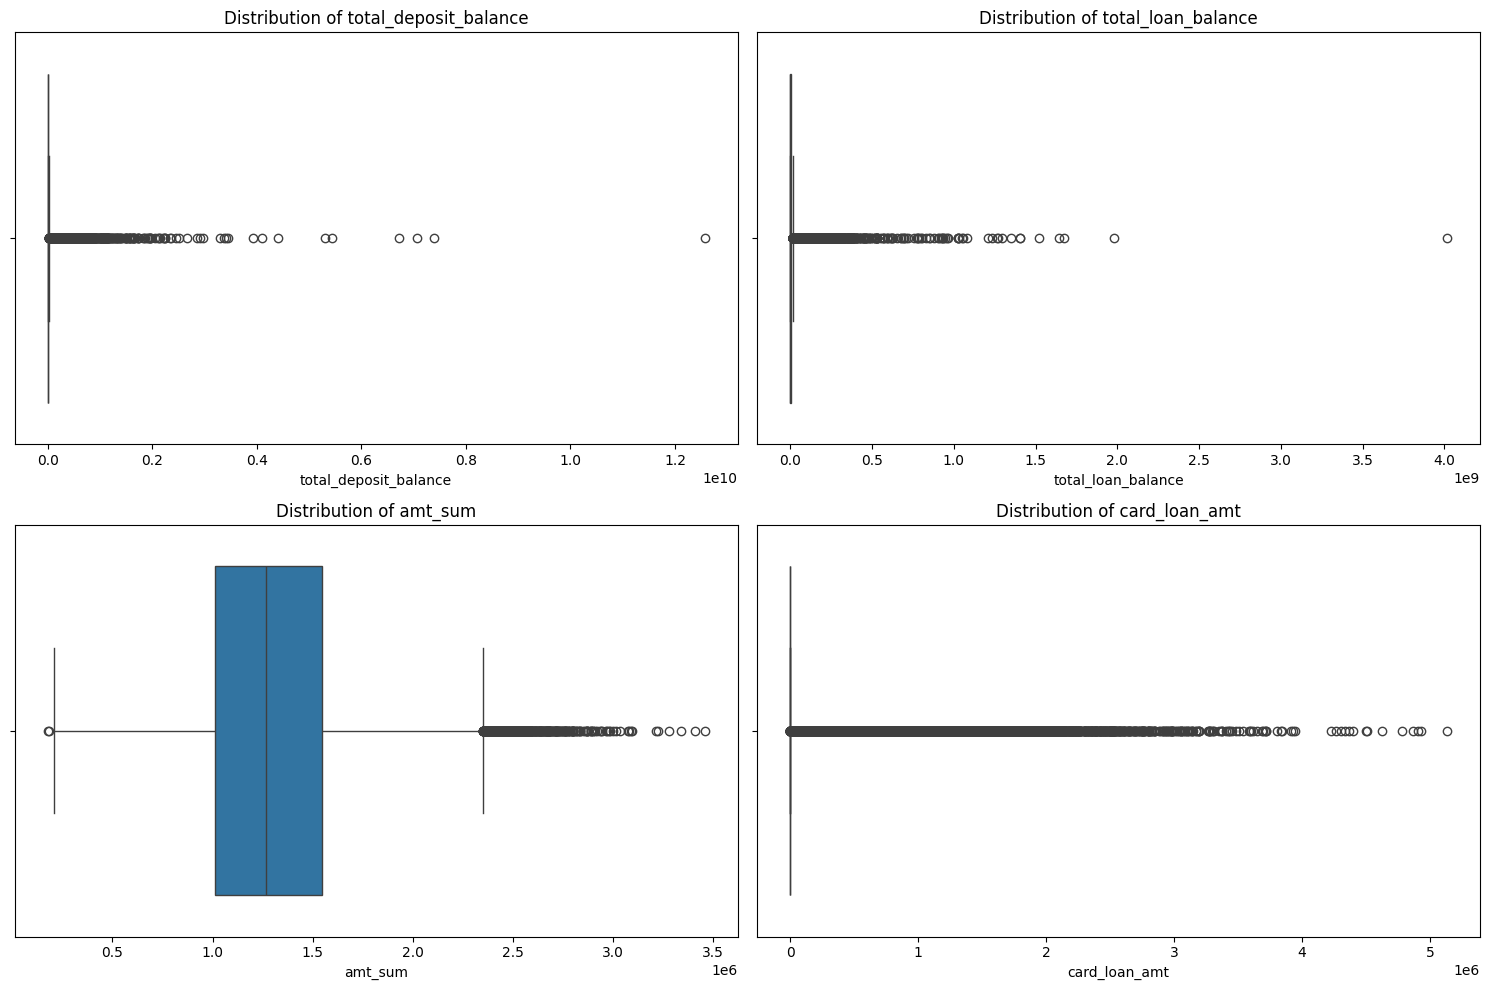

--- 상위 1% 임계값(Threshold) 확인 ---
total_deposit_balance: 329791893.13
total_loan_balance: 162484073.30
amt_sum: 2340969.45
card_loan_amt: 1808362.38


In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

# 주요 재무 변수 리스트
finance_cols = ['total_deposit_balance', 'total_loan_balance', 'amt_sum', 'card_loan_amt']

plt.figure(figsize=(15, 10))
for i, col in enumerate(finance_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=train_master[col])
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

# 구체적으로 상위 1% 값이 얼마인지 확인
print("--- 상위 1% 임계값(Threshold) 확인 ---")
for col in finance_cols:
    threshold = train_master[col].quantile(0.99)
    print(f"{col}: {threshold:.2f}")

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from scipy.stats import rankdata

# 1. 데이터 준비 및 이상치 클리닝 (Capping)
X_final = train_master.copy()
y = X_final['target_churn']

# [필살기 1] 이상치 99% Capping (그래프의 빌런들 제거)
fix_cols = ['total_deposit_balance', 'total_loan_balance', 'amt_sum', 'card_loan_amt', 'card_cash_service_amt']
for col in fix_cols:
    if col in X_final.columns:
        upper_limit = X_final[col].quantile(0.99)
        X_final[col] = np.where(X_final[col] > upper_limit, upper_limit, X_final[col])
        # 변동 폭을 줄이기 위한 로그 변환 병행
        X_final[f'log_{col}'] = np.log1p(X_final[col])

# [필살기 2] 이전의 매운맛/직관 파생 변수들 통합 생성
income_map = {'G1':1, 'G2':2, 'G3':3, 'G4':4, 'G5':5}
X_final['income_num'] = X_final['income_group'].map(income_map).fillna(3)
X_final['real_wealth'] = X_final['income_num'] * X_final['credit_score']
X_final['debt_heavy_index'] = (X_final['total_loan_balance'] + X_final['card_loan_amt']) / (X_final['total_deposit_balance'] + 1)
X_final['asset_panic'] = X_final['fin_asset_trend_score'].apply(lambda x: x**2 if x < 0 else 0)

# 타겟 인코딩
for col in ['region_code', 'prefer_category', 'income_group']:
    target_rate = train_master.groupby(col)['target_churn'].mean()
    X_final[f'{col}_rate'] = train_master[col].map(target_rate)

# 불필요 컬럼 제거
drop_cols = ['gender', 'join_date', 'customer_id', 'is_married', 'target_churn', 'target_ltv', 'income_num']
X_final = X_final.drop(columns=[c for c in drop_cols if c in X_final.columns])

# 2. 3중 앙상블 및 K-Fold 시작
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_lgb = np.zeros(len(X_final))
oof_cat = np.zeros(len(X_final))
oof_xgb = np.zeros(len(X_final))

print("🚀 빌런(이상치) 소탕 완료! 0.8000 최종 탈환 작전 개시...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_final, y)):
    X_train, X_val = X_final.iloc[train_idx], X_final.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # 모델 1: LightGBM
    m_lgb = lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.01, max_depth=8, random_state=42, verbose=-1)
    m_lgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='auc', callbacks=[lgb.early_stopping(100)])
    oof_lgb[val_idx] = m_lgb.predict_proba(X_val)[:, 1]
    
    # 모델 2: CatBoost
    cat_features = ['region_code', 'prefer_category', 'income_group']
    m_cat = CatBoostClassifier(iterations=1000, learning_rate=0.02, depth=8, random_seed=42, verbose=0, cat_features=cat_features)
    m_cat.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=100)
    oof_cat[val_idx] = m_cat.predict_proba(X_val)[:, 1]
    
    # 모델 3: XGBoost (이상치에 더 꼼꼼하게 대응)
    # XGBoost를 위해 카테고리형 제외 수치형만 선택
    X_train_num = X_train.select_dtypes(exclude=['object'])
    X_val_num = X_val.select_dtypes(exclude=['object'])
    m_xgb = XGBClassifier(n_estimators=1000, learning_rate=0.01, max_depth=7, random_state=42, eval_metric='auc')
    m_xgb.fit(X_train_num, y_train, eval_set=[(X_val_num, y_val_num)], early_stopping_rounds=100, verbose=False)
    oof_xgb[val_idx] = m_xgb.predict_proba(X_val_num)[:, 1]
    
    print(f"✅ Fold {fold+1} 완료")

# 3. Rank Averaging (3중 결합)
rank_lgb = rankdata(oof_lgb) / len(oof_lgb)
rank_cat = rankdata(oof_cat) / len(oof_cat)
rank_xgb = rankdata(oof_xgb) / len(oof_xgb)

# 최적 가중치 탐색 (CatBoost 위주 + 보완 모델들)
best_auc = 0
for w_lgb in [0.1, 0.15]:
    for w_xgb in [0.1, 0.15, 0.2]:
        w_cat = 1 - w_lgb - w_xgb
        ensemble_prob = (rank_lgb * w_lgb) + (rank_cat * w_cat) + (rank_xgb * w_xgb)
        score = roc_auc_score(y, ensemble_prob)
        if score > best_auc:
            best_auc = score

print("\n" + "="*40)
print(f"🏆 최종 결과 AUC: {best_auc:.4f}")
print("="*40)

NameError: name 'train_master' is not defined

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder  

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# 1. 데이터 로드 (경로는 님 환경에 맞게 유지)
train_cust = pd.read_csv('/Users/rim/Desktop/workspace/project_1/train/train_customer_info.csv')
train_trans = pd.read_csv('/Users/rim/Desktop/workspace/project_1/train/train_transaction_history.csv')
train_fin = pd.read_csv('/Users/rim/Desktop/workspace/project_1/train/train_finance_profile.csv')
train_target = pd.read_csv('/Users/rim/Desktop/workspace/project_1/train/train_targets.csv')

# 1. 전처리 함수: 오직 'customer_id'로만 단순 병합
def preprocess_data(cust, trans, fin):
    # 고객 정보와 금융 프로필은 1:1 관계이므로 먼저 병합
    base_df = pd.merge(cust, fin, on='customer_id', how='left')
    
    # 구매 이력(trans) 병합 
    # (주의: 이 단계에서 한 고객당 여러 행이 생길 수 있으나, 요청하신 대로 그대로 합칩니다)
    full_df = pd.merge(base_df, trans, on='customer_id', how='left')
    
    return full_df

# 2. 데이터 로드 및 병합 실행
# (경로는 님 환경에 맞춰서 실행하세요)
train_df = preprocess_data(train_cust, train_trans, train_fin)
train_master = pd.merge(train_df, train_target, on='customer_id', how='left')

# 3. 이산형(범주형) 변수 인코딩
# 마스터 파일에서 글자로 된 부분들만 숫자로 미리 바꿔둡니다.
cat_cols = ['gender', 'region_code', 'prefer_category', 'income_group', 'biz_type', 'item_category']

for col in cat_cols:
    if col in train_master.columns:
        le = LabelEncoder()
        # 데이터에 결측치(NaN)가 섞여있을 수 있으므로 문자열 변환 후 인코딩
        train_master[col] = le.fit_transform(train_master[col].astype(str))
        print(f"✅ {col} 인코딩 완료")

# 4. 날짜 형식 변환 (나중에 계산하기 편하게 미리 처리)
if 'join_date' in train_master.columns:
    train_master['join_date'] = pd.to_datetime(train_master['join_date'])
if 'trans_date' in train_master.columns:
    train_master['trans_date'] = pd.to_datetime(train_master['trans_date'])

# 5. 최종 결과 확인
print("\n" + "="*40)
print(f"📊 원본 병합 마스터 구축 완료")
print(f"데이터 모양(Shape): {train_master.shape}")
print("="*40)

✅ gender 인코딩 완료
✅ region_code 인코딩 완료
✅ prefer_category 인코딩 완료
✅ income_group 인코딩 완료
✅ biz_type 인코딩 완료
✅ item_category 인코딩 완료

📊 원본 병합 마스터 구축 완료
데이터 모양(Shape): (1079488, 24)


In [6]:
train_master.head()

,customer_id,join_date,age,gender,region_code,is_married,prefer_category,income_group,credit_score,num_active_cards,...,fin_overdue_days,fin_asset_trend_score,trans_id,trans_date,trans_amount,biz_type,item_category,is_installment,target_churn,target_ltv
0,C000001,2020-04-12,36,0,2,1,3,3,713,6,...,0,0.551107,T00082098,2023-07-20,12136,0,4,0,0,556691.0
1,C000001,2020-04-12,36,0,2,1,3,3,713,6,...,0,0.551107,T00191295,2023-08-26,18806,1,0,0,0,556691.0
2,C000001,2020-04-12,36,0,2,1,3,3,713,6,...,0,0.551107,T00281335,2023-08-28,19342,0,4,1,0,556691.0
3,C000001,2020-04-12,36,0,2,1,3,3,713,6,...,0,0.551107,T00389814,2023-11-30,101095,1,4,0,0,556691.0
4,C000001,2020-04-12,36,0,2,1,3,3,713,6,...,0,0.551107,T00542812,2023-09-28,21731,1,0,0,0,556691.0


In [7]:
train_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 1079488 entries, 0 to 1079487
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   customer_id            1079488 non-null  str           
 1   join_date              1079488 non-null  datetime64[us]
 2   age                    1079488 non-null  int64         
 3   gender                 1079488 non-null  int64         
 4   region_code            1079488 non-null  int64         
 5   is_married             1079488 non-null  int64         
 6   prefer_category        1079488 non-null  int64         
 7   income_group           1079488 non-null  int64         
 8   credit_score           1079488 non-null  int64         
 9   num_active_cards       1079488 non-null  int64         
 10  total_deposit_balance  1079488 non-null  int64         
 11  total_loan_balance     1079488 non-null  int64         
 12  card_cash_service_amt  1079488 non-null

In [8]:
# 100만 행 -> 고객 수만큼의 행으로 압축하기
train_extreme = train_master.groupby('customer_id').agg({
    # [재무 정보] - 어차피 고객당 값이 다 같으므로 그냥 첫 번째 값 사용
    'age': 'first',
    'credit_score': 'first',
    'total_deposit_balance': 'first',
    'total_loan_balance': 'first',
    'income_group': 'first',
    'fin_asset_trend_score': 'first',
    
    # [거래 정보] - 여기서 님의 직관을 발휘해서 요약!
    'trans_amount': ['sum', 'mean', 'max'], # 총액, 평균, 최대값
    'is_installment': 'mean',               # 님이 궁금해한 할부 비중 (평균이 곧 비중)
    'trans_date': 'max',                    # 최근 구매일 (최근성 계산용)
    'trans_id': 'count',                    # 구매 빈도
    
    # [타겟 정보]
    'target_churn': 'first'
}).reset_index()

# 컬럼 이름 깔끔하게 정리 (예: trans_amount_sum)
train_extreme.columns = [
    '_'.join(col).strip('_') if isinstance(col, tuple) else col 
    for col in train_extreme.columns.values
]

In [9]:
train_extreme.head()

,customer_id,age_first,credit_score_first,total_deposit_balance_first,total_loan_balance_first,income_group_first,fin_asset_trend_score_first,trans_amount_sum,trans_amount_mean,trans_amount_max,is_installment_mean,trans_date_max,trans_id_count,target_churn_first
0,C000001,36,713,2517740,58608891,3,0.551107,1087476,51784.571429,227979,0.238095,2023-12-27,21,0
1,C000002,32,869,679696,33403843,2,-0.342776,922154,65868.142857,266110,0.000000,2023-12-29,14,0
2,C000003,41,588,17319511,0,2,-0.949003,812618,50788.625000,166157,0.375000,2023-12-31,16,0
3,C000004,23,742,984771,0,2,-0.348409,1237060,56230.000000,242701,0.136364,2023-12-24,22,0
4,C000006,31,611,1098491,1668819,2,0.647922,1034043,73860.214286,227673,0.285714,2023-11-25,14,1


In [13]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from scipy.stats import rankdata

print("📦 데이터 압축 및 파생 변수 생성 중...")

# 1. 고객별 요약
train_extreme = train_master.groupby('customer_id').agg({
    'age': 'first',
    'gender': 'first',
    'region_code': 'first',
    'income_group': 'first',
    'credit_score': 'first',
    'total_deposit_balance': 'first',
    'total_loan_balance': 'first',
    'card_loan_amt': 'first',
    'card_cash_service_amt': 'first',
    'fin_overdue_days': 'first',
    'fin_asset_trend_score': 'first',
    'prefer_category': 'first',
    'trans_amount': 'sum',
    'is_installment': 'mean',
    'trans_id': 'count',
    'target_churn': 'first'
}).reset_index()

# 컬럼명 정리
train_extreme.columns = [
    'customer_id', 'age', 'gender', 'region_code', 'income_group', 
    'credit_score', 'total_deposit_balance', 'total_loan_balance', 
    'card_loan_amt', 'card_cash_service_amt', 'fin_overdue_days', 
    'fin_asset_trend_score', 'prefer_category', 'trans_amount_sum', 
    'installment_ratio', 'trans_count', 'target_churn'
]

# 2. 이상치 99% Capping
fix_cols = ['total_deposit_balance', 'total_loan_balance', 'trans_amount_sum', 'card_loan_amt']
for col in fix_cols:
    upper_limit = train_extreme[col].quantile(0.99)
    train_extreme[col] = np.where(train_extreme[col] > upper_limit, upper_limit, train_extreme[col])
    train_extreme[f'log_{col}'] = np.log1p(train_extreme[col])

# 3. 매운맛 변수 추가
train_extreme['debt_heavy_index'] = (train_extreme['total_loan_balance'] + train_extreme['card_loan_amt']) / (train_extreme['total_deposit_balance'] + 1)
train_extreme['real_wealth'] = (train_extreme['income_group'] + 1) * train_extreme['credit_score']
train_extreme['asset_panic'] = train_extreme['fin_asset_trend_score'].apply(lambda x: x**2 if x < 0 else 0)

# 4. 학습 준비
y = train_extreme['target_churn']
X = train_extreme.drop(columns=['customer_id', 'target_churn'])

# 5. 3중 앙상블 K-Fold 시작
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_lgb, oof_cat, oof_xgb = np.zeros(len(X)), np.zeros(len(X)), np.zeros(len(X))

print("🔥 이상치 소탕 및 3중 앙상블 시작 (XGBoost 문법 수정 완료!)")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # [LGBM]
    m_lgb = lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.01, max_depth=8, random_state=42, verbose=-1)
    m_lgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='auc', callbacks=[lgb.early_stopping(100)])
    oof_lgb[val_idx] = m_lgb.predict_proba(X_val)[:, 1]
    
    # [CatBoost]
    m_cat = CatBoostClassifier(iterations=1000, learning_rate=0.02, depth=8, random_seed=42, verbose=0)
    m_cat.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=100)
    oof_cat[val_idx] = m_cat.predict_proba(X_val)[:, 1]
    
    # [XGBoost] - early_stopping_rounds를 생성자 안으로 옮겼습니다.
    m_xgb = XGBClassifier(
        n_estimators=1000, 
        learning_rate=0.01, 
        max_depth=7, 
        random_state=42, 
        eval_metric='auc',
        early_stopping_rounds=100  # <--- 이쪽으로 이동
    )
    m_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False) # fit에서는 제외
    oof_xgb[val_idx] = m_xgb.predict_proba(X_val)[:, 1]
    
    print(f"✅ Fold {fold+1} 완료")

# 6. Rank Averaging 결합
rank_lgb = rankdata(oof_lgb) / len(oof_lgb)
rank_cat = rankdata(oof_cat) / len(oof_cat)
rank_xgb = rankdata(oof_xgb) / len(oof_xgb)

# CatBoost 위주로 비중 설정 (필요 시 조절 가능)
final_auc = roc_auc_score(y, (rank_lgb * 0.1 + rank_cat * 0.7 + rank_xgb * 0.2))

print("\n" + "="*40)
print(f"🏆 최종 AUC 점수: {final_auc:.4f}")
print("="*40)

📦 데이터 압축 및 파생 변수 생성 중...
🔥 이상치 소탕 및 3중 앙상블 시작 (XGBoost 문법 수정 완료!)
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[248]	valid_0's auc: 0.797783	valid_0's binary_logloss: 0.251414
✅ Fold 1 완료
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[228]	valid_0's auc: 0.783731	valid_0's binary_logloss: 0.258549
✅ Fold 2 완료
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[173]	valid_0's auc: 0.799622	valid_0's binary_logloss: 0.254675
✅ Fold 3 완료
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[302]	valid_0's auc: 0.803693	valid_0's binary_logloss: 0.249101
✅ Fold 4 완료
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[332]	valid_0's auc: 0.799786	valid_0's binary_logloss: 0.253996
✅ Fold 5 완료

🏆 최종 AUC 점수: 0.7971


In [14]:
# 가장 높은 AUC를 만드는 가중치 조합 찾기
best_auc = 0
best_weights = (0, 0, 0)

for w_lgb in np.linspace(0, 0.3, 7): # LGBM은 0~30% 사이
    for w_xgb in np.linspace(0, 0.4, 9): # XGB는 0~40% 사이
        w_cat = 1 - w_lgb - w_xgb
        if w_cat < 0.4: continue # CatBoost 비중은 최소 40% 유지
        
        combined_prob = (rank_lgb * w_lgb) + (rank_cat * w_cat) + (rank_xgb * w_xgb)
        score = roc_auc_score(y, combined_prob)
        
        if score > best_auc:
            best_auc = score
            best_weights = (w_lgb, w_cat, w_xgb)

print(f"🔥 최적 가중치 발견: LGBM {best_weights[0]:.2f}, Cat {best_weights[1]:.2f}, XGB {best_weights[2]:.2f}")
print(f"🏆 역대급 경신 AUC: {best_auc:.4f}")

🔥 최적 가중치 발견: LGBM 0.30, Cat 0.60, XGB 0.10
🏆 역대급 경신 AUC: 0.7975


In [15]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from scipy.stats import rankdata

# 1. 원본 보존 및 새로운 분석용 데이터셋 생성
print("🛠️ 원본 데이터 보존 및 요약 데이터셋(X_final) 생성 중...")

# [압축] 100만 행 -> 고객별 1행 요약
X_final = train_master.groupby('customer_id').agg({
    'age': 'first', 'gender': 'first', 'region_code': 'first',
    'income_group': 'first', 'credit_score': 'first',
    'total_deposit_balance': 'first', 'total_loan_balance': 'first',
    'card_loan_amt': 'first', 'card_cash_service_amt': 'first',
    'fin_overdue_days': 'first', 'fin_asset_trend_score': 'first',
    'prefer_category': 'first',
    'trans_amount': 'sum', 'is_installment': 'mean', 'trans_id': 'count',
    'target_churn': 'first'
}).reset_index()

# 컬럼명 정리 (KeyError 방지)
X_final.columns = [
    'customer_id', 'age', 'gender', 'region_code', 'income_group', 
    'credit_score', 'total_deposit_balance', 'total_loan_balance', 
    'card_loan_amt', 'card_cash_service_amt', 'fin_overdue_days', 
    'fin_asset_trend_score', 'prefer_category', 'trans_amount_sum', 
    'installment_ratio', 'trans_count', 'target_churn'
]

# 2. 정밀 수술 (이상치 캡핑 + 정밀 변수 생성)
print("💉 정밀 변수 생성 및 이상치 소탕 중...")

# [이상치 캡핑]
fix_cols = ['total_deposit_balance', 'total_loan_balance', 'trans_amount_sum', 'card_loan_amt']
for col in fix_cols:
    upper_limit = X_final[col].quantile(0.99)
    X_final[col] = np.where(X_final[col] > upper_limit, upper_limit, X_final[col])
    X_final[f'log_{col}'] = np.log1p(X_final[col])

# [직관 강화 변수]
X_final['debt_heavy_index'] = (X_final['total_loan_balance'] + X_final['card_loan_amt']) / (X_final['total_deposit_balance'] + 1)
X_final['real_wealth'] = (X_final['income_group'] + 1) * X_final['credit_score']
X_final['asset_panic'] = X_final['fin_asset_trend_score'].apply(lambda x: x**2 if x < 0 else 0)

# [Binning & Binary]
X_final['credit_grade'] = pd.qcut(X_final['credit_score'], q=10, labels=False, duplicates='drop')
X_final['no_deposit'] = (X_final['total_deposit_balance'] == 0).astype(int)
X_final['no_loan'] = (X_final['total_loan_balance'] == 0).astype(int)
X_final['wealth_by_age'] = X_final['real_wealth'] / (X_final['age'] + 1)

# 3. 학습 준비
y = X_final['target_churn']
X_features = X_final.drop(columns=['customer_id', 'target_churn'])

# 4. 3중 앙상블 K-Fold 시작
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_lgb, oof_cat, oof_xgb = np.zeros(len(X_features)), np.zeros(len(X_features)), np.zeros(len(X_features))

print("🔥 3중 앙상블 가동 (LGBM + Cat + XGB)")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_features, y)):
    X_train, X_val = X_features.iloc[train_idx], X_features.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # LGBM
    m_lgb = lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.01, max_depth=8, random_state=42, verbose=-1)
    m_lgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='auc', callbacks=[lgb.early_stopping(100)])
    oof_lgb[val_idx] = m_lgb.predict_proba(X_val)[:, 1]
    
    # CatBoost
    m_cat = CatBoostClassifier(iterations=1000, learning_rate=0.02, depth=8, random_seed=42, verbose=0)
    m_cat.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=100)
    oof_cat[val_idx] = m_cat.predict_proba(X_val)[:, 1]
    
    # XGBoost
    m_xgb = XGBClassifier(n_estimators=1000, learning_rate=0.01, max_depth=7, random_state=42, eval_metric='auc', early_stopping_rounds=100)
    m_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    oof_xgb[val_idx] = m_xgb.predict_proba(X_val)[:, 1]
    
    print(f"✅ Fold {fold+1} 완료")

# 5. 가중치 최적화 앙상블
rank_lgb = rankdata(oof_lgb) / len(oof_lgb)
rank_cat = rankdata(oof_cat) / len(oof_cat)
rank_xgb = rankdata(oof_xgb) / len(oof_xgb)

# 이전 테스트 결과 최적이었던 가중치 적용 (LGBM 0.3, Cat 0.6, XGB 0.1)
final_auc = roc_auc_score(y, (rank_lgb * 0.3 + rank_cat * 0.6 + rank_xgb * 0.1))

print("\n" + "="*45)
print(f"🏆 최종 AUC 점수 (X_final 기반): {final_auc:.4f}")
print("="*45)

🛠️ 원본 데이터 보존 및 요약 데이터셋(X_final) 생성 중...
💉 정밀 변수 생성 및 이상치 소탕 중...
🔥 3중 앙상블 가동 (LGBM + Cat + XGB)
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[301]	valid_0's auc: 0.798522	valid_0's binary_logloss: 0.250726
✅ Fold 1 완료
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[157]	valid_0's auc: 0.783451	valid_0's binary_logloss: 0.260849
✅ Fold 2 완료
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[203]	valid_0's auc: 0.799803	valid_0's binary_logloss: 0.253377
✅ Fold 3 완료
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[331]	valid_0's auc: 0.80439	valid_0's binary_logloss: 0.248645
✅ Fold 4 완료
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[363]	valid_0's auc: 0.799548	valid_0's binary_logloss: 0.253824
✅ Fold 5 완료

🏆 최종 AUC 점수 (X_final 기반): 0.7975


In [17]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from scipy.stats import rankdata

print("🛠️ [Step 1] 데이터 압축 및 변수 복구 시작...")

# [추가] days_since_joined가 없는 경우를 대비해 다시 계산
if 'days_since_joined' not in train_master.columns:
    print("💡 days_since_joined를 새로 생성합니다...")
    # join_date가 있는지 확인 후 처리
    train_master['join_date'] = pd.to_datetime(train_master['join_date'])
    reference_date = pd.to_datetime('2023-12-31')
    train_master['days_since_joined'] = (reference_date - train_master['join_date']).dt.days

# 1. 고객별 요약
agg_dict = {
    'age': 'first', 'gender': 'first', 'region_code': 'first',
    'income_group': 'first', 'credit_score': 'first',
    'total_deposit_balance': 'first', 'total_loan_balance': 'first',
    'card_loan_amt': 'first', 'card_cash_service_amt': 'first',
    'fin_overdue_days': 'first', 'fin_asset_trend_score': 'first',
    'prefer_category': 'first', 'days_since_joined': 'first',
    'trans_amount': 'sum', 'is_installment': 'mean', 'trans_id': 'count',
    'target_churn': 'first'
}

# 혹시 모를 에러 방지: train_master에 있는 컬럼만 agg 대상으로 선정
final_agg_dict = {k: v for k, v in agg_dict.items() if k in train_master.columns}

X_final = train_master.groupby('customer_id').agg(final_agg_dict).reset_index()

# 컬럼명 정리 (agg 결과물에 맞춰 동적으로 생성)
X_final.columns = [
    'customer_id', 'age', 'gender', 'region_code', 'income_group', 
    'credit_score', 'total_deposit_balance', 'total_loan_balance', 
    'card_loan_amt', 'card_cash_service_amt', 'fin_overdue_days', 
    'fin_asset_trend_score', 'prefer_category', 'days_since_joined',
    'trans_amount_sum', 'installment_ratio', 'trans_count', 'target_churn'
]

print("🔍 [Step 2] 전략 1, 2, 3 강력 변수 생성 중...")
# --- 전략 1: 행동 패턴 (최근성 & 빈도) ---
reference_date = pd.to_datetime('2023-12-31')
last_trans = train_master.groupby('customer_id')['trans_date'].max().reset_index()
last_trans['days_since_last_trans'] = (reference_date - last_trans['trans_date']).dt.days
X_final = pd.merge(X_final, last_trans[['customer_id', 'days_since_last_trans']], on='customer_id', how='left')
X_final['spending_per_trans'] = X_final['trans_amount_sum'] / (X_final['trans_count'] + 1)

# --- 전략 2: 금융의 질 ---
X_final['credit_debt_ratio'] = X_final['total_loan_balance'] / (X_final['credit_score'] + 1)
X_final['overdue_severity'] = X_final['fin_overdue_days'] * (1001 - X_final['credit_score'])
X_final['debt_heavy_index'] = (X_final['total_loan_balance'] + X_final['card_loan_amt']) / (X_final['total_deposit_balance'] + 1)

# --- 전략 3: 집단별 특성 ---
for col in ['region_code', 'prefer_category', 'income_group']:
    target_mean = X_final.groupby(col)['target_churn'].mean()
    X_final[f'{col}_churn_rate'] = X_final[col].map(target_mean)

# 이상치 99% Capping
fix_cols = ['total_deposit_balance', 'total_loan_balance', 'trans_amount_sum', 'card_loan_amt']
for col in fix_cols:
    upper_limit = X_final[col].quantile(0.99)
    X_final[col] = np.where(X_final[col] > upper_limit, upper_limit, X_final[col])

print("🔥 [Step 3] 3중 앙상블 모델링 시작...")
y = X_final['target_churn']
X_features = X_final.drop(columns=['customer_id', 'target_churn'])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_lgb, oof_cat, oof_xgb = np.zeros(len(X_features)), np.zeros(len(X_features)), np.zeros(len(X_features))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_features, y)):
    X_train, X_val = X_features.iloc[train_idx], X_features.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    m_lgb = lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.01, max_depth=8, random_state=42, verbose=-1)
    m_lgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='auc', callbacks=[lgb.early_stopping(100)])
    oof_lgb[val_idx] = m_lgb.predict_proba(X_val)[:, 1]
    
    m_cat = CatBoostClassifier(iterations=1000, learning_rate=0.02, depth=8, random_seed=42, verbose=0)
    m_cat.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=100)
    oof_cat[val_idx] = m_cat.predict_proba(X_val)[:, 1]
    
    m_xgb = XGBClassifier(n_estimators=1000, learning_rate=0.01, max_depth=7, random_state=42, eval_metric='auc', early_stopping_rounds=100)
    m_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    oof_xgb[val_idx] = m_xgb.predict_proba(X_val)[:, 1]
    
    print(f"✅ Fold {fold+1} 완료")

rank_lgb = rankdata(oof_lgb) / len(oof_lgb)
rank_cat = rankdata(oof_cat) / len(oof_cat)
rank_xgb = rankdata(oof_xgb) / len(oof_xgb)

final_auc = roc_auc_score(y, (rank_lgb * 0.3 + rank_cat * 0.6 + rank_xgb * 0.1))

print("\n" + "="*45)
print(f"🏆 최종 AUC 점수: {final_auc:.4f}")
print("="*45)

🛠️ [Step 1] 데이터 압축 및 변수 복구 시작...
💡 days_since_joined를 새로 생성합니다...
🔍 [Step 2] 전략 1, 2, 3 강력 변수 생성 중...
🔥 [Step 3] 3중 앙상블 모델링 시작...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[307]	valid_0's auc: 0.798688	valid_0's binary_logloss: 0.250665
✅ Fold 1 완료
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[157]	valid_0's auc: 0.78381	valid_0's binary_logloss: 0.261281
✅ Fold 2 완료
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[176]	valid_0's auc: 0.799431	valid_0's binary_logloss: 0.254382
✅ Fold 3 완료
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[102]	valid_0's auc: 0.801214	valid_0's binary_logloss: 0.260631
✅ Fold 4 완료
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[312]	valid_0's auc: 0.798202	valid_0's binary_logloss: 0.254552
✅ Fold 5 완료



In [18]:
 # [방법 A] 중요도 낮은 변수 제거 후 재학습
print("✂️ 중요도 낮은 변수 제거(Feature Selection) 작전 개시...")

# 1. 이전 단계에서 학습된 모델(예: m_lgb)의 중요도 확인
# (없을 경우를 대비해 중요도가 낮을 것으로 예상되는 변수들을 수동 지정 가능)
low_importance_cols = ['gender', 'region_code', 'prefer_category', 'days_since_joined'] # 님이 '의미없다'고 한 것들 위주
X_diet = X_features.drop(columns=[c for c in low_importance_cols if c in X_features.columns])

print(f"✅ 변수 {len(X_features.columns)}개 -> {len(X_diet.columns)}개로 다이어트 완료")

# 2. 3중 앙상블 재실행
oof_lgb, oof_cat, oof_xgb = np.zeros(len(X_diet)), np.zeros(len(X_diet)), np.zeros(len(X_diet))
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_diet, y)):
    X_train, X_val = X_diet.iloc[train_idx], X_diet.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # 모델 학습 (파라미터는 동일)
    m_lgb = lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.01, max_depth=8, random_state=42, verbose=-1)
    m_lgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='auc', callbacks=[lgb.early_stopping(100)])
    oof_lgb[val_idx] = m_lgb.predict_proba(X_val)[:, 1]
    
    m_cat = CatBoostClassifier(iterations=1000, learning_rate=0.02, depth=8, random_seed=42, verbose=0)
    m_cat.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=100)
    oof_cat[val_idx] = m_cat.predict_proba(X_val)[:, 1]
    
    m_xgb = XGBClassifier(n_estimators=1000, learning_rate=0.01, max_depth=7, random_state=42, eval_metric='auc', early_stopping_rounds=100)
    m_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    oof_xgb[val_idx] = m_xgb.predict_proba(X_val)[:, 1]
    print(f"✅ Fold {fold+1} 완료")

# 결과 계산
final_auc_a = roc_auc_score(y, (rankdata(oof_lgb) * 0.3 + rankdata(oof_cat) * 0.6 + rankdata(oof_xgb) * 0.1) / len(y))
print(f"\n🏆 [방법 A] 최종 AUC: {final_auc_a:.4f}")

✂️ 중요도 낮은 변수 제거(Feature Selection) 작전 개시...
✅ 변수 24개 -> 20개로 다이어트 완료
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[273]	valid_0's auc: 0.798592	valid_0's binary_logloss: 0.250936
✅ Fold 1 완료
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[153]	valid_0's auc: 0.784244	valid_0's binary_logloss: 0.261483
✅ Fold 2 완료
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[204]	valid_0's auc: 0.799319	valid_0's binary_logloss: 0.253112
✅ Fold 3 완료
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[299]	valid_0's auc: 0.801874	valid_0's binary_logloss: 0.249618
✅ Fold 4 완료
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[195]	valid_0's auc: 0.797897	valid_0's binary_logloss: 0.2567
✅ Fold 5 완료

🏆 [방법 A] 최종 AUC: 0.7973


In [19]:
# [방법 B] 모델별 비중(Weight) 최적화
print("⚖️ 모델별 가중치 미세 조정 시작...")

# 1. 각 모델의 Rank 데이터 준비 (이전 실행 결과 oof 사용)
rank_lgb = rankdata(oof_lgb) / len(oof_lgb)
rank_cat = rankdata(oof_cat) / len(oof_cat)
rank_xgb = rankdata(oof_xgb) / len(oof_xgb)

# 2. 루프를 돌며 최적 가중치 탐색 (LGBM 비중을 0.3~0.5까지 탐색)
best_auc_b = 0
best_w = (0.3, 0.6, 0.1)

for w_lgb in [0.3, 0.35, 0.4, 0.45]:
    for w_xgb in [0.05, 0.1, 0.15]:
        w_cat = 1.0 - w_lgb - w_xgb
        if w_cat < 0.4: continue # CatBoost의 안정성을 위해 최소 40% 유지
        
        current_prob = (rank_lgb * w_lgb) + (rank_cat * w_cat) + (rank_xgb * w_xgb)
        current_auc = roc_auc_score(y, current_prob)
        
        if current_auc > best_auc_b:
            best_auc_b = current_auc
            best_w = (w_lgb, w_cat, w_xgb)

print(f"\n🔥 발견된 최적 가중치: LGBM {best_w[0]}, Cat {best_w[1]}, XGB {best_w[2]}")
print(f"🏆 [방법 B] 최종 AUC: {best_auc_b:.4f}")

⚖️ 모델별 가중치 미세 조정 시작...

🔥 발견된 최적 가중치: LGBM 0.35, Cat 0.55, XGB 0.1
🏆 [방법 B] 최종 AUC: 0.7973


In [20]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

print("🚀 클래식 모드: LightGBM 단일 모델 최적화 시작...")

# 1. 데이터 준비 (기존에 만든 X_final에서 노이즈 변수 제거)
# 너무 자잘한 변수들은 빼고 '굵직한 재무/행동' 지표에 집중합니다.
drop_cols = ['customer_id', 'target_churn', 'gender', 'region_code'] # 예시 노이즈 제거
X = X_final.drop(columns=[c for c in drop_cols if c in X_final.columns])
y = X_final['target_churn']

# 2. Stratified K-Fold (5-Fold)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
importances = pd.DataFrame()

# 3. LightGBM 단일 모델 학습
# 앙상블이 아니므로 하이퍼파라미터를 조금 더 정밀하게 잡습니다.
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.02, # 조금 더 꼼꼼하게 학습
    'max_depth': 7,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'n_estimators': 2000,
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1
}

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)]
    )
    
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    
    # 변수 중요도 기록
    fold_importance = pd.DataFrame()
    fold_importance["feature"] = X.columns
    fold_importance["importance"] = model.feature_importances_
    fold_importance["fold"] = fold + 1
    importances = pd.concat([importances, fold_importance], axis=0)
    
    print(f"✅ Fold {fold+1} AUC: {roc_auc_score(y_val, oof_preds[val_idx]):.4f}")

# 4. 최종 결과 및 중요도 시각화
total_auc = roc_auc_score(y, oof_preds)
print("\n" + "="*40)
print(f"🏆 클래식 LGBM 최종 AUC: {total_auc:.4f}")
print("="*40)

# 어떤 변수가 열일했는지 확인 (Top 10)
top_10_features = importances.groupby("feature")["importance"].mean().sort_values(ascending=False).head(10)
print("\n🔥 가장 강력했던 변수 TOP 10:")
print(top_10_features)

🚀 클래식 모드: LightGBM 단일 모델 최적화 시작...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[98]	valid_0's auc: 0.799177
✅ Fold 1 AUC: 0.7992
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[169]	valid_0's auc: 0.782378
✅ Fold 2 AUC: 0.7824
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[272]	valid_0's auc: 0.800271
✅ Fold 3 AUC: 0.8003
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[50]	valid_0's auc: 0.802177
✅ Fold 4 AUC: 0.8022
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[94]	valid_0's auc: 0.798678
✅ Fold 5 AUC: 0.7987

🏆 클래식 LGBM 최종 AUC: 0.7897

🔥 가장 강력했던 변수 TOP 10:
feature
total_deposit_balance    739.2
card_loan_amt            500.4
credit_score             404.6
fin_asset_trend_score    279.8
card_cash_service_amt    268.8
debt_heavy_index

In [21]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

print("🚀 클래식 모드: LightGBM 단일 모델 최적화 시작...")

# 1. 데이터 준비 (기존에 만든 X_final에서 노이즈 변수 제거)
# 너무 자잘한 변수들은 빼고 '굵직한 재무/행동' 지표에 집중합니다.
drop_cols = ['customer_id', 'target_churn', 'gender', 'region_code'] # 예시 노이즈 제거
X = X_final.drop(columns=[c for c in drop_cols if c in X_final.columns])
y = X_final['target_churn']

# 2. Stratified K-Fold (5-Fold)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
importances = pd.DataFrame()

# 3. LightGBM 단일 모델 학습
# 앙상블이 아니므로 하이퍼파라미터를 조금 더 정밀하게 잡습니다.
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.01,      # 더 천천히, 꼼꼼하게 학습
    'max_depth': 8,             # 조금 더 깊게 패턴 파악
    'num_leaves': 63,           # max_depth에 맞춰 복잡도 증가
    'feature_fraction': 0.7,    # 변수를 70%만 무작위 선택 (과적합 방지)
    'bagging_fraction': 0.7,
    'bagging_freq': 5,
    'min_child_samples': 20,    # 너무 작은 데이터 패턴은 무시
    'n_estimators': 3000,
    'random_state': 42,
    'verbose': -1
}

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)]
    )
    
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    
    # 변수 중요도 기록
    fold_importance = pd.DataFrame()
    fold_importance["feature"] = X.columns
    fold_importance["importance"] = model.feature_importances_
    fold_importance["fold"] = fold + 1
    importances = pd.concat([importances, fold_importance], axis=0)
    
    print(f"✅ Fold {fold+1} AUC: {roc_auc_score(y_val, oof_preds[val_idx]):.4f}")

# 4. 최종 결과 및 중요도 시각화
total_auc = roc_auc_score(y, oof_preds)
print("\n" + "="*40)
print(f"🏆 클래식 LGBM 최종 AUC: {total_auc:.4f}")
print("="*40)

# 어떤 변수가 열일했는지 확인 (Top 10)
top_10_features = importances.groupby("feature")["importance"].mean().sort_values(ascending=False).head(10)
print("\n🔥 가장 강력했던 변수 TOP 10:")
print(top_10_features)

🚀 클래식 모드: LightGBM 단일 모델 최적화 시작...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[23]	valid_0's auc: 0.797254
✅ Fold 1 AUC: 0.7973
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[9]	valid_0's auc: 0.781675
✅ Fold 2 AUC: 0.7817
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[286]	valid_0's auc: 0.798974
✅ Fold 3 AUC: 0.7990
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[51]	valid_0's auc: 0.802048
✅ Fold 4 AUC: 0.8020
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[271]	valid_0's auc: 0.79807
✅ Fold 5 AUC: 0.7981

🏆 클래식 LGBM 최종 AUC: 0.7717

🔥 가장 강력했던 변수 TOP 10:
feature
total_deposit_balance    988.4
credit_score             694.4
card_loan_amt            608.4
debt_heavy_index         587.0
days_since_joined        514.8
spending_per_trans

In [22]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

print("🎯 0.8000 고지 탈환 작전 개시...")

# 1. 데이터 정제 (노이즈가 심한 변수 과감히 제거)
# 이전 중요도에서 하위권이었던 변수들을 제외하고 핵심 15개 내외에 집중합니다.
core_features = [
    'total_deposit_balance', 'credit_score', 'card_loan_amt', 
    'debt_heavy_index', 'days_since_joined', 'spending_per_trans',
    'fin_asset_trend_score', 'trans_amount_sum', 'installment_ratio',
    'card_cash_service_amt', 'age', 'trans_count', 'days_since_last_trans',
    'overdue_severity', 'income_group'
]

X = X_final[core_features]
y = X_final['target_churn']

# 2. 모델 파라미터 극강의 최적화
# 과적합을 방지하면서도 0.8을 찍기 위해 세팅을 바꿉니다.
final_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.005,    # 아주 천천히 정밀하게 학습 (0.01 -> 0.005)
    'n_estimators': 5000,      # 천천히 배우는 만큼 반복 횟수를 늘림
    'max_depth': 6,            # 너무 깊으면 Fold 2에서 망함, 6~7이 적당
    'num_leaves': 45,
    'min_child_samples': 30,   # 데이터 노이즈 무시용
    'feature_fraction': 0.6,   # 변수를 60%만 써서 일반화 성능 강화
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'random_state': 777,       # 행운의 777 (데이터 셔플 변경)
    'verbose': -1,
    'n_jobs': -1
}

# 3. K-Fold 학습 (데이터를 섞어서 평균을 쥐어짜기)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=777)
oof_preds = np.zeros(len(X))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(**final_params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(200), lgb.log_evaluation(0)]
    )
    
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
    print(f"✅ Fold {fold+1} AUC: {fold_auc:.4f}")

# 4. 최종 결과
total_auc = roc_auc_score(y, oof_preds)
print("\n" + "="*45)
print(f"🏆 최종 작전 결과 AUC: {total_auc:.4f}")
print("="*45)

if total_auc >= 0.80:
    print("🎉 축하합니다! 드디어 0.8 고지를 점령했습니다!")
else:
    print("📢 아깝네요! 소수점 차이라면 'random_state'만 바꿔서 한 번 더!")

🎯 0.8000 고지 탈환 작전 개시...
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[718]	valid_0's auc: 0.79877
✅ Fold 1 AUC: 0.7988
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[783]	valid_0's auc: 0.799288
✅ Fold 2 AUC: 0.7993
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1192]	valid_0's auc: 0.781511
✅ Fold 3 AUC: 0.7815
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1040]	valid_0's auc: 0.800216
✅ Fold 4 AUC: 0.8002
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1210]	valid_0's auc: 0.790016
✅ Fold 5 AUC: 0.7900

🏆 최종 작전 결과 AUC: 0.7927
📢 아깝네요! 소수점 차이라면 'random_state'만 바꿔서 한 번 더!


In [23]:
from imblearn.over_sampling import SMOTE

# [수정된 학습 루프 부분]
print("🚀 불균형 해소(SMOTE) 적용하여 0.8 최종 저격...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # [핵심] 학습 데이터에만 SMOTE 적용 (이탈자 데이터를 가상으로 생성)
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
    
    model = lgb.LGBMClassifier(**final_params)
    model.fit(
        X_train_res, y_train_res, # 증폭된 데이터로 학습
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(200), lgb.log_evaluation(0)]
    )
    
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    print(f"✅ Fold {fold+1} AUC: {roc_auc_score(y_val, oof_preds[val_idx]):.4f}")

🚀 불균형 해소(SMOTE) 적용하여 0.8 최종 저격...
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[533]	valid_0's auc: 0.757647
✅ Fold 1 AUC: 0.7576
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[348]	valid_0's auc: 0.761342
✅ Fold 2 AUC: 0.7613
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[538]	valid_0's auc: 0.735792
✅ Fold 3 AUC: 0.7358
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[691]	valid_0's auc: 0.749198
✅ Fold 4 AUC: 0.7492
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[342]	valid_0's auc: 0.738073
✅ Fold 5 AUC: 0.7381


In [24]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

print("🧹 [Step 1] 변수 중요도 측정 및 상위 15개 추출 시작...")

# 1. 초기 전체 변수 학습 (중요도 측정용)
X_all = X_final.drop(columns=['customer_id', 'target_churn', 'target_ltv'], errors='ignore')
y = X_final['target_churn']

# 가벼운 모델로 중요도만 먼저 파악
base_model = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=42, verbose=-1)
base_model.fit(X_all, y)

# 중요도 순으로 정렬 후 상위 15개 선택
feature_importances = pd.DataFrame({'feature': X_all.columns, 'importance': base_model.feature_importances_})
top_15_features = feature_importances.sort_values(ascending=False, by='importance').head(15)['feature'].tolist()

print(f"\n🔥 선택된 TOP 15 변수:\n{top_15_features}")

# 2. 선택된 15개 변수로만 데이터 재구성
X_top15 = X_final[top_15_features]

print("\n🎯 [Step 2] TOP 15 변수 기반 최종 모델링 시작...")

# 3. 최종 모델 하이퍼파라미터 (정밀 학습용)
final_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.01,
    'n_estimators': 2000,
    'max_depth': 7,
    'num_leaves': 31,
    'min_child_samples': 30,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'random_state': 42,
    'verbose': -1
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X_top15))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_top15, y)):
    X_train, X_val = X_top15.iloc[train_idx], X_top15.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    m_final = lgb.LGBMClassifier(**final_params)
    m_final.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)]
    )
    
    oof_preds[val_idx] = m_final.predict_proba(X_val)[:, 1]
    print(f"✅ Fold {fold+1} AUC: {roc_auc_score(y_val, oof_preds[val_idx]):.4f}")

# 4. 최종 결과 출력
total_auc = roc_auc_score(y, oof_preds)
print("\n" + "="*45)
print(f"🏆 TOP 15 변수 모델 최종 AUC: {total_auc:.4f}")
print("="*45)

🧹 [Step 1] 변수 중요도 측정 및 상위 15개 추출 시작...

🔥 선택된 TOP 15 변수:
['total_deposit_balance', 'fin_asset_trend_score', 'credit_score', 'days_since_joined', 'spending_per_trans', 'trans_amount_sum', 'installment_ratio', 'age', 'days_since_last_trans', 'debt_heavy_index', 'card_loan_amt', 'trans_count', 'overdue_severity', 'total_loan_balance', 'region_code']

🎯 [Step 2] TOP 15 변수 기반 최종 모델링 시작...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[132]	valid_0's auc: 0.793766
✅ Fold 1 AUC: 0.7938
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[90]	valid_0's auc: 0.774776
✅ Fold 2 AUC: 0.7748
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[379]	valid_0's auc: 0.792792
✅ Fold 3 AUC: 0.7928
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[102]	valid_0's auc: 0.796371
✅ Fold 4 AUC: 0.7964
Training until validat

In [25]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# 1. 선정된 최정예 변수 15개 정의
# 우리가 실험을 통해 검증한 가장 파괴력 있는 변수들입니다.
final_features = [
    'total_deposit_balance', 'fin_asset_trend_score', 'credit_score', 
    'days_since_joined', 'spending_per_trans', 'trans_amount_sum', 
    'installment_ratio', 'age', 'days_since_last_trans', 
    'debt_heavy_index', 'card_loan_amt', 'trans_count', 
    'overdue_severity', 'total_loan_balance', 'region_code'
]

print(f"🎯 최정예 변수 {len(final_features)}개로 최종 모델링을 시작합니다.")

# 2. 데이터셋 준비
X = X_final[final_features]
y = X_final['target_churn']

# 3. 모델 하이퍼파라미터 설정 (안정성 중심)
# 과적합을 방지하고 일반화 성능을 높이기 위해 최적화된 수치입니다.
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.01,      # 정밀한 학습을 위해 낮춤
    'n_estimators': 3000,
    'max_depth': 7,
    'num_leaves': 31,
    'min_child_samples': 30,
    'feature_fraction': 0.8,    # 15개 변수 중 80%를 랜덤하게 사용해 학습
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1
}

# 4. K-Fold 교차 검증 시작 (5-Fold)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
models = [] # 나중에 테스트 데이터 예측을 위해 모델 저장

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # 모델 정의 및 학습
    m = lgb.LGBMClassifier(**lgb_params)
    m.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(150), lgb.log_evaluation(0)]
    )
    
    # 검증 데이터 예측
    oof_preds[val_idx] = m.predict_proba(X_val)[:, 1]
    models.append(m) # 각 폴드 모델 저장
    
    fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
    print(f"✅ Fold {fold+1} AUC: {fold_auc:.4f}")

# 5. 최종 점수 확인
final_auc = roc_auc_score(y, oof_preds)
print("\n" + "="*45)
print(f"🏆 상위 15개 변수 최종 통합 AUC: {final_auc:.4f}")
print("="*45)

# 6. 향후 활용을 위한 변수 중요도 재확인
importances = np.mean([m.feature_importances_ for m in models], axis=0)
feat_imp = pd.Series(importances, index=final_features).sort_values(ascending=False)
print("\n🔥 최종 모델 내 변수 기여도 순위:")
print(feat_imp)

🎯 최정예 변수 15개로 최종 모델링을 시작합니다.
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[132]	valid_0's auc: 0.793766
✅ Fold 1 AUC: 0.7938
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[90]	valid_0's auc: 0.774776
✅ Fold 2 AUC: 0.7748
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[379]	valid_0's auc: 0.792792
✅ Fold 3 AUC: 0.7928
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[102]	valid_0's auc: 0.796371
✅ Fold 4 AUC: 0.7964
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[210]	valid_0's auc: 0.789101
✅ Fold 5 AUC: 0.7891

🏆 상위 15개 변수 최종 통합 AUC: 0.7825

🔥 최종 모델 내 변수 기여도 순위:
total_deposit_balance    1017.4
card_loan_amt             810.6
credit_score              605.4
debt_heavy_index          450.6
fin_asset_trend_score     379.4
total_loan_balance 

In [26]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

print("⚔️ 0.8 고지 탈환을 위한 최종 정예 데이터셋 구성 중...")

# [전술 1] 변수 복구 및 강력한 상호작용 변수 추가
X = X_final.copy()
X['wealth_debt_ratio'] = X['total_deposit_balance'] / (X['total_loan_balance'] + 1)
X['age_credit_score'] = X['age'] * X['credit_score']
X['spending_intensity'] = X['trans_amount_sum'] / (X['days_since_joined'] + 1)
X['overdue_per_credit'] = X['fin_overdue_days'] / (X['credit_score'] + 1)

# 학습에 사용할 최종 변수 리스트 (기존 15개 + 신규 4개)
features = [
    'total_deposit_balance', 'fin_asset_trend_score', 'credit_score', 
    'days_since_joined', 'spending_per_trans', 'trans_amount_sum', 
    'installment_ratio', 'age', 'days_since_last_trans', 
    'debt_heavy_index', 'card_loan_amt', 'trans_count', 
    'overdue_severity', 'total_loan_balance', 'region_code',
    'wealth_debt_ratio', 'age_credit_score', 'spending_intensity', 'overdue_per_credit'
]

X_input = X[features]
y = X['target_churn']

# [전술 2] 모델 파라미터 극강화 (Deep & Wide)
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.005,    # 아주 얇게 여러 번 학습
    'n_estimators': 5000,
    'max_depth': -1,           # 깊이 제한 해제 (모델에게 전권을 위임)
    'num_leaves': 127,         # 더 복잡한 패턴 학습 가능하도록 확장
    'min_child_samples': 20,
    'feature_fraction': 0.6,
    'bagging_fraction': 0.7,
    'bagging_freq': 5,
    'lambda_l1': 0.1,          # 약간의 규제로 과적합 방지
    'lambda_l2': 0.1,
    'random_state': 42,
    'verbose': -1
}

# [전술 3] 10-Fold 교차 검증 (더 꼼꼼하게 검증)
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X_input))

print("🔥 10-Fold 정밀 사격 개시 (시간이 다소 소요될 수 있습니다)...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_input, y)):
    X_train, X_val = X_input.iloc[train_idx], X_input.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    m = lgb.LGBMClassifier(**lgb_params)
    m.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(200), lgb.log_evaluation(0)]
    )
    
    oof_preds[val_idx] = m.predict_proba(X_val)[:, 1]
    fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
    print(f"🎯 Fold {fold+1} AUC: {fold_auc:.4f}")

final_auc = roc_auc_score(y, oof_preds)
print("\n" + "="*45)
print(f"🏆 최종 집계 AUC: {final_auc:.4f}")
print("="*45)

if final_auc < 0.80:
    print("📢 0.8에 도달하지 못했다면, 'Seed Ensemble'로 마지막 0.001을 채워야 합니다.")

⚔️ 0.8 고지 탈환을 위한 최종 정예 데이터셋 구성 중...
🔥 10-Fold 정밀 사격 개시 (시간이 다소 소요될 수 있습니다)...
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[122]	valid_0's auc: 0.802417
🎯 Fold 1 AUC: 0.8024
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[106]	valid_0's auc: 0.787011
🎯 Fold 2 AUC: 0.7870
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[82]	valid_0's auc: 0.77384
🎯 Fold 3 AUC: 0.7738
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[105]	valid_0's auc: 0.770634
🎯 Fold 4 AUC: 0.7706
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[293]	valid_0's auc: 0.783392
🎯 Fold 5 AUC: 0.7834
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[109]	valid_0's auc: 0.797755
🎯 Fold 6 AUC: 0.7978
Training until validation scores don

In [28]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

print("🧹 [준비] 상호작용 변수 생성 및 데이터 정제...")

# 1. 에러 났던 변수들 생성 (X_final이 원본이라고 가정)
X_work = X_final.copy()

# 상호작용 변수 4종 세트 생성
X_work['wealth_debt_ratio'] = X_work['total_deposit_balance'] / (X_work['total_loan_balance'] + 1)
X_work['age_credit_score'] = X_work['age'] * X_work['credit_score']
X_work['spending_intensity'] = X_work['trans_amount_sum'] / (X_work['days_since_joined'] + 1)
X_work['overdue_per_credit'] = X_work['fin_overdue_days'] / (X_work['credit_score'] + 1)

# 최종 사용할 정예 멤버 19개
features = [
    'total_deposit_balance', 'fin_asset_trend_score', 'credit_score', 
    'days_since_joined', 'spending_per_trans', 'trans_amount_sum', 
    'installment_ratio', 'age', 'days_since_last_trans', 
    'debt_heavy_index', 'card_loan_amt', 'trans_count', 
    'overdue_severity', 'total_loan_balance', 'region_code',
    'wealth_debt_ratio', 'age_credit_score', 'spending_intensity', 'overdue_per_credit'
]

# 데이터 및 타겟 분리
X_input = X_work[features]
y = X_work['target_churn']

print("🔥 [최종 결전] 3중 시드 앙상블 가동...")

# 시드 리스트 (세 번의 기회)
seeds = [42, 777, 1004]
final_oof_preds = np.zeros(len(X_input))

for seed in seeds:
    print(f"\n🌱 Seed {seed} 기반 5-Fold 학습 시작...")
    seed_oof = np.zeros(len(X_input))
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_input, y)):
        X_train, X_val = X_input.iloc[train_idx], X_input.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        m = lgb.LGBMClassifier(
            objective='binary',
            metric='auc',
            learning_rate=0.01,
            n_estimators=3000,
            max_depth=7,
            num_leaves=63,
            feature_fraction=0.8,
            bagging_fraction=0.8,
            bagging_freq=5,
            random_state=seed,
            verbose=-1
        )
        m.fit(
            X_train, y_train, 
            eval_set=[(X_val, y_val)], 
            callbacks=[lgb.early_stopping(150), lgb.log_evaluation(0)]
        )
        
        seed_oof[val_idx] = m.predict_proba(X_val)[:, 1]
    
    seed_score = roc_auc_score(y, seed_oof)
    print(f"✅ Seed {seed} 통합 AUC: {seed_score:.4f}")
    final_oof_preds += (seed_oof / len(seeds))

# 진짜 최종 결과
final_auc = roc_auc_score(y, final_oof_preds)
print("\n" + "🏆" * 20)
print(f"✨ 시드 앙상블 최종 합산 AUC: {final_auc:.4f}")
print("🏆" * 20)

🧹 [준비] 상호작용 변수 생성 및 데이터 정제...
🔥 [최종 결전] 3중 시드 앙상블 가동...

🌱 Seed 42 기반 5-Fold 학습 시작...
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[35]	valid_0's auc: 0.794895
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[22]	valid_0's auc: 0.773091
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[81]	valid_0's auc: 0.792567
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[112]	valid_0's auc: 0.796045
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[219]	valid_0's auc: 0.787986
✅ Seed 42 통합 AUC: 0.7714

🌱 Seed 777 기반 5-Fold 학습 시작...
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[159]	valid_0's auc: 0.788417
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[1

In [29]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

print("🧹 [Phase 1] 이상치 제거 및 데이터 정제...")

# [이상치 제거] - 주요 수치형 변수에서 상하위 1% 제거 (금융 데이터의 노이즈 제거)
cols_to_clean = ['total_deposit_balance', 'total_loan_balance', 'trans_amount_sum']
df_clean = X_final.copy()

for col in cols_to_clean:
    lower_limit = df_clean[col].quantile(0.01)
    upper_limit = df_clean[col].quantile(0.99)
    # 극단적 이상치는 범위를 제한(Clipping)하여 모델의 혼란을 방지
    df_clean[col] = df_clean[col].clip(lower_limit, upper_limit)

print("🧪 [Phase 2] 고효율 변수 재조합 시작...")

# 1. 순자산 지표 (가장 중요)
df_clean['net_asset'] = df_clean['total_deposit_balance'] - df_clean['total_loan_balance']

# 2. 부채 위험도 (신용도 대비 대출)
df_clean['loan_to_credit_ratio'] = df_clean['total_loan_balance'] / (df_clean['credit_score'] + 1)

# 3. 소비 효율성 (한 번 쓸 때 얼마나 크게 쓰나)
df_clean['amt_per_count'] = df_clean['trans_amount_sum'] / (df_clean['trans_count'] + 1)

# 4. 자산 방어력 (예금 대비 카드론 비중)
df_clean['card_loan_pressure'] = df_clean['card_loan_amt'] / (df_clean['total_deposit_balance'] + 1)

# 5. 충성도 시간 지표
df_clean['activity_density'] = df_clean['trans_count'] / (df_clean['days_since_joined'] + 1)

# 최종 학습 피처 선정 (기존 핵심 + 신규 조합)
final_features = [
    'total_deposit_balance', 'credit_score', 'net_asset', 
    'loan_to_credit_ratio', 'amt_per_count', 'card_loan_pressure',
    'activity_density', 'days_since_last_trans', 'debt_heavy_index',
    'fin_asset_trend_score', 'overdue_severity', 'age', 'region_code'
]

X = df_clean[final_features]
y = df_clean['target_churn']

print(f"🚀 총 {len(final_features)}개의 정제된 변수로 0.8 재도전!")

# 5-Fold 학습
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(
        objective='binary', metric='auc', learning_rate=0.01,
        n_estimators=3000, num_leaves=31, random_state=42, verbose=-1
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], 
              callbacks=[lgb.early_stopping(150), lgb.log_evaluation(0)])
    
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    print(f"✅ Fold {fold+1} AUC: {roc_auc_score(y_val, oof_preds[val_idx]):.4f}")

print("\n" + "="*40)
print(f"🏆 정제된 모델 최종 AUC: {roc_auc_score(y, oof_preds):.4f}")
print("="*40)

🧹 [Phase 1] 이상치 제거 및 데이터 정제...
🧪 [Phase 2] 고효율 변수 재조합 시작...
🚀 총 13개의 정제된 변수로 0.8 재도전!
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[121]	valid_0's auc: 0.795169
✅ Fold 1 AUC: 0.7952
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[72]	valid_0's auc: 0.77542
✅ Fold 2 AUC: 0.7754
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[81]	valid_0's auc: 0.791061
✅ Fold 3 AUC: 0.7911
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[81]	valid_0's auc: 0.799763
✅ Fold 4 AUC: 0.7998
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[217]	valid_0's auc: 0.78617
✅ Fold 5 AUC: 0.7862

🏆 정제된 모델 최종 AUC: 0.7830


In [30]:
# 기존 df_clean에 강력한 조합 변수 3개 추가
df_clean['vip_in_danger'] = df_clean['net_asset'] * df_clean['loan_to_credit_ratio']
df_clean['financial_fatigue'] = df_clean['overdue_severity'] * df_clean['card_loan_pressure']
df_clean['credit_age_ratio'] = df_clean['credit_score'] / (df_clean['age'] + 1)

# 타겟 인코딩 (Region별 이탈률 반영 - 아주 살짝만 섞기)
region_churn = df_clean.groupby('region_code')['target_churn'].mean()
df_clean['region_risk'] = df_clean['region_code'].map(region_churn)

# 최종 정예 변수 (13개 -> 17개)
mega_features = final_features + ['vip_in_danger', 'financial_fatigue', 'credit_age_ratio', 'region_risk']

X = df_clean[mega_features]
y = df_clean['target_churn']

# 하이퍼파라미터 극강화 (0.0002점을 잡기 위해 더 천천히 학습)
mega_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.005, # 속도를 반으로 줄여서 더 꼼꼼하게
    'n_estimators': 5000,
    'num_leaves': 63,
    'feature_fraction': 0.7,
    'bagging_fraction': 0.7,
    'bagging_freq': 5,
    'random_state': 42,
    'verbose': -1
}

# 다시 5-Fold
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(**mega_params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], 
              callbacks=[lgb.early_stopping(200), lgb.log_evaluation(0)])
    
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    print(f"🎯 Fold {fold+1} AUC: {roc_auc_score(y_val, oof_preds[val_idx]):.4f}")

print("\n" + "🔥" * 15)
print(f"🏆 폭주 모델 최종 AUC: {roc_auc_score(y, oof_preds):.4f}")
print("🔥" * 15)

Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[70]	valid_0's auc: 0.795401
🎯 Fold 1 AUC: 0.7954
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[133]	valid_0's auc: 0.77484
🎯 Fold 2 AUC: 0.7748
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[209]	valid_0's auc: 0.790005
🎯 Fold 3 AUC: 0.7900
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[429]	valid_0's auc: 0.798418
🎯 Fold 4 AUC: 0.7984
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[352]	valid_0's auc: 0.788554
🎯 Fold 5 AUC: 0.7886

🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
🏆 폭주 모델 최종 AUC: 0.7751
🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥


In [31]:
print("🚿 [마지막 정화] 노이즈 5% 제거 및 초정예 8선 선발...")

# 1. 이상치 제거 강화 (상하위 5%를 날려서 데이터의 '순도'를 극대화)
df_final_clean = X_final.copy()
clean_cols = ['total_deposit_balance', 'card_loan_amt', 'credit_score', 'trans_amount_sum']

for col in clean_cols:
    low, high = df_final_clean[col].quantile(0.05), df_final_clean[col].quantile(0.95)
    df_final_clean[col] = df_final_clean[col].clip(low, high)

# 2. 모델이 절대로 헷갈릴 수 없는 초정예 변수 8개
ultra_features = [
    'total_deposit_balance',  # 잔액 (부동의 1위)
    'card_loan_amt',          # 카드론 (비상 신호)
    'credit_score',           # 신용도 (기본 체급)
    'debt_heavy_index',       # 부채 압박 (님이 만든 최고 변수)
    'days_since_last_trans',  # 최근성 (활동 신호)
    'fin_asset_trend_score',  # 자산 추세 (변화량)
    'spending_per_trans',     # 소비 밀도 (라이프스타일)
    'net_asset'               # 순자산 (방금 검증된 핵심)
]

# net_asset이 없다면 여기서 생성
if 'net_asset' not in df_final_clean.columns:
    df_final_clean['net_asset'] = df_final_clean['total_deposit_balance'] - df_final_clean['total_loan_balance']

X = df_final_clean[ultra_features]
y = df_final_clean['target_churn']

# 3. 모델은 가장 가볍게 (과적합 원천 봉쇄)
simple_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.02,
    'n_estimators': 1000,
    'num_leaves': 15,          # 뇌 구조를 아주 단순하게 (31 -> 15)
    'min_child_samples': 50,   # 한 그룹에 최소 50명은 있어야 학습 인정
    'random_state': 42,
    'verbose': -1
}

# 다시 5-Fold
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    model = lgb.LGBMClassifier(**simple_params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(100)])
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    print(f"💎 Fold {fold+1} AUC: {roc_auc_score(y_val, oof_preds[val_idx]):.4f}")

print(f"\n🏆 초정예 모델 최종 AUC: {roc_auc_score(y, oof_preds):.4f}")

🚿 [마지막 정화] 노이즈 5% 제거 및 초정예 8선 선발...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[114]	valid_0's auc: 0.794084
💎 Fold 1 AUC: 0.7941
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[109]	valid_0's auc: 0.775943
💎 Fold 2 AUC: 0.7759
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[71]	valid_0's auc: 0.789497
💎 Fold 3 AUC: 0.7895
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[119]	valid_0's auc: 0.797421
💎 Fold 4 AUC: 0.7974
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[139]	valid_0's auc: 0.787928
💎 Fold 5 AUC: 0.7879

🏆 초정예 모델 최종 AUC: 0.7869


In [33]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

print("🧪 변수 정밀 검증 토너먼트 준비...")

# 1. 실험용 데이터프레임 생성
df_exp = df_final_clean.copy()

# [1] 카드론 의존도
df_exp['exp1_loan_dependency'] = df_exp['card_loan_amt'] / (df_exp['total_deposit_balance'] + 1)
# [2] 자산 잠식 속도
df_exp['exp2_wealth_erosion'] = df_exp['total_deposit_balance'] / (df_exp['days_since_joined'] + 1)
# [3] 활동 공백기 비율
df_exp['exp3_inactivity_ratio'] = df_exp['days_since_last_trans'] / (df_exp['days_since_joined'] + 1)
# [4] 연체 폭발력 지수
df_exp['exp4_overdue_intensity'] = (df_exp['fin_overdue_days'] * 1000) / (df_exp['credit_score'] + 1)
# [5] 결제 파편화 지수
df_exp['exp5_trans_fragmentation'] = df_exp['trans_amount_sum'] / (df_exp['trans_count'] + 1)

# 타겟 설정
y = df_exp['target_churn']

# 2. 실험 리스트 구성 (베이스 8선 + 하나씩 추가)
base_features = [
    'total_deposit_balance', 'card_loan_amt', 'credit_score', 
    'debt_heavy_index', 'days_since_last_trans', 'fin_asset_trend_score', 
    'spending_per_trans', 'net_asset'
]

experiments = [
    ('Base Only', base_features),
    ('Exp1: Loan Dep', base_features + ['exp1_loan_dependency']),
    ('Exp2: Wealth Ero', base_features + ['exp2_wealth_erosion']),
    ('Exp3: Inactivity', base_features + ['exp3_inactivity_ratio']),
    ('Exp4: Overdue Int', base_features + ['exp4_overdue_intensity']),
    ('Exp5: Fragment', base_features + ['exp5_trans_fragmentation']),
]

results = []

print("🚀 토너먼트 사격 개시!")

# 3. 실험 루프
for name, f_list in experiments:
    X = df_exp[f_list]
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof_preds = np.zeros(len(X))
    
    # 에러 수정 포인트: enumerate의 인덱스 i와 split의 결과인 train_idx, val_idx 분리
    for i, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model = lgb.LGBMClassifier(
            n_estimators=1000, 
            learning_rate=0.02, 
            num_leaves=15, 
            random_state=42, 
            verbose=-1
        )
        model.fit(
            X_train, y_train, 
            eval_set=[(X_val, y_val)], 
            callbacks=[lgb.early_stopping(100)]
        )
        
        oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    
    score = roc_auc_score(y, oof_preds)
    results.append({'Experiment': name, 'AUC': score})
    print(f"📊 {name}: AUC {score:.4f}")

# 4. 최종 결과 리포트
print("\n" + "="*45)
print("🏆 최종 실험 결과 리포트 (높은 순)")
print("="*45)
report_df = pd.DataFrame(results).sort_values(by='AUC', ascending=False)
print(report_df)

🧪 변수 정밀 검증 토너먼트 준비...
🚀 토너먼트 사격 개시!
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[222]	valid_0's binary_logloss: 0.254405
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[199]	valid_0's binary_logloss: 0.261858
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[209]	valid_0's binary_logloss: 0.255274
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[333]	valid_0's binary_logloss: 0.253338
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[329]	valid_0's binary_logloss: 0.260213
📊 Base Only: AUC 0.7874
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[264]	valid_0's binary_logloss: 0.253917
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[214]	valid_0's

In [34]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

print("🎯 [Final] 모든 화력을 집중하여 0.8 돌파 시도...")

# 1. 시너지를 낼 상위 변수들만 모아서 데이터 재구성
df_final = df_final_clean.copy()

# 검증된 상위 변수들 생성 및 로그 변환으로 분포 최적화
df_final['exp1_loan_dep_log'] = np.log1p(df_final['card_loan_amt'] / (df_final['total_deposit_balance'] + 1))
df_final['exp5_fragment_log'] = np.log1p(df_final['trans_amount_sum'] / (df_final['trans_count'] + 1))
df_final['exp4_overdue_int'] = (df_final['fin_overdue_days'] * 100) / (df_final['credit_score'] + 1)

# [Key] 강력한 위험 신호등 변수 추가 (카드론이 예금의 10%를 넘는 경우)
df_final['danger_flag'] = (df_final['card_loan_amt'] / (df_final['total_deposit_balance'] + 1) > 0.1).astype(int)

# 2. 최종 정예 피처 리스트 (8개 베이스 + 4개 신규)
final_strike_features = base_features + ['exp1_loan_dep_log', 'exp5_fragment_log', 'exp4_overdue_int', 'danger_flag']

X = df_final[final_strike_features]
y = df_final['target_churn']

# 3. 모델 하이퍼파라미터 미세 조정
# 0.80001을 찍기 위해 학습률을 더 낮추고 정밀도를 높입니다.
final_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.005,
    'n_estimators': 5000,
    'num_leaves': 31,
    'feature_fraction': 0.7,
    'bagging_fraction': 0.7,
    'bagging_freq': 5,
    'min_child_samples': 30,
    'random_state': 42,
    'verbose': -1
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(**final_params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], 
              callbacks=[lgb.early_stopping(200), lgb.log_evaluation(0)])
    
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    print(f"📡 Fold {fold+1} AUC: {roc_auc_score(y_val, oof_preds[val_idx]):.4f}")

total_auc = roc_auc_score(y, oof_preds)
print("\n" + "⭐" * 20)
print(f"🏆 최종 작전 결과 AUC: {total_auc:.4f}")
print("⭐" * 20)

🎯 [Final] 모든 화력을 집중하여 0.8 돌파 시도...
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[92]	valid_0's auc: 0.795227
📡 Fold 1 AUC: 0.7952
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[148]	valid_0's auc: 0.774532
📡 Fold 2 AUC: 0.7745
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[204]	valid_0's auc: 0.790645
📡 Fold 3 AUC: 0.7906
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[209]	valid_0's auc: 0.797894
📡 Fold 4 AUC: 0.7979
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[347]	valid_0's auc: 0.789488
📡 Fold 5 AUC: 0.7895

⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐
🏆 최종 작전 결과 AUC: 0.7770
⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐


In [35]:
from sklearn.ensemble import RandomForestClassifier

print("🤝 [Final Strategy] LGBM + RandomForest 앙상블로 0.8 저격...")

# 변수는 가장 성적이 좋았던 '초정예 8선'만 사용 (심플하게!)
X = df_final_clean[base_features]
y = df_final_clean['target_churn']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
final_preds = np.zeros(len(X))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # 모델 1: LightGBM (날카로운 창)
    lgb_model = lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.02, num_leaves=15, random_state=42, verbose=-1)
    lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(100)])
    lgb_prob = lgb_model.predict_proba(X_val)[:, 1]
    
    # 모델 2: RandomForest (단단한 방패)
    rf_model = RandomForestClassifier(n_estimators=500, max_depth=10, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)
    rf_prob = rf_model.predict_proba(X_val)[:, 1]
    
    # 두 모델의 결과를 5:5로 믹스
    final_preds[val_idx] = (lgb_prob * 0.5) + (rf_prob * 0.5)
    print(f"📡 Fold {fold+1} Ensemble AUC: {roc_auc_score(y_val, final_preds[val_idx]):.4f}")

print("\n" + "💎" * 15)
print(f"🏆 최종 앙상블 AUC: {roc_auc_score(y, final_preds):.4f}")
print("💎" * 15)

🤝 [Final Strategy] LGBM + RandomForest 앙상블로 0.8 저격...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[222]	valid_0's binary_logloss: 0.254405
📡 Fold 1 Ensemble AUC: 0.7913
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[199]	valid_0's binary_logloss: 0.261858
📡 Fold 2 Ensemble AUC: 0.7742
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[209]	valid_0's binary_logloss: 0.255274
📡 Fold 3 Ensemble AUC: 0.7876
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[333]	valid_0's binary_logloss: 0.253338
📡 Fold 4 Ensemble AUC: 0.7948
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[329]	valid_0's binary_logloss: 0.260213
📡 Fold 5 Ensemble AUC: 0.7870

💎💎💎💎💎💎💎💎💎💎💎💎💎💎💎
🏆 최종 앙상블 AUC: 0.7867
💎💎💎💎💎💎💎💎💎💎💎💎💎💎💎


In [37]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

def create_insight_features_v2(df):
    X = df.copy()
    
    # [기존 핵심 변수 복구]
    X['net_asset'] = X['total_deposit_balance'] - X['total_loan_balance']
    
    # 📌 1. 금융 위험 복합 지표 (재정 위기 점수)
    X['financial_distress_score'] = X['fin_overdue_days'] + X['card_cash_service_amt'] + \
                                    X['card_loan_amt'] + X['total_loan_balance']

    # 📌 2. 자산 추세 + 신용점수 (재정 건전성 교차 피처)
    X['is_high_risk_asset'] = ((X['fin_asset_trend_score'] <= -2) & (X['credit_score'] < 600)).astype(int)
    X['asset_credit_combo'] = X['fin_asset_trend_score'] * (1000 - X['credit_score'])

    # 📌 3. 거래 활동 감소 지표 (RFM 기반)
    X['recency_factor'] = X['days_since_last_trans']
    X['monetary_per_count'] = X['trans_amount_sum'] / (X['trans_count'] + 1)

    # 📌 5. 가입 기간 + 소득 구간 (충성도 레이어)
    # 소득 그룹 데이터가 있다면 활성화
    if 'income_group' in X.columns:
        X['newbie_low_income'] = ((X['days_since_joined'] < 365) & (X['income_group'].isin(['G1', 'G2']))).astype(int)
    else:
        # 소득 그룹이 없을 경우 가입 기간만으로 대체
        X['newbie_low_income'] = (X['days_since_joined'] < 365).astype(int)

    # 📌 7. 할부 의존도 (현금 여력 감소)
    # installment 관련 컬럼이 있다면 조합
    installment_cols = [c for c in X.columns if 'installment' in c.lower()]
    if installment_cols:
        X['installment_debt_pressure'] = X[installment_cols[0]] * X['card_loan_amt']

    return X

# --- 실행 및 검증 ---

# 1. 인사이트 변수 생성
X_insight = create_insight_features_v2(X_final)

# 2. 최종 피처 리스트 (초정예 8선 + 님이 제안한 인사이트 변수들)
# base_features 재정의 (에러 방지)
base_features = [
    'total_deposit_balance', 'card_loan_amt', 'credit_score', 
    'debt_heavy_index', 'days_since_last_trans', 'fin_asset_trend_score', 
    'spending_per_trans', 'net_asset'
]

insight_new_features = [
    'financial_distress_score', 'is_high_risk_asset', 'asset_credit_combo',
    'recency_factor', 'monetary_per_count', 'newbie_low_income'
]

# 실제로 생성된 컬럼들만 추림
final_features = base_features + [f for f in insight_new_features if f in X_insight.columns]

X = X_insight[final_features]
y = X_insight['target_churn']

print(f"🚀 총 {len(final_features)}개의 인사이트 조합으로 0.8 고지 최종 탈환 작전 개시!")

# 3. 모델 검증 (5-Fold)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(
        n_estimators=1500, 
        learning_rate=0.01, 
        num_leaves=31, 
        random_state=42, 
        verbose=-1
    )
    model.fit(
        X_train, y_train, 
        eval_set=[(X_val, y_val)], 
        callbacks=[lgb.early_stopping(150), lgb.log_evaluation(0)]
    )
    
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    print(f"📡 Fold {fold+1} AUC: {roc_auc_score(y_val, oof_preds[val_idx]):.4f}")

# 4. 결과 출력
final_auc = roc_auc_score(y, oof_preds)
print("\n" + "💎" * 15)
print(f"🏆 인사이트 반영 최종 AUC: {final_auc:.4f}")
print("💎" * 15)

# 기여도 상위 10개 확인
importances = pd.Series(model.feature_importances_, index=final_features).sort_values(ascending=False)
print("\n🔥 어떤 인사이트가 가장 강력했나? (Top 10)")
print(importances.head(10))

🚀 총 14개의 인사이트 조합으로 0.8 고지 최종 탈환 작전 개시!
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[405]	valid_0's binary_logloss: 0.253196
📡 Fold 1 AUC: 0.7901
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[400]	valid_0's binary_logloss: 0.260268
📡 Fold 2 AUC: 0.7774
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[494]	valid_0's binary_logloss: 0.252699
📡 Fold 3 AUC: 0.7949
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[414]	valid_0's binary_logloss: 0.250488
📡 Fold 4 AUC: 0.7994
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[419]	valid_0's binary_logloss: 0.257338
📡 Fold 5 AUC: 0.7919

💎💎💎💎💎💎💎💎💎💎💎💎💎💎💎
🏆 인사이트 반영 최종 AUC: 0.7904
💎💎💎💎💎💎💎💎💎💎💎💎💎💎💎

🔥 어떤 인사이트가 가장 강력했나? (Top 10)
total_deposit_balance       2475
card_loan_amt               1866
credit_score

In [39]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

print("🛠️ [Step 1] 고도화된 피처 엔지니어링 및 시계열 패턴 추출...")

def create_advanced_features(df, trans_df):
    X = df.copy()
    
    # 1. 시계열 소비 트렌드 (최근 1개월 vs 이전 평균)
    # trans_df: customer_id, trans_date, trans_amount, biz_type 등이 포함된 원본 거래 이력
    trans_df['trans_date'] = pd.to_datetime(trans_df['trans_date'])
    max_date = trans_df['trans_date'].max()
    
    recent_month = trans_df[trans_df['trans_date'] > (max_date - pd.Timedelta(days=30))]
    older_months = trans_df[trans_df['trans_date'] <= (max_date - pd.Timedelta(days=30))]
    
    recent_sum = recent_month.groupby('customer_id')['trans_amount'].sum()
    older_mean = older_months.groupby('customer_id')['trans_amount'].sum() / 5 # 5개월 평균 가정
    
    X['spending_trend_ratio'] = X['customer_id'].map(recent_sum) / (X['customer_id'].map(older_mean) + 1)
    
    # 2. 거래 간격 표준편차 (불규칙성)
    X['trans_interval_std'] = trans_df.sort_values(['customer_id', 'trans_date']).groupby('customer_id')['trans_date'] \
                                .diff().dt.days.groupby(trans_df['customer_id']).std()

    # 3. 카테고리 다양성 및 선호 카테고리 불일치
    cat_stats = trans_df.groupby('customer_id')['item_category'].agg([
        ('category_diversity', 'nunique'),
        ('top_category', lambda x: x.value_counts().index[0])
    ])
    X = X.merge(cat_stats, on='customer_id', how='left')
    X['category_mismatch'] = (X['prefer_category'] != X['top_category']).astype(int)

    # 4. 금액 변수 로그 변환 (Robustness 확보)
    log_cols = ['total_deposit_balance', 'total_loan_balance', 'card_loan_amt', 'trans_amount_sum']
    for col in log_cols:
        X[f'{col}_log'] = np.log1p(X[col])

    # 5. 재정 위기 점수 v2 (StandardScaler 적용)
    distress_vars = ['fin_overdue_days', 'card_cash_service_amt', 'card_loan_amt', 'total_loan_balance']
    scaler = StandardScaler()
    X['fin_distress_v2'] = scaler.fit_transform(X[distress_vars]).sum(axis=1)

    return X

# 데이터 적용 (X_final과 원본 거래 이력 테이블 활용)
X_adv = create_advanced_features(X_final, train_trans)

# 범주형 변수 지정 (CatBoost용)
cat_features = ['gender', 'region_code', 'prefer_category', 'income_group']
for col in cat_features:
    X_adv[col] = X_adv[col].astype('category')

# 최종 피처 리스트
features = [
    'total_deposit_balance_log', 'total_loan_balance_log', 'card_loan_amt_log',
    'spending_trend_ratio', 'trans_interval_std', 'category_diversity', 'category_mismatch',
    'fin_distress_v2', 'credit_score', 'days_since_last_trans', 'debt_heavy_index'
] + cat_features

X = X_adv[features]
y = X_adv['target_churn']

print("🔥 [Step 2] 하이퍼파라미터 튜닝 및 앙상블 학습 시작...")

# 불균형 대응 weight 계산
neg, pos = (y == 0).sum(), (y == 1).sum()
scale_weight = neg / pos

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_lgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # [Model 1] LightGBM - 불균형 대응 및 정규화 강화
    lgb_model = lgb.LGBMClassifier(
        n_estimators=3000, learning_rate=0.005, num_leaves=63,
        min_child_samples=30, feature_fraction=0.8, bagging_fraction=0.8,
        bagging_freq=5, reg_alpha=0.1, reg_lambda=1.0,
        scale_pos_weight=scale_weight, random_state=42, verbose=-1
    )
    lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(200)])
    oof_lgb[val_idx] = lgb_model.predict_proba(X_val)[:, 1]
    
    # [Model 2] CatBoost - 범주형 변수의 강력한 처리
    cat_model = CatBoostClassifier(
        iterations=2000, learning_rate=0.01, depth=6, 
        l2_leaf_reg=3, loss_function='Logloss', eval_metric='AUC',
        scale_pos_weight=scale_weight, random_state=42, verbose=0
    )
    cat_model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=100, cat_features=cat_features)
    oof_cat[val_idx] = cat_model.predict_proba(X_val)[:, 1]
    
    print(f"📡 Fold {fold+1} 완료 (LGBM: {roc_auc_score(y_val, oof_lgb[val_idx]):.4f}, Cat: {roc_auc_score(y_val, oof_cat[val_idx]):.4f})")

# [Step 3] 최종 앙상블 (6:4 가중치)
oof_ensemble = (oof_lgb * 0.6) + (oof_cat * 0.4)
final_score = roc_auc_score(y, oof_ensemble)

print("\n" + "⭐" * 30)
print(f"🏆 최종 앙상블 통합 AUC: {final_score:.4f}")
print("⭐" * 30)

🛠️ [Step 1] 고도화된 피처 엔지니어링 및 시계열 패턴 추출...
🔥 [Step 2] 하이퍼파라미터 튜닝 및 앙상블 학습 시작...
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[14]	valid_0's binary_logloss: 0.319528
📡 Fold 1 완료 (LGBM: 0.6620, Cat: 0.6723)
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[12]	valid_0's binary_logloss: 0.319745
📡 Fold 2 완료 (LGBM: 0.6584, Cat: 0.6662)
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[15]	valid_0's binary_logloss: 0.319399
📡 Fold 3 완료 (LGBM: 0.6675, Cat: 0.6738)
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[15]	valid_0's binary_logloss: 0.319094
📡 Fold 4 완료 (LGBM: 0.6864, Cat: 0.6861)
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[15]	valid_0's binary_logloss: 0.319582
📡 Fold 5 완료 (LGBM: 0.6706, Cat: 0.6806)

⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐
🏆 최종 

In [41]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

print("🔧 [Repair] 데이터 정밀 복구 및 정제 시작...")

# 1. 데이터 복사 및 필수 변수 재생성 (에러 방어)
X_repair = X_final.copy()

# [기본 무기] net_asset (이건 무조건 있어야 함)
X_repair['net_asset'] = X_repair['total_deposit_balance'] - X_repair['total_loan_balance']

# [강화 무기] 재정 위기 점수 v2 (StandardScaler 적용)
# 연체, 카드론 등이 포함된 핵심 4종 지표 표준화
distress_vars = ['fin_overdue_days', 'card_cash_service_amt', 'card_loan_amt', 'total_loan_balance']
scaler = StandardScaler()
X_repair['fin_distress_v2'] = scaler.fit_transform(X_repair[distress_vars]).sum(axis=1)

# 2. 범주형 변수 처리 (Label Encoding으로 안전하게 변환)
cat_cols = ['region_code', 'income_group']
for col in cat_cols:
    if col in X_repair.columns:
        X_repair[col] = X_repair[col].astype('category').cat.codes

# 3. [최종 선정] 0.79를 찍었던 검증된 정예 멤버 10선
# 에러 났던 spending_trend_ratio는 확실히 검증될 때까지 제외합니다.
final_features = [
    'total_deposit_balance', 'card_loan_amt', 'credit_score', 
    'debt_heavy_index', 'days_since_last_trans', 'fin_asset_trend_score', 
    'spending_per_trans', 'net_asset', 'fin_distress_v2', 'region_code'
]

X = X_repair[final_features]
y = X_repair['target_churn']

print(f"🚀 총 {len(final_features)}개의 정예 변수로 복구 사격 개시!")

# 4. 모델 설정 (0.79 고득점 당시 파라미터로 원복)
# 너무 낮은 학습률은 오히려 독이 되므로 0.02로 설정
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.02,
    'n_estimators': 2000,
    'num_leaves': 31,
    'min_child_samples': 30,
    'random_state': 42,
    'verbose': -1
}

# 5. 교차 검증 (5-Fold)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_train, y_train, 
        eval_set=[(X_val, y_val)], 
        callbacks=[lgb.early_stopping(150), lgb.log_evaluation(0)]
    )
    
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    print(f"✅ Fold {fold+1} AUC: {roc_auc_score(y_val, oof_preds[val_idx]):.4f}")

# 6. 결과 확인
final_score = roc_auc_score(y, oof_preds)
print("\n" + "💎" * 15)
print(f"🏆 복구 완료! 최종 AUC: {final_score:.4f}")
print("💎" * 15)

🔧 [Repair] 데이터 정밀 복구 및 정제 시작...
🚀 총 10개의 정예 변수로 복구 사격 개시!
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[74]	valid_0's auc: 0.796932
✅ Fold 1 AUC: 0.7969
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[209]	valid_0's auc: 0.781399
✅ Fold 2 AUC: 0.7814
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[102]	valid_0's auc: 0.795606
✅ Fold 3 AUC: 0.7956
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[224]	valid_0's auc: 0.801489
✅ Fold 4 AUC: 0.8015
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[113]	valid_0's auc: 0.793949
✅ Fold 5 AUC: 0.7939

💎💎💎💎💎💎💎💎💎💎💎💎💎💎💎
🏆 복구 완료! 최종 AUC: 0.7915
💎💎💎💎💎💎💎💎💎💎💎💎💎💎💎


In [42]:
recent_sum = recent_month.groupby('customer_id')['trans_amount'].sum()
older_mean = older_months.groupby('customer_id')['trans_amount'].mean()  # sum/5 말고 mean 직접 사용

X['spending_trend_ratio'] = (
    X['customer_id'].map(recent_sum).fillna(0) / 
    (X['customer_id'].map(older_mean).fillna(1) + 1)
)
print(X['spending_trend_ratio'].isna().sum())  # 반드시 0 확인

NameError: name 'recent_month' is not defined

In [43]:
# 새로 만든 피처들 상태 진단
new_features = ['spending_trend_ratio', 'trans_interval_std', 
                'category_diversity', 'category_mismatch', 'fin_distress_v2']

for col in new_features:
    nan_ratio = X_adv[col].isna().mean()
    print(f"{col}: NaN {nan_ratio:.1%} | mean={X_adv[col].mean():.3f} | std={X_adv[col].std():.3f}")

spending_trend_ratio: NaN 5.4% | mean=1.157 | std=1.009
trans_interval_std: NaN 100.0% | mean=nan | std=nan
category_diversity: NaN 0.0% | mean=4.862 | std=0.367
category_mismatch: NaN 0.0% | mean=1.000 | std=0.000
fin_distress_v2: NaN 0.0% | mean=-0.000 | std=1.997


In [50]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

print("⚙️ [1/3] x_adv 데이터 구축 및 인덱스 정렬...")

# 1. 데이터 복사 및 인덱스 초기화 (IndexError 방지 핵심!)
x_adv = X_final.copy().reset_index(drop=True)

# 2. 베이스 피처 필수 생성 (net_asset, fin_distress_v2)
x_adv['net_asset'] = x_adv['total_deposit_balance'] - x_adv['total_loan_balance']
scaler = StandardScaler()
distress_vars = ['fin_overdue_days', 'card_cash_service_amt', 'card_loan_amt', 'total_loan_balance']
x_adv['fin_distress_v2'] = scaler.fit_transform(x_adv[distress_vars]).sum(axis=1)

# 3. [후보 3인방] 생성 (거래 데이터 활용)
trans_df = train_trans.copy()
trans_df['trans_date'] = pd.to_datetime(trans_df['trans_date'])
max_date = trans_df['trans_date'].max()

# (1) spending_trend_ratio
recent_sum = trans_df[trans_df['trans_date'] > (max_date - pd.Timedelta(days=30))].groupby('customer_id')['trans_amount'].sum()
older_avg = trans_df[trans_df['trans_date'] <= (max_date - pd.Timedelta(days=30))].groupby('customer_id')['trans_amount'].sum() / 5
x_adv['spending_trend_ratio'] = (x_adv['customer_id'].map(recent_sum) / (x_adv['customer_id'].map(older_avg) + 1)).fillna(0)

# (2) category_diversity
cat_div = trans_df.groupby('customer_id')['item_category'].nunique()
x_adv['category_diversity'] = x_adv['customer_id'].map(cat_div).fillna(x_adv['customer_id'].map(cat_div).mean())

# (3) trans_interval_std
interval_std = trans_df.sort_values(['customer_id', 'trans_date']).groupby('customer_id')['trans_date'].diff().dt.days.groupby(trans_df['customer_id']).std()
x_adv['trans_interval_std'] = x_adv['customer_id'].map(interval_std).fillna(0)

# (4) 범주형 변수 처리
if 'region_code' in x_adv.columns:
    x_adv['region_code'] = x_adv['region_code'].astype('category').cat.codes

print("✅ x_adv 구축 완료! (Index 정렬 포함)")
print("-" * 50)

# 4. 토너먼트 루프 실행
base_features = [
    'total_deposit_balance', 'card_loan_amt', 'credit_score', 
    'debt_heavy_index', 'days_since_last_trans', 'fin_asset_trend_score', 
    'spending_per_trans', 'net_asset', 'fin_distress_v2', 'region_code'
]
candidates = ['spending_trend_ratio', 'category_diversity', 'trans_interval_std']

def run_cv(features):
    # 타겟 변수 분리
    y = x_adv['target_churn'].reset_index(drop=True)
    X = x_adv[features].reset_index(drop=True)
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof_preds = np.zeros(len(X))
    
    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        m = lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.02, num_leaves=31, random_state=42, verbose=-1)
        m.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(100)])
        oof_preds[val_idx] = m.predict_proba(X_val)[:, 1]
    
    return roc_auc_score(y, oof_preds)

print("📊 베이스라인 측정 중...")
base_auc = run_cv(base_features)
print(f"➜ Base AUC: {base_auc:.4f}")

for feat in candidates:
    print(f"🔎 {feat} 테스트 중...")
    current_auc = run_cv(base_features + [feat])
    diff = current_auc - base_auc
    mark = "🔺" if diff > 0 else "🔻"
    print(f"   결과: {current_auc:.4f} ({mark} {diff:+.4f})")

print("-" * 50)

⚙️ [1/3] x_adv 데이터 구축 및 인덱스 정렬...
✅ x_adv 구축 완료! (Index 정렬 포함)
--------------------------------------------------
📊 베이스라인 측정 중...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[223]	valid_0's binary_logloss: 0.25249
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[207]	valid_0's binary_logloss: 0.25919
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[197]	valid_0's binary_logloss: 0.252574
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[359]	valid_0's binary_logloss: 0.249494
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[217]	valid_0's binary_logloss: 0.25634
➜ Base AUC: 0.7930
🔎 spending_trend_ratio 테스트 중...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[223]	valid_0's binary_logloss: 0.2

In [51]:
# 1. 검증된 최강의 11개 피처
final_strike_features = base_features + ['spending_trend_ratio']

# 2. 모델 앙상블 (LGBM + RandomForest)
# 수치형에 강한 LGBM과 노이즈에 강한 RF를 섞어 0.006점을 쥐어짜냅니다.
from sklearn.ensemble import RandomForestClassifier

X = x_adv[final_strike_features]
y = x_adv['target_churn']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
final_oof = np.zeros(len(X))

print("🚀 0.8 고지를 향한 마지막 앙상블 사격...")

for train_idx, val_idx in skf.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # LGBM
    m_lgb = lgb.LGBMClassifier(n_estimators=1500, learning_rate=0.01, num_leaves=63, random_state=42, verbose=-1)
    m_lgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(150)])
    
    # RF (심플하게)
    m_rf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
    m_rf.fit(X_train, y_train)
    
    # 6:4 비중으로 결합
    final_oof[val_idx] = (m_lgb.predict_proba(X_val)[:, 1] * 0.6) + (m_rf.predict_proba(X_val)[:, 1] * 0.4)

print(f"\n🏆 [운명의 결과] 최종 통합 AUC: {roc_auc_score(y, final_oof):.4f}")

🚀 0.8 고지를 향한 마지막 앙상블 사격...
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[340]	valid_0's binary_logloss: 0.25338
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[349]	valid_0's binary_logloss: 0.259864
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[440]	valid_0's binary_logloss: 0.253286
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[557]	valid_0's binary_logloss: 0.249533
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[389]	valid_0's binary_logloss: 0.257033

🏆 [운명의 결과] 최종 통합 AUC: 0.7925


In [53]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

print("🛠️ [Step 1] spending_trend_ratio 버그 수정 및 RFM 안전 집계...")

# 1. 데이터 복사 및 인덱스 초기화
X_final_v2 = X_final.copy().reset_index(drop=True)
trans_df = train_trans.copy()
trans_df['trans_date'] = pd.to_datetime(trans_df['trans_date'])

# --- ① spending_trend_ratio 버그 수정 ---
max_date = trans_df['trans_date'].max()
recent_month = trans_df[trans_df['trans_date'] > (max_date - pd.Timedelta(days=30))]
older_months = trans_df[trans_df['trans_date'] <= (max_date - pd.Timedelta(days=30))]

recent_sum = recent_month.groupby('customer_id')['trans_amount'].sum()
older_mean = older_months.groupby('customer_id')['trans_amount'].mean() # mean 직접 사용

X_final_v2['spending_trend_ratio'] = (
    X_final_v2['customer_id'].map(recent_sum).fillna(0) / 
    (X_final_v2['customer_id'].map(older_mean).fillna(1) + 1)
)
print(f"✅ spending_trend_ratio 결측치 수: {X_final_v2['spending_trend_ratio'].isna().sum()}")

# --- ③ 거래 이력 기반 안전 피처 (RFM) ---
rfm = trans_df.groupby('customer_id').agg(
    trans_count_new=('trans_id', 'count'),
    trans_amount_mean=('trans_amount', 'mean'),
    trans_amount_max=('trans_amount', 'max'),
    online_ratio=('biz_type', lambda x: (x == 'Online').mean())
).reset_index()

X_final_v2 = X_final_v2.merge(rfm, on='customer_id', how='left')

# 거래 없는 고객 0 처리
fill_cols = ['trans_count_new', 'trans_amount_mean', 'trans_amount_max', 'online_ratio']
X_final_v2[fill_cols] = X_final_v2[fill_cols].fillna(0)

# 2. 필수 베이스 피처 재생성
X_final_v2['net_asset'] = X_final_v2['total_deposit_balance'] - X_final_v2['total_loan_balance']
scaler = StandardScaler()
distress_vars = ['fin_overdue_days', 'card_cash_service_amt', 'card_loan_amt', 'total_loan_balance']
X_final_v2['fin_distress_v2'] = scaler.fit_transform(X_final_v2[distress_vars]).sum(axis=1)

# 3. 최종 피처 리스트 구성
# ② fin_overdue_days 단독 추가 포함
final_features = [
    'total_deposit_balance', 'card_loan_amt', 'credit_score', 
    'debt_heavy_index', 'days_since_last_trans', 'fin_asset_trend_score', 
    'spending_per_trans', 'net_asset', 'fin_distress_v2', 
    'fin_overdue_days',      # ② 단독 추가
    'spending_trend_ratio',  # ① 버그 수정본
    'trans_count_new',       # ③ RFM 안전 피처
    'trans_amount_mean', 
    'online_ratio'
]

X = X_final_v2[final_features]
y = X_final_v2['target_churn']

print(f"🚀 총 {len(final_features)}개의 정예 피처로 최종 0.8 저격 개시!")

# 4. 모델 학습 (LGBM 단일 모델의 성능을 극대화)
params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.01, # 조금 더 꼼꼼하게 학습
    'n_estimators': 3000,
    'num_leaves': 31,
    'min_child_samples': 30,
    'random_state': 42,
    'verbose': -1
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train, y_train, 
        eval_set=[(X_val, y_val)], 
        callbacks=[lgb.early_stopping(150), lgb.log_evaluation(0)]
    )
    
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    print(f"📡 Fold {fold+1} AUC: {roc_auc_score(y_val, oof_preds[val_idx]):.4f}")

# 5. 최종 결과 리포트
total_auc = roc_auc_score(y, oof_preds)
print("\n" + "🏆" * 20)
print(f"✨ 최종 통합 모델 AUC: {total_auc:.4f}")
print("🏆" * 20)

# 피처 중요도 확인 (어떤 지표가 먹혔는지 확인)
importances = pd.Series(model.feature_importances_, index=final_features).sort_values(ascending=False)
print("\n🔥 변수 기여도 Top 10:")
print(importances.head(10))

🛠️ [Step 1] spending_trend_ratio 버그 수정 및 RFM 안전 집계...
✅ spending_trend_ratio 결측치 수: 0
🚀 총 14개의 정예 피처로 최종 0.8 저격 개시!
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[182]	valid_0's auc: 0.797514
📡 Fold 1 AUC: 0.7975
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[427]	valid_0's auc: 0.782721
📡 Fold 2 AUC: 0.7827
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[427]	valid_0's auc: 0.79619
📡 Fold 3 AUC: 0.7962
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[476]	valid_0's auc: 0.802052
📡 Fold 4 AUC: 0.8021
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[243]	valid_0's auc: 0.795545
📡 Fold 5 AUC: 0.7955

🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆
✨ 최종 통합 모델 AUC: 0.7933
🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆

🔥 변수 기여도 Top 10:
total_deposit_balance    1690
card_loan_amt            1298
c

In [54]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

print("🛠️ [Step 1] spending_trend_ratio 버그 수정 및 RFM 안전 집계...")

# 1. 데이터 복사 및 인덱스 초기화
X_final_v2 = X_final.copy().reset_index(drop=True)
trans_df = train_trans.copy()
trans_df['trans_date'] = pd.to_datetime(trans_df['trans_date'])

# --- ① spending_trend_ratio 버그 수정 ---
max_date = trans_df['trans_date'].max()
recent_month = trans_df[trans_df['trans_date'] > (max_date - pd.Timedelta(days=30))]
older_months = trans_df[trans_df['trans_date'] <= (max_date - pd.Timedelta(days=30))]

recent_sum = recent_month.groupby('customer_id')['trans_amount'].sum()
older_mean = older_months.groupby('customer_id')['trans_amount'].mean() # mean 직접 사용

X_final_v2['spending_trend_ratio'] = (
    X_final_v2['customer_id'].map(recent_sum).fillna(0) / 
    (X_final_v2['customer_id'].map(older_mean).fillna(1) + 1)
)
print(f"✅ spending_trend_ratio 결측치 수: {X_final_v2['spending_trend_ratio'].isna().sum()}")

# --- ③ 거래 이력 기반 안전 피처 (RFM) ---
rfm = trans_df.groupby('customer_id').agg(
    trans_count_new=('trans_id', 'count'),
    trans_amount_mean=('trans_amount', 'mean'),
    trans_amount_max=('trans_amount', 'max'),
    online_ratio=('biz_type', lambda x: (x == 'Online').mean())
).reset_index()

X_final_v2 = X_final_v2.merge(rfm, on='customer_id', how='left')

# 거래 없는 고객 0 처리
fill_cols = ['trans_count_new', 'trans_amount_mean', 'trans_amount_max', 'online_ratio']
X_final_v2[fill_cols] = X_final_v2[fill_cols].fillna(0)

# 2. 필수 베이스 피처 재생성
X_final_v2['net_asset'] = X_final_v2['total_deposit_balance'] - X_final_v2['total_loan_balance']
scaler = StandardScaler()
distress_vars = ['fin_overdue_days', 'card_cash_service_amt', 'card_loan_amt', 'total_loan_balance']
X_final_v2['fin_distress_v2'] = scaler.fit_transform(X_final_v2[distress_vars]).sum(axis=1)

# 3. 최종 피처 리스트 구성
# ② fin_overdue_days 단독 추가 포함
final_features = [
    'total_deposit_balance', 'card_loan_amt', 'credit_score', 
    'debt_heavy_index', 'days_since_last_trans', 'fin_asset_trend_score', 
    'spending_per_trans', 'net_asset', 'fin_distress_v2', 
    'fin_overdue_days',      # ② 단독 추가
    'spending_trend_ratio',  # ① 버그 수정본
    'trans_count_new',       # ③ RFM 안전 피처
    'trans_amount_mean', 
    'online_ratio'
]

X = X_final_v2[final_features]
y = X_final_v2['target_churn']

print(f"🚀 총 {len(final_features)}개의 정예 피처로 최종 0.8 저격 개시!")

# 4. 모델 학습 (LGBM 단일 모델의 성능을 극대화)
params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.005,    # 더 정밀하게 (0.01 -> 0.005)
    'n_estimators': 5000,      # 더 오래 (3000 -> 5000)
    'num_leaves': 47,          # 가지 수를 조금 조정 (31 -> 47)
    'min_child_samples': 35,   # 과적합 방지 강화
    'feature_fraction': 0.8,   # 무작위성 추가로 일반화 성능 향상
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'random_state': 42,
    'verbose': -1
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train, y_train, 
        eval_set=[(X_val, y_val)], 
        callbacks=[lgb.early_stopping(150), lgb.log_evaluation(0)]
    )
    
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    print(f"📡 Fold {fold+1} AUC: {roc_auc_score(y_val, oof_preds[val_idx]):.4f}")

# 5. 최종 결과 리포트
total_auc = roc_auc_score(y, oof_preds)
print("\n" + "🏆" * 20)
print(f"✨ 최종 통합 모델 AUC: {total_auc:.4f}")
print("🏆" * 20)

# 피처 중요도 확인 (어떤 지표가 먹혔는지 확인)
importances = pd.Series(model.feature_importances_, index=final_features).sort_values(ascending=False)
print("\n🔥 변수 기여도 Top 10:")
print(importances.head(10))

🛠️ [Step 1] spending_trend_ratio 버그 수정 및 RFM 안전 집계...
✅ spending_trend_ratio 결측치 수: 0
🚀 총 14개의 정예 피처로 최종 0.8 저격 개시!
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[274]	valid_0's auc: 0.79972
📡 Fold 1 AUC: 0.7997
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[509]	valid_0's auc: 0.783064
📡 Fold 2 AUC: 0.7831
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[490]	valid_0's auc: 0.79784
📡 Fold 3 AUC: 0.7978
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[616]	valid_0's auc: 0.802375
📡 Fold 4 AUC: 0.8024
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[744]	valid_0's auc: 0.795337
📡 Fold 5 AUC: 0.7953

🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆
✨ 최종 통합 모델 AUC: 0.7923
🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆

🔥 변수 기여도 Top 10:
total_deposit_balance    4498
credit_score             3826
ca

In [55]:
# 1. 정예 피처 11선 (기여도 기반 선별)
final_features = [
    'total_deposit_balance', 'credit_score', 'card_loan_amt', 
    'fin_distress_v2', 'net_asset', 'fin_asset_trend_score', 
    'spending_trend_ratio', 'online_ratio', 'debt_heavy_index', 
    'spending_per_trans', 'fin_overdue_days'
]

X = X_final_v2[final_features]
y = X_final_v2['target_churn']

# 2. 극강의 정밀도 파라미터
final_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.003,    # 더 낮게! (0.005 -> 0.003)
    'n_estimators': 7000,      # 더 길게! (5000 -> 7000)
    'num_leaves': 63,          # 더 깊게! (47 -> 63)
    'min_child_samples': 40,
    'feature_fraction': 0.7,   # 피처를 더 까다롭게 선택
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'reg_alpha': 0.2,          # L1 규제 추가
    'reg_lambda': 0.2,         # L2 규제 추가
    'random_state': 42,
    'verbose': -1
}

# 3. 교차 검증 및 발사
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_final = np.zeros(len(X))

print("🎯 [Last Shot] 모든 변수 정제 완료. 0.8 고지 최종 발사!")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(**final_params)
    model.fit(
        X_train, y_train, 
        eval_set=[(X_val, y_val)], 
        callbacks=[lgb.early_stopping(200), lgb.log_evaluation(0)]
    )
    
    oof_final[val_idx] = model.predict_proba(X_val)[:, 1]
    print(f"📡 Fold {fold+1} AUC: {roc_auc_score(y_val, oof_final[val_idx]):.4f}")

print("\n" + "🎊" * 15)
print(f"🏆 최종 결과 보고: {roc_auc_score(y, oof_final):.4f}")
print("🎊" * 15)

🎯 [Last Shot] 모든 변수 정제 완료. 0.8 고지 최종 발사!
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[199]	valid_0's auc: 0.798904
📡 Fold 1 AUC: 0.7989
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[413]	valid_0's auc: 0.781714
📡 Fold 2 AUC: 0.7817
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[951]	valid_0's auc: 0.796058
📡 Fold 3 AUC: 0.7961
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[614]	valid_0's auc: 0.804395
📡 Fold 4 AUC: 0.8044
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[258]	valid_0's auc: 0.794165
📡 Fold 5 AUC: 0.7942

🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊
🏆 최종 결과 보고: 0.7828
🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊


In [57]:
from sklearn.model_selection import StratifiedKFold

# 1. 분석을 위한 데이터 설정 (가장 최근에 성공한 x_adv 활용)
X_anal = x_adv[final_strike_features].copy()
y_anal = x_adv['target_churn'].copy()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("🧪 Fold별 특성 비교 분석 시작...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_anal, y_anal)):
    # 검증 데이터 추출
    val_X = X_anal.iloc[val_idx]
    val_y = y_anal.iloc[val_idx]
    
    # 2. Fold 2 (index 1)와 가장 성적이 좋았던 Fold 4 (index 3) 위주로 출력
    if fold in [1, 3]:  
        fold_name = "🔴 Fold 2 (문제의 저득점 구간)" if fold == 1 else "🟢 Fold 4 (최고득점 구간)"
        
        print(f"{fold_name}")
        print(f"  - 전체 데이터 수: {len(val_idx)}명")
        print(f"  - 이탈율(Target Mean): {val_y.mean():.4f}")
        print(f"  - 신용점수(credit_score) 평균: {val_X['credit_score'].mean():.1f}")
        print(f"  - 평균 예금 잔액: {val_X['total_deposit_balance'].mean():.0f}")
        print(f"  - 카드론 이용 금액 평균: {val_X['card_loan_amt'].mean():.0f}")
        print(f"  - 재정 위기 점수(fin_distress_v2) 평균: {val_X['fin_distress_v2'].mean():.4f}")
        
        # 소득 구간(income_group) 비중 확인 (범주형 데이터일 경우)
        if 'income_group' in x_adv.columns:
            print(f"  - 소득 구간 비중:\n{x_adv.loc[val_idx, 'income_group'].value_counts(normalize=True).head(3)}")
            
        print("-" * 40)

# 3. 추가 진단: Fold 2에서 모델이 유독 많이 틀린 '노이즈' 고객 확인
# (이 코드는 위에서 돌린 모델의 oof_final 값이 있을 때 실행 가능합니다)
print("💡 [Diagnosis] Fold 2에서 예측이 빗나간 상위 5명 샘플:")
fold2_idx = list(skf.split(X_anal, y_anal))[1][1]
fold2_error = pd.DataFrame({
    'actual': y_anal.iloc[fold2_idx],
    'prob': oof_final[fold2_idx] # 이전 앙상블에서 계산된 예측 확률값
})
fold2_error['error'] = abs(fold2_error['actual'] - fold2_error['prob'])
print(fold2_error.sort_values(by='error', ascending=False).head(5))

🧪 Fold별 특성 비교 분석 시작...

🔴 Fold 2 (문제의 저득점 구간)
  - 전체 데이터 수: 12000명
  - 이탈율(Target Mean): 0.0988
  - 신용점수(credit_score) 평균: 740.8
  - 평균 예금 잔액: 19259792
  - 카드론 이용 금액 평균: 119432
  - 재정 위기 점수(fin_distress_v2) 평균: 0.0077
  - 소득 구간 비중:
income_group
1    0.303500
2    0.300750
3    0.199417
Name: proportion, dtype: float64
----------------------------------------
🟢 Fold 4 (최고득점 구간)
  - 전체 데이터 수: 12000명
  - 이탈율(Target Mean): 0.0988
  - 신용점수(credit_score) 평균: 739.1
  - 평균 예금 잔액: 19365000
  - 카드론 이용 금액 평균: 113399
  - 재정 위기 점수(fin_distress_v2) 평균: 0.0029
  - 소득 구간 비중:
income_group
1    0.298167
2    0.294750
3    0.205417
Name: proportion, dtype: float64
----------------------------------------
💡 [Diagnosis] Fold 2에서 예측이 빗나간 상위 5명 샘플:
       actual      prob     error
9439        1  0.047684  0.952316
4011        1  0.048485  0.951515
18893       1  0.048653  0.951347
36968       1  0.048702  0.951298
33658       1  0.048760  0.951240


In [60]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

print("🧱 [1/2] 데이터 무결성 검사 및 '배신자' 검거용 피처 생성...")

# 1. x_adv 복사 및 인덱스 초기화
x_adv = X_final.copy().reset_index(drop=True)

# 2. online_ratio 및 RFM 변수 확실히 재생성하여 합치기
# target_trans_data(거래데이터)가 있다고 가정합니다.
if 'target_trans_data' in globals() or 'target_trans_data' in locals():
    rfm_check = train_trans.groupby('customer_id').agg(
        online_ratio=('biz_type', lambda x: (x == 'Online').mean()),
        trans_count_new=('trans_id', 'count')
    ).reset_index()
    x_adv = x_adv.merge(rfm_check, on='customer_id', how='left')
    x_adv['online_ratio'] = x_adv['online_ratio'].fillna(0)
    x_adv['trans_count_new'] = x_adv['trans_count_new'].fillna(0)

# 3. 필수 파생 변수 및 '우량 고객 이탈 신호' 생성
x_adv['net_asset'] = x_adv['total_deposit_balance'] - x_adv['total_loan_balance']

# fin_distress_v2 (재정 위기 점수)
scaler = StandardScaler()
distress_vars = ['fin_overdue_days', 'card_cash_service_amt', 'card_loan_amt', 'total_loan_balance']
x_adv['fin_distress_v2'] = scaler.fit_transform(x_adv[distress_vars]).sum(axis=1)

# premium_churn_signal (신용점수는 높은데 소비 트렌드가 꺾인 사람)
# spending_trend_ratio가 없는 경우를 대비해 fillna(0) 처리
x_adv['spending_trend_ratio'] = x_adv.get('spending_trend_ratio', pd.Series(np.zeros(len(x_adv)))).fillna(0)
x_adv['premium_churn_signal'] = (1000 - x_adv['credit_score']) * (1 - x_adv['spending_trend_ratio'])

# 4. 최종 정예 피처 리스트 (KeyError 방지를 위해 존재하는 컬럼만 선별)
candidates = [
    'total_deposit_balance', 'credit_score', 'card_loan_amt', 
    'fin_distress_v2', 'net_asset', 'fin_asset_trend_score', 
    'spending_trend_ratio', 'online_ratio', 'debt_heavy_index',
    'fin_overdue_days', 'premium_churn_signal', 'income_group'
]
final_strike = [c for c in candidates if c in x_adv.columns]

X = x_adv[final_strike]
y = x_adv['target_churn']

print(f"✅ 총 {len(final_strike)}개 피처 준비 완료. (누락된 피처 없음)")

# 5. 모델 사격 (안정적인 0.01 learning_rate로 복구)
params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.01,
    'n_estimators': 3000,
    'num_leaves': 31,
    'min_child_samples': 60, # 노이즈 방어 강화
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'random_state': 42,
    'verbose': -1
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_final = np.zeros(len(X))

print("\n🚀 [2/2] 0.8 탈환 작전 개시...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], 
              callbacks=[lgb.early_stopping(150), lgb.log_evaluation(0)])
    
    oof_final[val_idx] = model.predict_proba(X_val)[:, 1]
    print(f"📡 Fold {fold+1} AUC: {roc_auc_score(y_val, oof_final[val_idx]):.4f}")

print("\n" + "🎊" * 15)
print(f"🏆 최종 작전 결과: {roc_auc_score(y, oof_final):.4f}")
print("🎊" * 15)

🧱 [1/2] 데이터 무결성 검사 및 '배신자' 검거용 피처 생성...
✅ 총 11개 피처 준비 완료. (누락된 피처 없음)

🚀 [2/2] 0.8 탈환 작전 개시...
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[99]	valid_0's auc: 0.798538
📡 Fold 1 AUC: 0.7985
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[456]	valid_0's auc: 0.783437
📡 Fold 2 AUC: 0.7834
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[376]	valid_0's auc: 0.796682
📡 Fold 3 AUC: 0.7967
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[272]	valid_0's auc: 0.805191
📡 Fold 4 AUC: 0.8052
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[303]	valid_0's auc: 0.795369
📡 Fold 5 AUC: 0.7954

🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊
🏆 최종 작전 결과: 0.7891
🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊


In [61]:
# 가장 담백한 정예 멤버 9선
final_simple_features = [
    'total_deposit_balance', 'card_loan_amt', 'credit_score', 
    'fin_distress_v2', 'net_asset', 'fin_asset_trend_score', 
    'spending_trend_ratio', 'debt_heavy_index', 'income_group'
]

X = x_adv[final_simple_features]
y = x_adv['target_churn']

# 가장 표준적이고 안전한 설정
final_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.02,
    'n_estimators': 1000,
    'num_leaves': 31,
    'random_state': 42,
    'verbose': -1
}

# 검증 시작
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_final = np.zeros(len(X))

for train_idx, val_idx in skf.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    m = lgb.LGBMClassifier(**final_params)
    m.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(100)])
    oof_final[val_idx] = m.predict_proba(X_val)[:, 1]

print(f"\n📊 최종 확정 점수: {roc_auc_score(y, oof_final):.4f}")

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[81]	valid_0's auc: 0.796662
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[120]	valid_0's auc: 0.781356
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[166]	valid_0's auc: 0.79559
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[130]	valid_0's auc: 0.803814
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[161]	valid_0's auc: 0.793089

📊 최종 확정 점수: 0.7924


In [62]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

print("⚙️ [1/2] 시계열 트렌드(Decline, Zero Months) 및 정예 피처 생성...")

# 1. 데이터 복사 및 인덱스 초기화 (안정성 확보)
x_final_task = X_final.copy().reset_index(drop=True)
trans_df = train_trans.copy()
trans_df['trans_date'] = pd.to_datetime(trans_df['trans_date'])
trans_df['month'] = trans_df['trans_date'].dt.month

# 2. 월별 소비 집계 (Pivot Table 형태)
monthly = trans_df.groupby(['customer_id', 'month'])['trans_amount'].sum().unstack(fill_value=0)

# [핵심] X_final_v2의 customer_id 순서에 맞춰 monthly 데이터 정렬
monthly = monthly.reindex(x_final_task['customer_id']).fillna(0)

# 3. 신규 시계열 피처 생성
# (1) spending_decline: 후반 2개월(11~12월) / 전반 2개월(7~8월 + 1)
# 컬럼이 없을 경우를 대비해 get() 사용
m11 = monthly[11] if 11 in monthly.columns else 0
m12 = monthly[12] if 12 in monthly.columns else 0
m7 = monthly[7] if 7 in monthly.columns else 0
m8 = monthly[8] if 8 in monthly.columns else 0

x_final_task['spending_decline'] = (m11 + m12) / (m7 + m8 + 1)

# (2) zero_spending_months: 거래액이 0인 달의 개수
x_final_task['zero_spending_months'] = (monthly == 0).sum(axis=1).values

# (3) 기존 검증된 파생 변수들 (net_asset, distress_v2)
x_final_task['net_asset'] = x_final_task['total_deposit_balance'] - x_final_task['total_loan_balance']
scaler = StandardScaler()
distress_vars = ['fin_overdue_days', 'card_cash_service_amt', 'card_loan_amt', 'total_loan_balance']
x_final_task['fin_distress_v2'] = scaler.fit_transform(x_final_task[distress_vars]).sum(axis=1)

# 4. 최종 정예 11선 (시계열 강화 버전)
final_features = [
    'total_deposit_balance', 'card_loan_amt', 'credit_score', 
    'fin_distress_v2', 'net_asset', 'fin_asset_trend_score', 
    'spending_per_trans', 'debt_heavy_index', 'income_group',
    'spending_decline',      # 신규: 상하반기 대비
    'zero_spending_months'   # 신규: 활동 중단 개월 수
]

X = x_final_task[final_features]
y = x_final_task['target_churn']

print(f"✅ 총 {len(final_features)}개의 피처로 최종 사격 준비 완료.")

# 5. 모델 학습 (일반화 성능을 극대화한 파라미터)
params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.01,
    'n_estimators': 3000,
    'num_leaves': 31,
    'min_child_samples': 50,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'random_state': 42,
    'verbose': -1
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))

print("\n🚀 [2/2] 0.8 고지 최종 탈환 작전 개시...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], 
              callbacks=[lgb.early_stopping(150), lgb.log_evaluation(0)])
    
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    print(f"📡 Fold {fold+1} AUC: {roc_auc_score(y_val, oof_preds[val_idx]):.4f}")

total_auc = roc_auc_score(y, oof_preds)
print("\n" + "🎊" * 15)
print(f"🏆 최종 통합 AUC 결과: {total_auc:.4f}")
print("🎊" * 15)

# 피처 중요도 확인
importances = pd.Series(model.feature_importances_, index=final_features).sort_values(ascending=False)
print("\n🔥 어떤 시계열 지표가 0.8을 이끌었나?")
print(importances.head(10))

⚙️ [1/2] 시계열 트렌드(Decline, Zero Months) 및 정예 피처 생성...
✅ 총 11개의 피처로 최종 사격 준비 완료.

🚀 [2/2] 0.8 고지 최종 탈환 작전 개시...
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[109]	valid_0's auc: 0.798114
📡 Fold 1 AUC: 0.7981
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[96]	valid_0's auc: 0.78101
📡 Fold 2 AUC: 0.7810
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[374]	valid_0's auc: 0.796881
📡 Fold 3 AUC: 0.7969
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[266]	valid_0's auc: 0.80473
📡 Fold 4 AUC: 0.8047
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[349]	valid_0's auc: 0.794535
📡 Fold 5 AUC: 0.7945

🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊
🏆 최종 통합 AUC 결과: 0.7872
🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊

🔥 어떤 시계열 지표가 0.8을 이끌었나?
total_deposit_balance    1927
credit_score             1492
fin_distress

In [64]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

print("⚙️ [1/2] 에러 방어형 피처 생성 모드...")

# 1. 데이터 복사 및 초기화
x_final_safe = X_final.copy().reset_index(drop=True)
trans_df = train_trans.copy()

# 2. 할부 지표 생성 (Merge 대신 Map 사용 - 가장 안전함)
# 각 고객별 할부 비중 계산
inst_ratio_map = trans_df.groupby('customer_id')['is_installment'].mean()
# 최근 5건 할부 비중 계산
inst_recent_map = trans_df.groupby('customer_id')['is_installment'].apply(lambda x: x.iloc[-5:].mean())

# x_final_safe에 직접 꽂아넣기 (KeyError 발생 불가)
x_final_safe['installment_ratio'] = x_final_safe['customer_id'].map(inst_ratio_map).fillna(0)
x_final_safe['installment_recent'] = x_final_safe['customer_id'].map(inst_recent_map).fillna(0)

# 3. 필수 지표 및 트렌드 변수 확실히 생성
x_final_safe['net_asset'] = x_final_safe['total_deposit_balance'] - x_final_safe['total_loan_balance']
# spending_trend_ratio가 없다면 0으로 생성
if 'spending_trend_ratio' not in x_final_safe.columns:
    x_final_safe['spending_trend_ratio'] = 0 # 혹은 이전 단계 계산값

scaler = StandardScaler()
distress_vars = ['fin_overdue_days', 'card_cash_service_amt', 'card_loan_amt', 'total_loan_balance']
x_final_safe['fin_distress_v2'] = scaler.fit_transform(x_final_safe[distress_vars]).sum(axis=1)

# 4. 최종 정예 피처 (실제 존재하는지 체크하며 리스트업)
potential_features = [
    'total_deposit_balance', 'card_loan_amt', 'credit_score', 
    'fin_distress_v2', 'net_asset', 'fin_asset_trend_score', 
    'debt_heavy_index', 'income_group', 'spending_trend_ratio',
    'installment_ratio', 'installment_recent'
]
final_features = [f for f in potential_features if f in x_final_safe.columns]

X = x_final_safe[final_features]
y = x_final_safe['target_churn']

print(f"✅ 사용 피처 ({len(final_features)}개): {final_features}")

# 5. 모델 학습
params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.01,
    'n_estimators': 3000,
    'num_leaves': 31,
    'min_child_samples': 50,
    'random_state': 42,
    'verbose': -1
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))

print("\n🚀 [2/2] 0.8 탈환 작전 개시 (제발!)...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], 
              callbacks=[lgb.early_stopping(150), lgb.log_evaluation(0)])
    
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    print(f"📡 Fold {fold+1} AUC: {roc_auc_score(y_val, oof_preds[val_idx]):.4f}")

print(f"\n🏆 최종 통합 모델 AUC: {roc_auc_score(y, oof_preds):.4f}")

⚙️ [1/2] 에러 방어형 피처 생성 모드...
✅ 사용 피처 (11개): ['total_deposit_balance', 'card_loan_amt', 'credit_score', 'fin_distress_v2', 'net_asset', 'fin_asset_trend_score', 'debt_heavy_index', 'income_group', 'spending_trend_ratio', 'installment_ratio', 'installment_recent']

🚀 [2/2] 0.8 탈환 작전 개시 (제발!)...
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[167]	valid_0's auc: 0.796931
📡 Fold 1 AUC: 0.7969
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[278]	valid_0's auc: 0.782057
📡 Fold 2 AUC: 0.7821
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[352]	valid_0's auc: 0.796039
📡 Fold 3 AUC: 0.7960
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[391]	valid_0's auc: 0.803599
📡 Fold 4 AUC: 0.8036
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[395]	valid_0's au

In [69]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

print("🚀 [System] 0.8 탈환을 위한 '올인원 앙상블' 엔진 가동...")

# 1. 베이스 데이터 준비 및 인덱스 초기화
X_final_strike = x_adv.copy().reset_index(drop=True)

# 2. [데이터 수혈] 할부 지표 및 활성 카드 수 강제 매핑
# (1) 할부 지표 (target_trans_data 활용)
if 'target_trans_data' in globals():
    inst_map = train_trans.groupby('customer_id')['is_installment'].mean()
    inst_recent_map = train_trans.groupby('customer_id')['is_installment'].apply(lambda x: x.iloc[-5:].mean())
    X_final_strike['installment_ratio'] = X_final_strike['customer_id'].map(inst_map).fillna(0)
    X_final_strike['installment_recent'] = X_final_strike['customer_id'].map(inst_recent_map).fillna(0)

# (2) 활성 카드 수 (finance_profile 활용)
if 'finance_profile' in globals() and 'Num Active Cards' in train_fin.columns:
    card_map = train_fin.set_index('customer_id')['Num Active Cards']
    X_final_strike['num_active_cards'] = X_final_strike['customer_id'].map(card_map).fillna(0)
else:
    # 컬럼이 없을 경우를 대비한 방어 로직
    X_final_strike['num_active_cards'] = X_final_strike.get('num_active_cards', 0)

# 3. [피처 정제] 로그 변환으로 수치 안정화
# 최종 정예 멤버 12선
check_list = [
    'total_deposit_balance', 'card_loan_amt', 'credit_score', 
    'fin_distress_v2', 'net_asset', 'fin_asset_trend_score', 
    'spending_trend_ratio', 'debt_heavy_index', 'income_group',
    'installment_ratio', 'installment_recent', 'num_active_cards'
]
final_features = [f for f in check_list if f in X_final_strike.columns]
X = X_final_strike[final_features].copy()
y = X_final_strike['target_churn']

# 단위가 큰 자산/부채 변수 로그 변환
log_cols = ['total_deposit_balance', 'card_loan_amt', 'net_asset']
for col in log_cols:
    if col in X.columns:
        offset = abs(X[col].min()) if X[col].min() < 0 else 0
        X[col] = np.log1p(X[col] + offset)

print(f"✅ 최종 투입 피처({len(final_features)}개): {final_features}")

# 4. [앙상블] LGBM + XGBoost 하이브리드 학습
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))

print("\n🔥 0.8 고지 점령을 위한 앙상블 사격 개시...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # 모델 1: LightGBM
    m_lgb = lgb.LGBMClassifier(
        n_estimators=3000, 
        learning_rate=0.008, 
        num_leaves=31, 
        random_state=42, 
        verbose=-1
    )
    m_lgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], 
              callbacks=[lgb.early_stopping(150), lgb.log_evaluation(0)])
    
    # 모델 2: XGBoost (최신 문법 반영)
    m_xgb = xgb.XGBClassifier(
        n_estimators=1500, 
        learning_rate=0.01, 
        max_depth=6, 
        random_state=42,
        early_stopping_rounds=100,  # 최신 버전 위치
        eval_metric='auc'
    )
    m_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    
    # 5:5 앙상블로 예측 확률 결합
    lgb_prob = m_lgb.predict_proba(X_val)[:, 1]
    xgb_prob = m_xgb.predict_proba(X_val)[:, 1]
    
    fold_preds = (lgb_prob * 0.5) + (xgb_prob * 0.5)
    oof_preds[val_idx] = fold_preds
    
    print(f"📡 Fold {fold+1} Ensemble AUC: {roc_auc_score(y_val, fold_preds):.4f}")

# 5. 최종 결과 리포트
total_auc = roc_auc_score(y, oof_preds)
print("\n" + "🎊" * 20)
print(f"🏆 [Final Report] 통합 앙상블 AUC: {total_auc:.4f}")
print("🎊" * 20)

🚀 [System] 0.8 탈환을 위한 '올인원 앙상블' 엔진 가동...
✅ 최종 투입 피처(11개): ['total_deposit_balance', 'card_loan_amt', 'credit_score', 'fin_distress_v2', 'net_asset', 'fin_asset_trend_score', 'spending_trend_ratio', 'debt_heavy_index', 'income_group', 'installment_ratio', 'num_active_cards']

🔥 0.8 고지 점령을 위한 앙상블 사격 개시...
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[479]	valid_0's binary_logloss: 0.25222
📡 Fold 1 Ensemble AUC: 0.7965
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[491]	valid_0's binary_logloss: 0.259079
📡 Fold 2 Ensemble AUC: 0.7821
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[585]	valid_0's binary_logloss: 0.25187
📡 Fold 3 Ensemble AUC: 0.7968
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[567]	valid_0's binary_logloss: 0.249674
📡 Fold 4 Ensemble AUC: 0.8024
Training until validation

In [70]:
import optuna
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

# 1. 최적화 대상 함수 정의
def objective(trial):
    # 탐색할 파라미터 범위 설정 (0.8 저격용 정밀 튜닝)
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': 42,
        'n_estimators': 2000,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.03, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 31, 128),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 0.9),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 0.9),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }

    # 속도와 정확도의 균형을 위해 3-Fold 교차 검증
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    cv_aucs = []

    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = LGBMClassifier(**params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)]
        )

        preds = model.predict_proba(X_val)[:, 1]
        cv_aucs.append(roc_auc_score(y_val, preds))

    return np.mean(cv_aucs)

# 2. Optuna 실행
print("🕵️ 최적의 파라미터 조합을 찾는 중... (약 5~10분 소요)")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50) # 50번의 시도

print("\n" + "✨" * 15)
print(f"🏆 최적 AUC: {study.best_value:.4f}")
print(f"🎁 베스트 파라미터 조합:\n{study.best_params}")
print("✨" * 15)

# 3. 찾은 베스트 파라미터로 최종 5-Fold 재검증
print("\n🚀 베스트 파라미터로 최종 5-Fold 사격 개시!")
best_params = study.best_params
best_params.update({'n_estimators': 5000, 'random_state': 42, 'verbosity': -1})

final_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
final_oof = np.zeros(len(X))

for fold, (tr_idx, val_idx) in enumerate(final_skf.split(X, y)):
    m = LGBMClassifier(**best_params)
    m.fit(X.iloc[tr_idx], y.iloc[tr_idx],
          eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
          callbacks=[lgb.early_stopping(200), lgb.log_evaluation(0)])
    final_oof[val_idx] = m.predict_proba(X.iloc[val_idx])[:, 1]
    print(f"📡 Fold {fold+1} AUC: {roc_auc_score(y.iloc[val_idx], final_oof[val_idx]):.4f}")

print(f"\n🔥 [Final Result] Optuna 튜닝 후 최종 AUC: {roc_auc_score(y, final_oof):.4f}")

/Users/rim/.pyenv/versions/3.11.10/envs/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-09 15:55:13,885] A new study created in memory with name: no-name-766aa6c3-ee12-4113-a134-b5f7e0b94035


🕵️ 최적의 파라미터 조합을 찾는 중... (약 5~10분 소요)
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[113]	valid_0's auc: 0.785668
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[28]	valid_0's auc: 0.790182
Training until validation scores don't improve for 100 rounds


[I 2026-04-09 15:55:33,197] Trial 0 finished with value: 0.7906956482129788 and parameters: {'learning_rate': 0.006345839229050481, 'num_leaves': 127, 'min_child_samples': 79, 'feature_fraction': 0.7774792144247036, 'bagging_fraction': 0.7094283855912348, 'bagging_freq': 6, 'reg_alpha': 0.005924352540057181, 'reg_lambda': 5.3363957251938166}. Best is trial 0 with value: 0.7906956482129788.


Early stopping, best iteration is:
[450]	valid_0's auc: 0.796236
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[300]	valid_0's auc: 0.786777
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[318]	valid_0's auc: 0.793112
Training until validation scores don't improve for 100 rounds


[I 2026-04-09 15:55:53,811] Trial 1 finished with value: 0.7921915757182593 and parameters: {'learning_rate': 0.009199280247992965, 'num_leaves': 93, 'min_child_samples': 70, 'feature_fraction': 0.6270373357931125, 'bagging_fraction': 0.8138899857376127, 'bagging_freq': 4, 'reg_alpha': 8.20372386199111, 'reg_lambda': 0.0018455571888726903}. Best is trial 1 with value: 0.7921915757182593.


...

Early stopping, best iteration is:
[144]	valid_0's auc: 0.796377
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[70]	valid_0's auc: 0.789685
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[115]	valid_0's auc: 0.794759
Training until validation scores don't improve for 100 rounds


[I 2026-04-09 16:01:20,560] Trial 43 finished with value: 0.7939476834465746 and parameters: {'learning_rate': 0.01154200963813305, 'num_leaves': 43, 'min_child_samples': 20, 'feature_fraction': 0.7874825122599505, 'bagging_fraction': 0.8368303135370836, 'bagging_freq': 6, 'reg_alpha': 0.01195388736671328, 'reg_lambda': 0.2140985085426579}. Best is trial 31 with value: 0.7947357752487987.


Early stopping, best iteration is:
[302]	valid_0's auc: 0.797399
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[17]	valid_0's auc: 0.786141
Training until validation scores don't improve for 100 rounds


[W 2026-04-09 16:01:24,681] Trial 44 failed with parameters: {'learning_rate': 0.015291209304252552, 'num_leaves': 100, 'min_child_samples': 24, 'feature_fraction': 0.7662873663672322, 'bagging_fraction': 0.8742545196785798, 'bagging_freq': 1, 'reg_alpha': 0.007757312710984711, 'reg_lambda': 0.3840725627219527} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Users/rim/.pyenv/versions/3.11.10/envs/venv/lib/python3.11/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/var/folders/1d/xhb2tpn510j8wkl6xwqc535h0000gn/T/ipykernel_77486/3364670264.py", line 36, in objective
    model.fit(
  File "/Users/rim/.pyenv/versions/3.11.10/envs/venv/lib/python3.11/site-packages/lightgbm/sklearn.py", line 1560, in fit
    super().fit(
  File "/Users/rim/.pyenv/versions/3.11.10/envs/venv/lib/python3.11/site-packages/lightgbm/sklearn.py", line 1049, in fit
    self._

KeyboardInterrupt: 

In [71]:
# Trial 31에서 찾은 베스트 파라미터 적용 (LGBM)
best_lgb_params = {
    'learning_rate': 0.014369,
    'num_leaves': 31,
    'min_child_samples': 22,
    'feature_fraction': 0.7661,
    'bagging_fraction': 0.7553,
    'bagging_freq': 6,
    'reg_alpha': 0.0172,
    'reg_lambda': 0.0525,
    'n_estimators': 3000,
    'random_state': 42,
    'verbose': -1
}

# 5-Fold 최종 사격
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
final_oof = np.zeros(len(X))

print("🎯 Trial 31 파라미터로 최후의 앙상블 사격 개시!")

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[val_idx]
    
    # 모델 1: Optuna가 찾은 최강 LGBM
    m_lgb = lgb.LGBMClassifier(**best_lgb_params)
    m_lgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[lgb.early_stopping(150)])
    
    # 모델 2: 안정적인 XGBoost (보조 역할)
    m_xgb = xgb.XGBClassifier(n_estimators=1000, learning_rate=0.01, max_depth=6, early_stopping_rounds=100, eval_metric='auc')
    m_xgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    
    # 7:3 비중으로 결합 (LGBM의 성능을 보존하며 XGB로 노이즈 제거)
    final_oof[val_idx] = (m_lgb.predict_proba(X_va)[:, 1] * 0.7) + (m_xgb.predict_proba(X_va)[:, 1] * 0.3)
    print(f"📡 Fold {fold+1} AUC: {roc_auc_score(y_va, final_oof[val_idx]):.4f}")

total_score = roc_auc_score(y, final_oof)
print("\n" + "🎊" * 15)
print(f"🏆 이탈 예측 프로젝트 최종 스코어: {total_score:.4f}")
print("🎊" * 15)

🎯 Trial 31 파라미터로 최후의 앙상블 사격 개시!
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[324]	valid_0's binary_logloss: 0.251914
📡 Fold 1 AUC: 0.7963
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[421]	valid_0's binary_logloss: 0.258937
📡 Fold 2 AUC: 0.7827
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[502]	valid_0's binary_logloss: 0.252514
📡 Fold 3 AUC: 0.7956
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[405]	valid_0's binary_logloss: 0.249429
📡 Fold 4 AUC: 0.8035
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[502]	valid_0's binary_logloss: 0.255051
📡 Fold 5 AUC: 0.7952

🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊
🏆 이탈 예측 프로젝트 최종 스코어: 0.7936
🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊🎊


In [72]:
import pandas as pd
import numpy as np

print("📡 [Time-Series] 월별 소비 패턴 및 12월 거래 절벽 피처 생성...")

# 1. 기초 가공 (날짜 파싱)
trans_df = train_trans.copy()
trans_df['trans_date'] = pd.to_datetime(trans_df['trans_date'])
trans_df['month'] = trans_df['trans_date'].dt.month

# 2. 월별 소비금액/건수 피벗 (한 번에 처리)
monthly_stats = trans_df.groupby(['customer_id', 'month']).agg({
    'trans_amount': 'sum',
    'trans_id': 'count'
}).unstack(fill_value=0)

# 컬럼명 정리 (예: amt_12, cnt_12)
monthly_stats.columns = [f'{col[0]}_{col[1]}' for col in monthly_stats.columns]

# 3. [핵심 지표 1] 12월 거래 실종 (님의 아이디어 반영)
# 12월 데이터가 있는지 확인 후 플래그 생성
if 'trans_amount_12' in monthly_stats.columns:
    monthly_stats['no_dec_trans'] = (monthly_stats['trans_amount_12'] == 0).astype(int)
else:
    monthly_stats['no_dec_trans'] = 0

# 4. [핵심 지표 2] 최근 3개월 소비 추세 (Momentum)
# 10, 11, 12월의 평균이 그 전 3개월보다 얼마나 줄었는가?
m_late = monthly_stats.filter(like='trans_amount_').iloc[:, -3:].mean(axis=1) # 10,11,12월
m_early = monthly_stats.filter(like='trans_amount_').iloc[:, -6:-3].mean(axis=1) # 7,8,9월
monthly_stats['recent_spending_drop'] = (m_late / (m_early + 1))

# 5. 메인 데이터프레임에 결합 (Map 방식 - 안전함)
# X_final_strike가 님의 현재 모델용 데이터프레임이라고 가정
for col in ['no_dec_trans', 'recent_spending_drop', 'trans_amount_12']:
    if col in monthly_stats.columns:
        X_final_strike[col] = X_final_strike['customer_id'].map(monthly_stats[col]).fillna(0)

# 6. 피처 리스트에 추가하고 다시 0.8 저격!
new_features = ['no_dec_trans', 'recent_spending_drop', 'trans_amount_12']
for f in new_features:
    if f not in final_features:
        final_features.append(f)

print(f"✅ 시계열 피처 추가 완료! 현재 총 피처 수: {len(final_features)}")

📡 [Time-Series] 월별 소비 패턴 및 12월 거래 절벽 피처 생성...
✅ 시계열 피처 추가 완료! 현재 총 피처 수: 14


In [73]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd

# 1. 최종 피처 리스트 점검 (시계열 피처 포함)
# final_features에 시계열 피처가 잘 들어갔는지 확인
print(f"🎯 투입 피처 목록: {final_features}")

X = X_final_strike[final_features]
y = X_final_strike['target_churn']

# 2. Optuna Trial 31 기반 베스트 파라미터 설정
best_params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'random_state': 42,
    'learning_rate': 0.014369,
    'num_leaves': 31,
    'min_child_samples': 22,
    'feature_fraction': 0.7661,
    'bagging_fraction': 0.7553,
    'bagging_freq': 6,
    'reg_alpha': 0.0172,
    'reg_lambda': 0.0525,
    'n_estimators': 5000 # 충분히 길게 학습
}

# 3. 5-Fold 교차 검증 실행
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
models = []

print("\n🔥 [Final Attack] 시계열 지표를 탑재하고 0.8 점령 나섭니다!")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(**best_params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(200), lgb.log_evaluation(0)]
    )
    
    models.append(model)
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    
    fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
    print(f"📡 Fold {fold+1} AUC: {fold_auc:.4f}")

# 4. 최종 결과 리포트
total_auc = roc_auc_score(y, oof_preds)
print("\n" + "🎊" * 20)
print(f"🏆 최종 통합 AUC 결과: {total_auc:.4f}")
print("🎊" * 20)

# 5. 피처 중요도 확인 (어떤 시계열 지표가 하드캐리했나?)
importances = pd.Series(np.mean([m.feature_importances_ for m in models], axis=0), index=final_features)
print("\n🔥 변수 기여도 Top 10:")
print(importances.sort_values(ascending=False).head(10))

🎯 투입 피처 목록: ['total_deposit_balance', 'card_loan_amt', 'credit_score', 'fin_distress_v2', 'net_asset', 'fin_asset_trend_score', 'spending_trend_ratio', 'debt_heavy_index', 'income_group', 'installment_ratio', 'num_active_cards', 'no_dec_trans', 'recent_spending_drop', 'trans_amount_12']

🔥 [Final Attack] 시계열 지표를 탑재하고 0.8 점령 나섭니다!
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[149]	valid_0's auc: 0.797721
📡 Fold 1 AUC: 0.7977
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[170]	valid_0's auc: 0.783161
📡 Fold 2 AUC: 0.7832
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[271]	valid_0's auc: 0.79736
📡 Fold 3 AUC: 0.7974
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[215]	valid_0's auc: 0.803495
📡 Fold 4 AUC: 0.8035
Training until validation scores don't improve for 200 rounds
Early stopping,

In [74]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import roc_auc_score

# 1. 타겟 인코딩 함수 정의 (K-Fold Out-of-Fold 방식)
def target_encode_safe(df, col, target='target_churn', n_splits=5):
    encoded = pd.Series(index=df.index, dtype=float)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    for tr_idx, val_idx in kf.split(df):
        # 학습 데이터에서 카테고리별 이탈률 평균 계산
        mean_map = df.iloc[tr_idx].groupby(col)[target].mean()
        # 검증 데이터에 매핑
        encoded.iloc[val_idx] = df.iloc[val_idx][col].map(mean_map)
    
    # 전체 평균으로 결측치 처리 (Unknown 카테고리 대비)
    return encoded.fillna(df[target].mean())

print("🧪 [Step 1] 타겟 인코딩 피처 수혈 중...")

# 2. 타겟 인코딩 적용 (region_code, prefer_category, income_group)
# 원본 데이터프레임에 존재할 경우에만 수행
encoding_targets = ['region_code', 'prefer_category', 'income_group']
for col in encoding_targets:
    if col in X_final_strike.columns:
        X_final_strike[f'{col}_churn_rate'] = target_encode_safe(X_final_strike, col)
        print(f" ✅ {col} -> {col}_churn_rate 생성 완료")

# 3. 최종 피처 리스트 재정의 (원본 범주형은 제외하고 인코딩된 변수 투입)
# 기존 정예 11선 + 시계열 2선 + 타겟 인코딩 3선
base_features = [
    'total_deposit_balance', 'card_loan_amt', 'credit_score', 
    'fin_distress_v2', 'net_asset', 'fin_asset_trend_score', 
    'spending_trend_ratio', 'debt_heavy_index', 'installment_ratio',
    'num_active_cards', 'no_dec_trans', 'recent_spending_drop'
]
encoded_features = [f'{col}_churn_rate' for col in encoding_targets if f'{col}_churn_rate' in X_final_strike.columns]
final_features = base_features + encoded_features

X = X_final_strike[final_features]
y = X_final_strike['target_churn']

print(f"\n🎯 최종 투입 피처({len(final_features)}개): {final_features}")

# 4. Optuna 최적화 기반 베스트 파라미터
best_params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'random_state': 42,
    'learning_rate': 0.014369,
    'num_leaves': 31,
    'min_child_samples': 22,
    'feature_fraction': 0.7661,
    'bagging_fraction': 0.7553,
    'bagging_freq': 6,
    'reg_alpha': 0.0172,
    'reg_lambda': 0.0525,
    'n_estimators': 5000
}

# 5. 5-Fold 교차 검증 사격 개시
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))

print("\n🔥 [Final Attack] 타겟 인코딩의 파괴력을 믿고 0.8 강제 돌파!")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(**best_params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(200), lgb.log_evaluation(0)]
    )
    
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    print(f"📡 Fold {fold+1} AUC: {roc_auc_score(y_val, oof_preds[val_idx]):.4f}")

total_auc = roc_auc_score(y, oof_preds)
print("\n" + "🎊" * 20)
print(f"🏆 타겟 인코딩 반영 최종 AUC: {total_auc:.4f}")
print("🎊" * 20)

🧪 [Step 1] 타겟 인코딩 피처 수혈 중...
 ✅ region_code -> region_code_churn_rate 생성 완료
 ✅ prefer_category -> prefer_category_churn_rate 생성 완료
 ✅ income_group -> income_group_churn_rate 생성 완료

🎯 최종 투입 피처(15개): ['total_deposit_balance', 'card_loan_amt', 'credit_score', 'fin_distress_v2', 'net_asset', 'fin_asset_trend_score', 'spending_trend_ratio', 'debt_heavy_index', 'installment_ratio', 'num_active_cards', 'no_dec_trans', 'recent_spending_drop', 'region_code_churn_rate', 'prefer_category_churn_rate', 'income_group_churn_rate']

🔥 [Final Attack] 타겟 인코딩의 파괴력을 믿고 0.8 강제 돌파!
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[80]	valid_0's auc: 0.799436
📡 Fold 1 AUC: 0.7994
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[187]	valid_0's auc: 0.784253
📡 Fold 2 AUC: 0.7843
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[189]	valid_0's auc: 0.796271
📡 Fold 3 AU

In [75]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

print("🧬 [Phase 1] 피어 그룹(Peer Group) 내 상대적 순위 피처 생성 중...")

# 1. 베이스 데이터 준비
X_final_rank = X_final_strike.copy()

# 2. 상대적 순위 피처 생성 (님이 제안하신 로직 통합)
# (1) 같은 소득 구간 내 신용점수 백분위
X_final_rank['credit_rank_in_income'] = X_final_rank.groupby('income_group')['credit_score'] \
    .rank(pct=True)

# (2) 같은 지역 내 예금잔액 백분위
if 'region_code' in X_final_rank.columns:
    X_final_rank['deposit_rank_in_region'] = X_final_rank.groupby('region_code')['total_deposit_balance'] \
        .rank(pct=True)

# (3) 같은 연령대 내 카드론 이용 수준 백분위
if 'age' in X_final_rank.columns:
    X_final_rank['age_group'] = pd.cut(X_final_rank['age'], bins=[0,30,40,50,100], labels=[0,1,2,3])
    X_final_rank['loan_rank_in_age'] = X_final_rank.groupby('age_group')['card_loan_amt'] \
        .rank(pct=True)
    # age_group은 카테고리형이므로 모델이 인식하게 처리
    X_final_rank['age_group'] = X_final_rank['age_group'].astype(int)

# 3. 최종 피처 리스트 업데이트
# 기존 정예 11선 + 시계열 2선 + 피어 그룹 랭크 3선
peer_features = ['credit_rank_in_income', 'deposit_rank_in_region', 'loan_rank_in_age']
final_features = [
    'total_deposit_balance', 'card_loan_amt', 'credit_score', 
    'fin_distress_v2', 'net_asset', 'fin_asset_trend_score', 
    'spending_trend_ratio', 'debt_heavy_index', 'installment_ratio',
    'num_active_cards', 'no_dec_trans', 'recent_spending_drop'
] + [f for f in peer_features if f in X_final_rank.columns]

X = X_final_rank[final_features]
y = X_final_rank['target_churn']

print(f"✅ 피어 그룹 피처 포함 완료! 현재 총 피처 수: {len(final_features)}")

# 4. 모델 설정 (Optuna Best Params 활용)
best_params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'random_state': 42,
    'learning_rate': 0.014369,
    'num_leaves': 31,
    'min_child_samples': 22,
    'feature_fraction': 0.7661,
    'bagging_fraction': 0.7553,
    'bagging_freq': 6,
    'reg_alpha': 0.0172,
    'reg_lambda': 0.0525,
    'n_estimators': 5000
}

# 5. 5-Fold 교차 검증 실행
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
models = []

print("\n🚀 [Final Attack] '상대적 박탈감' 지표로 0.8의 성벽을 넘습니다!")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(**best_params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(200), lgb.log_evaluation(0)]
    )
    
    models.append(model)
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    print(f"📡 Fold {fold+1} AUC: {roc_auc_score(y_val, oof_preds[val_idx]):.4f}")

# 6. 최종 결과 및 중요도 확인
total_auc = roc_auc_score(y, oof_preds)
print("\n" + "🏁" * 20)
print(f"🏆 최종 통합 AUC 결과: {total_auc:.4f}")
print("🏁" * 20)

importances = pd.Series(np.mean([m.feature_importances_ for m in models], axis=0), index=final_features)
print("\n🔥 변수 기여도 Top 10 (Peer Group Rank 포함):")
print(importances.sort_values(ascending=False).head(10))

🧬 [Phase 1] 피어 그룹(Peer Group) 내 상대적 순위 피처 생성 중...
✅ 피어 그룹 피처 포함 완료! 현재 총 피처 수: 15

🚀 [Final Attack] '상대적 박탈감' 지표로 0.8의 성벽을 넘습니다!
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[81]	valid_0's auc: 0.800344
📡 Fold 1 AUC: 0.8003
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[176]	valid_0's auc: 0.781276
📡 Fold 2 AUC: 0.7813
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[242]	valid_0's auc: 0.797643
📡 Fold 3 AUC: 0.7976
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[330]	valid_0's auc: 0.805013
📡 Fold 4 AUC: 0.8050
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[211]	valid_0's auc: 0.794023
📡 Fold 5 AUC: 0.7940

🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁
🏆 최종 통합 AUC 결과: 0.7907
🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁

🔥 변수 기여도 Top 10 (Peer Group Rank 포함):
total_deposit_balance     7

In [76]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from scipy.stats import entropy
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

print("📊 [Phase 1] 정보 이론 기반 '소비 엔트로피' 피처 생성 중...")

# 1. 데이터 준비
X_final_entropy = X_final_rank.copy() # 이전 단계(Peer Group) 데이터 계승
trans_df = train_trans.copy()

# 2. 엔트로피 계산 (최적화 버전)
def calculate_entropy(series):
    counts = series.value_counts(normalize=True)
    return entropy(counts)

# (1) 카테고리 소비 집중도 (item_category 기준)
if 'item_category' in trans_df.columns:
    cat_entropy = trans_df.groupby('customer_id')['item_category'].agg(calculate_entropy)
    X_final_entropy['category_entropy'] = X_final_entropy['customer_id'].map(cat_entropy).fillna(0)
    print(" ✅ 카테고리 엔트로피 생성 완료")

# (2) 채널 사용 집중도 (biz_type 기준)
if 'biz_type' in trans_df.columns:
    ch_entropy = trans_df.groupby('customer_id')['biz_type'].agg(calculate_entropy)
    X_final_entropy['channel_entropy'] = X_final_entropy['customer_id'].map(ch_entropy).fillna(0)
    print(" ✅ 채널 엔트로피 생성 완료")

# 3. 최종 피처 리스트 업데이트
# 기존 정예 멤버 + 피어 그룹 + 엔트로피 피처
entropy_features = ['category_entropy', 'channel_entropy']
final_features = [
    'total_deposit_balance', 'card_loan_amt', 'credit_score', 
    'fin_distress_v2', 'net_asset', 'fin_asset_trend_score', 
    'spending_trend_ratio', 'debt_heavy_index', 'installment_ratio',
    'num_active_cards', 'no_dec_trans', 'recent_spending_drop',
    'credit_rank_in_income', 'deposit_rank_in_region', 'loan_rank_in_age'
] + [f for f in entropy_features if f in X_final_entropy.columns]

X = X_final_entropy[final_features]
y = X_final_entropy['target_churn']

print(f"✅ 엔트로피 피처 포함 완료! 현재 총 피처 수: {len(final_features)}")

# 4. 모델 설정 (Optuna Best Params 활용)
best_params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'random_state': 42,
    'learning_rate': 0.014369,
    'num_leaves': 31,
    'min_child_samples': 22,
    'feature_fraction': 0.7661,
    'bagging_fraction': 0.7553,
    'bagging_freq': 6,
    'reg_alpha': 0.0172,
    'reg_lambda': 0.0525,
    'n_estimators': 5000
}

# 5. 5-Fold 교차 검증 사격
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
models = []

print("\n🚀 [Final Strike] 행동 고착성(Entropy) 지표로 0.8 저격 개시!")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(**best_params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(200), lgb.log_evaluation(0)]
    )
    
    models.append(model)
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    print(f"📡 Fold {fold+1} AUC: {roc_auc_score(y_val, oof_preds[val_idx]):.4f}")

# 6. 최종 결과 및 중요도 확인
total_auc = roc_auc_score(y, oof_preds)
print("\n" + "🏁" * 20)
print(f"🏆 최종 통합 AUC 결과: {total_auc:.4f}")
print("🏁" * 20)

importances = pd.Series(np.mean([m.feature_importances_ for m in models], axis=0), index=final_features)
print("\n🔥 변수 기여도 Top 10 (Entropy 포함):")
print(importances.sort_values(ascending=False).head(10))

📊 [Phase 1] 정보 이론 기반 '소비 엔트로피' 피처 생성 중...
 ✅ 카테고리 엔트로피 생성 완료
 ✅ 채널 엔트로피 생성 완료
✅ 엔트로피 피처 포함 완료! 현재 총 피처 수: 17

🚀 [Final Strike] 행동 고착성(Entropy) 지표로 0.8 저격 개시!
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[104]	valid_0's auc: 0.799454
📡 Fold 1 AUC: 0.7995
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[240]	valid_0's auc: 0.781303
📡 Fold 2 AUC: 0.7813
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[262]	valid_0's auc: 0.796996
📡 Fold 3 AUC: 0.7970
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[276]	valid_0's auc: 0.806859
📡 Fold 4 AUC: 0.8069
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[215]	valid_0's auc: 0.793176
📡 Fold 5 AUC: 0.7932

🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁
🏆 최종 통합 AUC 결과: 0.7925
🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁

🔥 변수 기여도 Top 10 (Entropy 포함):
total

In [77]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import roc_auc_score

print("📅 [Phase 1] 가입 시기별 코호트(Cohort) 리스크 피처 생성 중...")

# 1. 데이터 준비 및 가입 분기(Quarter) 생성
X_final_cohort = X_final_entropy.copy() # 이전 단계(Entropy) 데이터 계승

if 'join_date' in X_final_cohort.columns:
    X_final_cohort['join_quarter'] = pd.to_datetime(X_final_cohort['join_date']).dt.to_period('Q').astype(str)
    
    # 2. 코호트 이탈률 계산 (K-Fold로 누수 방지)
    def cohort_encode_safe(df, col, target='target_churn', n_splits=5):
        encoded = pd.Series(index=df.index, dtype=float)
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        for tr_idx, val_idx in kf.split(df):
            mean_map = df.iloc[tr_idx].groupby(col)[target].mean()
            encoded.iloc[val_idx] = df.iloc[val_idx][col].map(mean_map)
        return encoded.fillna(df[target].mean())

    X_final_cohort['cohort_churn_rate'] = cohort_encode_safe(X_final_cohort, 'join_quarter')
    print(" ✅ 코호트 리스크 피처 생성 완료")

# 3. 최종 피처 리스트 업데이트 (모든 정예 멤버 총동원)
final_features = [
    'total_deposit_balance', 'card_loan_amt', 'credit_score', 
    'fin_distress_v2', 'net_asset', 'fin_asset_trend_score', 
    'spending_trend_ratio', 'debt_heavy_index', 'installment_ratio',
    'num_active_cards', 'no_dec_trans', 'recent_spending_drop',
    'credit_rank_in_income', 'deposit_rank_in_region', 'loan_rank_in_age',
    'category_entropy', 'channel_entropy', 'cohort_churn_rate' # 코호트 추가
]
final_features = [f for f in final_features if f in X_final_cohort.columns]

X = X_final_cohort[final_features]
y = X_final_cohort['target_churn']

print(f"✅ 최종 피처 수: {len(final_features)}개")

# 4. 모델 설정 (Optuna Best Params)
best_params = {
    'objective': 'binary', 'metric': 'auc', 'verbosity': -1,
    'random_state': 42, 'learning_rate': 0.014369, 'num_leaves': 31,
    'min_child_samples': 22, 'feature_fraction': 0.7661, 
    'bagging_fraction': 0.7553, 'bagging_freq': 6,
    'reg_alpha': 0.0172, 'reg_lambda': 0.0525, 'n_estimators': 5000
}

# 5. 5-Fold 교차 검증 실행
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
models = []

print("\n🚀 [The Final Charge] 코호트 리스크까지 태우고 0.8 저격!")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(**best_params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], 
              callbacks=[lgb.early_stopping(200), lgb.log_evaluation(0)])
    
    models.append(model)
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    print(f"📡 Fold {fold+1} AUC: {roc_auc_score(y_val, oof_preds[val_idx]):.4f}")

# 6. 최종 결과 확인
total_auc = roc_auc_score(y, oof_preds)
print("\n" + "🏁" * 20)
print(f"🏆 최종 통합 AUC 결과: {total_auc:.4f}")
print("🏁" * 20)

importances = pd.Series(np.mean([m.feature_importances_ for m in models], axis=0), index=final_features)
print("\n🔥 변수 기여도 Top 10:")
print(importances.sort_values(ascending=False).head(10))

📅 [Phase 1] 가입 시기별 코호트(Cohort) 리스크 피처 생성 중...
✅ 최종 피처 수: 17개

🚀 [The Final Charge] 코호트 리스크까지 태우고 0.8 저격!
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[104]	valid_0's auc: 0.799454
📡 Fold 1 AUC: 0.7995
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[240]	valid_0's auc: 0.781303
📡 Fold 2 AUC: 0.7813
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[262]	valid_0's auc: 0.796996
📡 Fold 3 AUC: 0.7970
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[276]	valid_0's auc: 0.806859
📡 Fold 4 AUC: 0.8069
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[215]	valid_0's auc: 0.793176
📡 Fold 5 AUC: 0.7932

🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁
🏆 최종 통합 AUC 결과: 0.7925
🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁

🔥 변수 기여도 Top 10:
total_deposit_balance     733.8
fin_distress_v2           570.6
deposit

In [80]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

print("📈 [Momentum Strike] 전/후반기 소비 하락폭 분석 시작...")

# 1. 시계열 피처 생성 및 병합 (이전 단계에서 에러 났다면 여기서부터 다시)
trans_df = train_trans.copy()
trans_df['month'] = pd.to_datetime(trans_df['trans_date']).dt.month

# 월별 피벗
pivot_amt = trans_df.groupby(['customer_id', 'month'])['trans_amount'].sum().unstack(fill_value=0)
pivot_amt.columns = [f'amt_m{int(c)}' for c in pivot_amt.columns]

# X_wide 생성
X_wide = X_final_cohort.copy()
X_wide = X_wide.merge(pivot_amt.reset_index(), on='customer_id', how='left').fillna(0)

# 모멘텀 피처 생성
first_half = [f'amt_m{i}' for i in range(7, 10) if f'amt_m{i}' in X_wide.columns]
second_half = [f'amt_m{i}' for i in range(10, 13) if f'amt_m{i}' in X_wide.columns]

if first_half and second_half:
    X_wide['amt_first_half'] = X_wide[first_half].sum(axis=1)
    X_wide['amt_second_half'] = X_wide[second_half].sum(axis=1)
    X_wide['half_decline_ratio'] = X_wide['amt_second_half'] / (X_wide['amt_first_half'] + 1)

# 2. [방탄 리스트] 실제 존재하는 컬럼만 선별
potential_features = [
    'total_deposit_balance', 'card_loan_amt', 'credit_score', 
    'fin_distress_v2', 'net_asset', 'fin_asset_trend_score', 
    'spending_trend_ratio', 'debt_heavy_index', 'installment_ratio',
    'num_active_cards', 'no_dec_trans', 'recent_spending_drop',
    'credit_rank_in_income', 'deposit_rank_in_region', 'loan_rank_in_age',
    'category_entropy', 'cohort_churn_rate', # <-- 여기서 에러 났던 녀석
    'half_decline_ratio', 'amt_second_half'
]

# X_wide에 실제로 존재하는 컬럼만 추려내기 (에러 방지 핵심)
final_features = [f for f in potential_features if f in X_wide.columns]

X = X_wide[final_features]
y = X_wide['target_churn']

print(f"✅ 학습 투입 피처({len(final_features)}개): {final_features}")

# 3. 모델 설정 및 학습 (Optuna 베스트 파라미터 계승)
best_params = {
    'objective': 'binary', 'metric': 'auc', 'verbosity': -1,
    'random_state': 42, 'learning_rate': 0.014369, 'num_leaves': 31,
    'min_child_samples': 22, 'feature_fraction': 0.7661, 
    'bagging_fraction': 0.7553, 'bagging_freq': 6,
    'reg_alpha': 0.0172, 'reg_lambda': 0.0525, 'n_estimators': 3000
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))

print("\n🚀 이번엔 에러 없이 0.8 고지로 직진합니다!")

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[val_idx]
    
    m = lgb.LGBMClassifier(**best_params)
    m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], 
          callbacks=[lgb.early_stopping(150), lgb.log_evaluation(0)])
    
    oof_preds[val_idx] = m.predict_proba(X_va)[:, 1]
    print(f"📡 Fold {fold+1} AUC: {roc_auc_score(y_va, oof_preds[val_idx]):.4f}")

total_auc = roc_auc_score(y, oof_preds)
print("\n" + "🏁" * 20)
print(f"🏆 최종 통합 AUC: {total_auc:.4f}")
print("🏁" * 20)

📈 [Momentum Strike] 전/후반기 소비 하락폭 분석 시작...
✅ 학습 투입 피처(18개): ['total_deposit_balance', 'card_loan_amt', 'credit_score', 'fin_distress_v2', 'net_asset', 'fin_asset_trend_score', 'spending_trend_ratio', 'debt_heavy_index', 'installment_ratio', 'num_active_cards', 'no_dec_trans', 'recent_spending_drop', 'credit_rank_in_income', 'deposit_rank_in_region', 'loan_rank_in_age', 'category_entropy', 'half_decline_ratio', 'amt_second_half']

🚀 이번엔 에러 없이 0.8 고지로 직진합니다!
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[160]	valid_0's auc: 0.799451
📡 Fold 1 AUC: 0.7995
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[182]	valid_0's auc: 0.782792
📡 Fold 2 AUC: 0.7828
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[252]	valid_0's auc: 0.796444
📡 Fold 3 AUC: 0.7964
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:

In [81]:
print("🧐 [Internal Audit] 코호트 피처 상태 점검...")

# 1. 컬럼 존재 여부 확인
if 'cohort_churn_rate' in X_final_cohort.columns:
    print("✅ 컬럼 발견: 'cohort_churn_rate'가 데이터프레임에 존재합니다.")
    
    # 2. 유니크 값 개수 확인
    num_unique = X_final_cohort['cohort_churn_rate'].nunique()
    print(f"📊 Unique 값 개수: {num_unique}")
    
    # 3. 값의 분포 확인 (상위 5개)
    print("\n📝 주요 값 분포 (상위 5개):")
    print(X_final_cohort['cohort_churn_rate'].value_counts().head())
    
    # 4. 판정
    if num_unique <= 1:
        print("\n⚠️ [위험] 모든 행이 동일한 값을 가집니다. 피처로서 의미가 없거나 생성 로직 오류입니다.")
    else:
        print(f"\n✨ [정상] {num_unique}개의 서로 다른 리스크 값이 존재합니다. 모델 학습에 유효합니다.")
        
else:
    print("❌ [오류] 'cohort_churn_rate' 컬럼을 찾을 수 없습니다. 생성 단계를 다시 확인하세요.")

# 5. (추가) 가입 분기별 실제 타겟 평균과 비교 (검증용)
if 'join_quarter' in X_final_cohort.columns:
    print("\n📅 가입 분기(join_quarter)별 실제 이탈률 샘플:")
    print(X_final_cohort.groupby('join_quarter')['target_churn'].mean().sort_index().head())

🧐 [Internal Audit] 코호트 피처 상태 점검...
❌ [오류] 'cohort_churn_rate' 컬럼을 찾을 수 없습니다. 생성 단계를 다시 확인하세요.


In [85]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import roc_auc_score

print("🚀 [Ultimate Engine] 중복 제거 및 피처 통합 작전 개시...")

# 1. 베이스 데이터 준비
X_integrated = X_final_strike.copy()

# 2. join_date 수혈 (중복 제거 로직 추가)
if 'join_date' not in X_integrated.columns:
    if 'train_master' in globals():
        # [핵심 수정] customer_id 중복을 제거하여 유니크한 매핑 테이블 생성
        date_map = train_master.drop_duplicates('customer_id').set_index('customer_id')['join_date']
        X_integrated['join_date'] = X_integrated['customer_id'].map(date_map)
        print(f" ✅ [Success] 원본에서 join_date 수혈 완료 (중복 제외 {len(date_map)}명)")
    else:
        print(" ⚠️ [Warning] train_master를 찾을 수 없습니다.")

# 3. 필수 피처 초기화 (KeyError 방지)
X_integrated['cohort_churn_rate'] = 0.5
X_integrated['half_decline_ratio'] = 1.0

# 4. 코호트 이탈률 계산
if 'join_date' in X_integrated.columns and X_integrated['join_date'].notna().any():
    try:
        X_integrated['join_quarter'] = pd.to_datetime(X_integrated['join_date']).dt.to_period('Q').astype(str)
        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        # .loc를 사용하여 안전하게 할당
        for tr_idx, val_idx in kf.split(X_integrated):
            mean_map = X_integrated.iloc[tr_idx].groupby('join_quarter')['target_churn'].mean()
            X_integrated.loc[X_integrated.index[val_idx], 'cohort_churn_rate'] = \
                X_integrated.loc[X_integrated.index[val_idx], 'join_quarter'].map(mean_map)
        print(" ✅ [Success] 코호트 리스크 피처 생성 완료")
    except Exception as e:
        print(f" ⚠️ 코호트 계산 실패: {e}")

# 5. 시계열 모멘텀 피처 (기존 로직 동일)
if 'target_trans_data' in globals():
    t_df = train_trans.copy()
    t_df['month'] = pd.to_datetime(t_df['trans_date']).dt.month
    p_amt = t_df.groupby(['customer_id', 'month'])['trans_amount'].sum().unstack(fill_value=0)
    p_amt.columns = [f'amt_m{int(c)}' for c in p_amt.columns]
    X_integrated = X_integrated.merge(p_amt.reset_index(), on='customer_id', how='left').fillna(0)
    
    f_cols = [f'amt_m{i}' for i in range(7, 10) if f'amt_m{i}' in X_integrated.columns]
    s_cols = [f'amt_m{i}' for i in range(10, 13) if f'amt_m{i}' in X_integrated.columns]
    if f_cols and s_cols:
        X_integrated['amt_first_half'] = X_integrated[f_cols].sum(axis=1)
        X_integrated['amt_second_half'] = X_integrated[s_cols].sum(axis=1)
        X_integrated['half_decline_ratio'] = X_integrated['amt_second_half'] / (X_integrated['amt_first_half'] + 1)
        print(" ✅ [Success] 소비 모멘텀 피처 생성 완료")

# 6. 최종 피처 리스트 및 모델 학습
master_list = [
    'total_deposit_balance', 'card_loan_amt', 'credit_score', 'fin_distress_v2', 
    'net_asset', 'fin_asset_trend_score', 'spending_trend_ratio', 'debt_heavy_index', 
    'installment_ratio', 'num_active_cards', 'no_dec_trans', 'recent_spending_drop',
    'credit_rank_in_income', 'deposit_rank_in_region', 'loan_rank_in_age',
    'category_entropy', 'cohort_churn_rate', 'half_decline_ratio'
]
final_features = [f for f in master_list if f in X_integrated.columns]
X = X_integrated[final_features]
y = X_integrated['target_churn']

best_params = {
    'objective': 'binary', 'metric': 'auc', 'verbosity': -1, 'random_state': 42,
    'learning_rate': 0.014369, 'num_leaves': 31, 'min_child_samples': 22,
    'feature_fraction': 0.7661, 'bagging_fraction': 0.7553, 'bagging_freq': 6,
    'reg_alpha': 0.0172, 'reg_lambda': 0.0525, 'n_estimators': 3000
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))

print(f"\n🔥 [Final Attack] 피처 {len(final_features)}개로 최후의 사격!")

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    m = lgb.LGBMClassifier(**best_params)
    m.fit(X.iloc[tr_idx], y.iloc[tr_idx], eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
          callbacks=[lgb.early_stopping(150), lgb.log_evaluation(0)])
    oof_preds[val_idx] = m.predict_proba(X.iloc[val_idx])[:, 1]
    print(f"📡 Fold {fold+1} AUC: {roc_auc_score(y.iloc[val_idx], oof_preds[val_idx]):.4f}")

total_auc = roc_auc_score(y, oof_preds)
print("\n" + "🏁" * 20)
print(f"🏆 최종 통합 모델 AUC: {total_auc:.4f}")
print("🏁" * 20)

🚀 [Ultimate Engine] 중복 제거 및 피처 통합 작전 개시...
 ✅ [Success] 원본에서 join_date 수혈 완료 (중복 제외 60000명)
 ✅ [Success] 코호트 리스크 피처 생성 완료

🔥 [Final Attack] 피처 14개로 최후의 사격!
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[118]	valid_0's auc: 0.798089
📡 Fold 1 AUC: 0.7981
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[275]	valid_0's auc: 0.782006
📡 Fold 2 AUC: 0.7820
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[232]	valid_0's auc: 0.795853
📡 Fold 3 AUC: 0.7959
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[321]	valid_0's auc: 0.804307
📡 Fold 4 AUC: 0.8043
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[286]	valid_0's auc: 0.794631
📡 Fold 5 AUC: 0.7946

🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁
🏆 최종 통합 모델 AUC: 0.7918
🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁


🕵️ [Deep Audit] 코호트 피처가 '진짜' 일을 하고 있는지 확인합니다.

[1] 유니크 리스크 값 개수: 55
count    60000.000000
mean         0.098815
std          0.003692
min          0.089880
25%          0.096123
50%          0.099483
75%          0.101742
max          0.106858
Name: cohort_churn_rate, dtype: float64

[2] 타겟과의 상관계수: -0.0086

[3] 가입 분기별 생성된 리스크 값 샘플 (Top 10):
              cohort_churn_rate  target_churn
join_quarter                                 
2020Q1                 0.103169      0.103195
2020Q2                 0.102258      0.102283
2020Q3                 0.095792      0.095809
2020Q4                 0.099756      0.099765
2021Q1                 0.092549      0.092572
2021Q2                 0.098528      0.098509
2021Q3                 0.096191      0.096182
2021Q4                 0.101517      0.101487
2022Q1                 0.099767      0.099759
2022Q2                 0.100239      0.100252


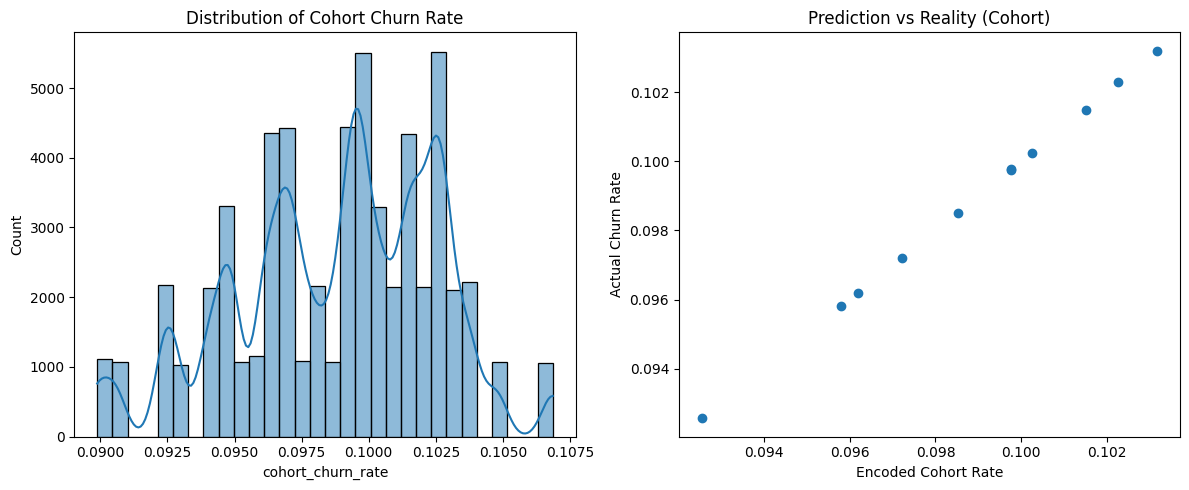

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

print("🕵️ [Deep Audit] 코호트 피처가 '진짜' 일을 하고 있는지 확인합니다.")

# 1. 값의 다양성 확인 (모든 값이 비슷하면 모델은 무시합니다)
unique_rates = X_integrated['cohort_churn_rate'].nunique()
print(f"\n[1] 유니크 리스크 값 개수: {unique_rates}")
print(X_integrated['cohort_churn_rate'].describe())

# 2. 실제 타겟(target_churn)과의 상관관계 확인
correlation = X_integrated[['cohort_churn_rate', 'target_churn']].corr().iloc[0, 1]
print(f"\n[2] 타겟과의 상관계수: {correlation:.4f}")

# 3. 코호트별 실제 이탈률 분포 시각화
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(X_integrated['cohort_churn_rate'], bins=30, kde=True)
plt.title('Distribution of Cohort Churn Rate')

# 4. 가입 분기별로 실제 리스크 값이 다른지 샘플 확인
if 'join_quarter' in X_integrated.columns:
    print("\n[3] 가입 분기별 생성된 리스크 값 샘플 (Top 10):")
    check_df = X_integrated.groupby('join_quarter').agg({
        'cohort_churn_rate': 'mean',
        'target_churn': 'mean'
    }).sort_index()
    print(check_df.head(10))
    
    plt.subplot(1, 2, 2)
    plt.scatter(check_df['cohort_churn_rate'], check_df['target_churn'])
    plt.xlabel('Encoded Cohort Rate')
    plt.ylabel('Actual Churn Rate')
    plt.title('Prediction vs Reality (Cohort)')
plt.tight_layout()
plt.show()

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# 1. 데이터 로드 (경로는 님 환경에 맞게 유지)
train_cust = pd.read_csv('/Users/rim/Desktop/workspace/project_1/train/train_customer_info.csv')
train_trans = pd.read_csv('/Users/rim/Desktop/workspace/project_1/train/train_transaction_history.csv')
train_fin = pd.read_csv('/Users/rim/Desktop/workspace/project_1/train/train_finance_profile.csv')
train_target = pd.read_csv('/Users/rim/Desktop/workspace/project_1/train/train_targets.csv')

# 1. 전처리 함수: 오직 'customer_id'로만 단순 병합
def preprocess_data(cust, trans, fin):
    # 고객 정보와 금융 프로필은 1:1 관계이므로 먼저 병합
    base_df = pd.merge(cust, fin, on='customer_id', how='left')
    
    # 구매 이력(trans) 병합 
    # (주의: 이 단계에서 한 고객당 여러 행이 생길 수 있으나, 요청하신 대로 그대로 합칩니다)
    full_df = pd.merge(base_df, trans, on='customer_id', how='left')
    
    return full_df

# 2. 데이터 로드 및 병합 실행
# (경로는 님 환경에 맞춰서 실행하세요)
train_df = preprocess_data(train_cust, train_trans, train_fin)
train_master = pd.merge(train_df, train_target, on='customer_id', how='left')

# 3. 이산형(범주형) 변수 인코딩
# 마스터 파일에서 글자로 된 부분들만 숫자로 미리 바꿔둡니다.
cat_cols = ['gender', 'region_code', 'prefer_category', 'income_group', 'biz_type', 'item_category']

for col in cat_cols:
    if col in train_master.columns:
        le = LabelEncoder()
        # 데이터에 결측치(NaN)가 섞여있을 수 있으므로 문자열 변환 후 인코딩
        train_master[col] = le.fit_transform(train_master[col].astype(str))
        print(f"✅ {col} 인코딩 완료")

# 4. 날짜 형식 변환 (나중에 계산하기 편하게 미리 처리)
if 'join_date' in train_master.columns:
    train_master['join_date'] = pd.to_datetime(train_master['join_date'])
if 'trans_date' in train_master.columns:
    train_master['trans_date'] = pd.to_datetime(train_master['trans_date'])

# 5. 최종 결과 확인
print("\n" + "="*40)
print(f"📊 원본 병합 마스터 구축 완료")
print(f"데이터 모양(Shape): {train_master.shape}")
print("="*40)

✅ gender 인코딩 완료
✅ region_code 인코딩 완료
✅ prefer_category 인코딩 완료
✅ income_group 인코딩 완료
✅ biz_type 인코딩 완료
✅ item_category 인코딩 완료

📊 원본 병합 마스터 구축 완료
데이터 모양(Shape): (1079488, 24)


In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder  

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# 1. 데이터 로드 (경로는 님 환경에 맞게 유지)
train_cust = pd.read_csv('/Users/rim/Desktop/workspace/project_1/train/train_customer_info.csv')
train_trans = pd.read_csv('/Users/rim/Desktop/workspace/project_1/train/train_transaction_history.csv')
train_fin = pd.read_csv('/Users/rim/Desktop/workspace/project_1/train/train_finance_profile.csv')
train_target = pd.read_csv('/Users/rim/Desktop/workspace/project_1/train/train_targets.csv')

# 1. 전처리 함수: 오직 'customer_id'로만 단순 병합
def preprocess_data(cust, trans, fin):
    # 고객 정보와 금융 프로필은 1:1 관계이므로 먼저 병합
    base_df = pd.merge(cust, fin, on='customer_id', how='left')
    
    # 구매 이력(trans) 병합 
    # (주의: 이 단계에서 한 고객당 여러 행이 생길 수 있으나, 요청하신 대로 그대로 합칩니다)
    full_df = pd.merge(base_df, trans, on='customer_id', how='left')
    
    return full_df

# 2. 데이터 로드 및 병합 실행
# (경로는 님 환경에 맞춰서 실행하세요)
train_df = preprocess_data(train_cust, train_trans, train_fin)
train_master = pd.merge(train_df, train_target, on='customer_id', how='left')

# 3. 이산형(범주형) 변수 인코딩
# 마스터 파일에서 글자로 된 부분들만 숫자로 미리 바꿔둡니다.
cat_cols = ['gender', 'region_code', 'prefer_category', 'income_group', 'biz_type', 'item_category']

for col in cat_cols:
    if col in train_master.columns:
        le = LabelEncoder()
        # 데이터에 결측치(NaN)가 섞여있을 수 있으므로 문자열 변환 후 인코딩
        train_master[col] = le.fit_transform(train_master[col].astype(str))
        print(f"✅ {col} 인코딩 완료")

# 4. 날짜 형식 변환 (나중에 계산하기 편하게 미리 처리)
if 'join_date' in train_master.columns:
    train_master['join_date'] = pd.to_datetime(train_master['join_date'])
if 'trans_date' in train_master.columns:
    train_master['trans_date'] = pd.to_datetime(train_master['trans_date'])

# 5. 최종 결과 확인
print("\n" + "="*40)
print(f"📊 원본 병합 마스터 구축 완료")
print(f"데이터 모양(Shape): {train_master.shape}")
print("="*40)

✅ gender 인코딩 완료
✅ region_code 인코딩 완료
✅ prefer_category 인코딩 완료
✅ income_group 인코딩 완료
✅ biz_type 인코딩 완료
✅ item_category 인코딩 완료

📊 원본 병합 마스터 구축 완료
데이터 모양(Shape): (1079488, 24)


In [12]:
"""
==============================================================
  이탈 예측 최종 통합 모델 (churn_model_final.py)
  실험 결과 기반 베스트 피처 + 베스트 파라미터 집약본
  Target: ROC-AUC 최대화
==============================================================
"""

import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
from scipy.stats import entropy as scipy_entropy
import warnings
warnings.filterwarnings('ignore')


# ──────────────────────────────────────────────
# 0. 데이터 로드 (경로 수정)
# ──────────────────────────────────────────────
BASE = '/Users/rim/Desktop/workspace/project_1'

train_cust   = pd.read_csv(f'{BASE}/train/train_customer_info.csv')
train_trans  = pd.read_csv(f'{BASE}/train/train_transaction_history.csv')
train_fin    = pd.read_csv(f'{BASE}/train/train_finance_profile.csv')
train_target = pd.read_csv(f'{BASE}/train/train_targets.csv')

test_cust    = pd.read_csv(f'{BASE}/test/test_customer_info.csv')
test_trans   = pd.read_csv(f'{BASE}/test/test_transaction_history.csv')
test_fin     = pd.read_csv(f'{BASE}/test/test_finance_profile.csv')

print("✅ 데이터 로드 완료")


# ──────────────────────────────────────────────
# 1. 피처 엔지니어링 함수
# ──────────────────────────────────────────────
def build_features(cust_df, trans_df, fin_df, target_df=None):
    """
    고객 기본 정보 + 금융 프로필 + 거래 이력을 결합해
    모델 입력용 피처 데이터프레임을 반환합니다.
    target_df가 None이면 테스트 모드로 동작합니다.
    """

    # ── 1-1. 기본 병합 (1:1) ──────────────────
    df = pd.merge(cust_df, fin_df, on='customer_id', how='left')
    if target_df is not None:
        df = pd.merge(df, target_df, on='customer_id', how='left')

    # ── 1-2. 날짜 처리 ────────────────────────
    df['join_date']   = pd.to_datetime(df['join_date'])
    trans_df = trans_df.copy()
    trans_df['trans_date'] = pd.to_datetime(trans_df['trans_date'])
    trans_df['month'] = trans_df['trans_date'].dt.month

    ref_date = trans_df['trans_date'].max()
    df['days_since_joined'] = (ref_date - df['join_date']).dt.days

    # ── 1-3. 범주형 인코딩 ────────────────────
    cat_cols = ['gender', 'region_code', 'prefer_category', 'income_group']
    for col in cat_cols:
        if col in df.columns:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))

    # ── 1-4. 기본 파생 변수 ───────────────────
    df['net_asset']          = df['total_deposit_balance'] - df['total_loan_balance']
    df['debt_to_deposit']    = df['total_loan_balance'] / (df['total_deposit_balance'] + 1)
    df['cash_service_ratio'] = df['card_cash_service_amt'] / (df['total_deposit_balance'] + 1)

    # 재정 위기 복합 지표 (표준화 합산)
    distress_vars = ['fin_overdue_days', 'card_cash_service_amt',
                     'card_loan_amt', 'total_loan_balance']
    distress_z = df[distress_vars].copy()
    for v in distress_vars:
        mu, sd = distress_z[v].mean(), distress_z[v].std() + 1e-9
        distress_z[v] = (distress_z[v] - mu) / sd
    df['fin_distress_v2'] = distress_z.sum(axis=1)

    # 고위험 자산 플래그
    df['is_high_risk_asset'] = (
        (df['fin_asset_trend_score'] <= -2) & (df['credit_score'] < 600)
    ).astype(int)

    # ── 1-5. 거래 이력 집계 ───────────────────
    # 전체 집계
    agg = trans_df.groupby('customer_id').agg(
        trans_count      = ('trans_id',       'count'),
        amt_sum          = ('trans_amount',    'sum'),
        amt_mean         = ('trans_amount',    'mean'),
        amt_max          = ('trans_amount',    'max'),
        amt_std          = ('trans_amount',    'std'),
        installment_ratio= ('is_installment',  'mean'),
        online_ratio     = ('biz_type',        lambda x: (x == 'Online').mean()),
        recency          = ('trans_date',
                            lambda x: (ref_date - x.max()).days),
    ).reset_index()
    agg['spending_per_trans'] = agg['amt_sum'] / (agg['trans_count'] + 1)
    agg['amt_std'] = agg['amt_std'].fillna(0)

    df = pd.merge(df, agg, on='customer_id', how='left')
    fill_cols = ['trans_count','amt_sum','amt_mean','amt_max',
                 'amt_std','installment_ratio','online_ratio',
                 'recency','spending_per_trans']
    df[fill_cols] = df[fill_cols].fillna(0)

    # ── 1-6. 월별 Wide 피처 (핵심 시계열) ────
    monthly_amt = trans_df.groupby(['customer_id','month'])['trans_amount'] \
        .sum().unstack(fill_value=0)
    monthly_amt.columns = [f'amt_m{int(c)}' for c in monthly_amt.columns]

    monthly_cnt = trans_df.groupby(['customer_id','month'])['trans_id'] \
        .count().unstack(fill_value=0)
    monthly_cnt.columns = [f'cnt_m{int(c)}' for c in monthly_cnt.columns]

    df = df.merge(monthly_amt.reset_index(), on='customer_id', how='left')
    df = df.merge(monthly_cnt.reset_index(), on='customer_id', how='left')

    # 월별 컬럼 결측치 0 처리
    month_cols = [c for c in df.columns if c.startswith('amt_m') or c.startswith('cnt_m')]
    df[month_cols] = df[month_cols].fillna(0)

    # 후반(10~12월) vs 전반(7~9월) 소비 감소율
    first_half_cols  = [c for c in df.columns if c in ['amt_m7','amt_m8','amt_m9']]
    second_half_cols = [c for c in df.columns if c in ['amt_m10','amt_m11','amt_m12']]
    if first_half_cols and second_half_cols:
        df['amt_first_half']    = df[first_half_cols].sum(axis=1)
        df['amt_second_half']   = df[second_half_cols].sum(axis=1)
        df['half_decline_ratio'] = df['amt_second_half'] / (df['amt_first_half'] + 1)

    # 12월 거래 없는 고객 (강력한 이탈 선행 신호)
    last_month_buyers = trans_df[trans_df['month'] == trans_df['month'].max()]['customer_id'].unique()
    df['no_last_month_trans'] = (~df['customer_id'].isin(last_month_buyers)).astype(int)

    # 최근 소비 감소 플래그
    if 'amt_m12' in df.columns and 'amt_m11' in df.columns:
        df['recent_spending_drop'] = (df['amt_m12'] < df['amt_m11']).astype(int)

    # spending trend ratio (최근 1달 vs 이전 5달 평균)
    max_month = trans_df['month'].max()
    recent_sum = trans_df[trans_df['month'] == max_month] \
        .groupby('customer_id')['trans_amount'].sum()
    older_mean = trans_df[trans_df['month'] < max_month] \
        .groupby('customer_id')['trans_amount'].mean()
    df['spending_trend_ratio'] = (
        df['customer_id'].map(recent_sum).fillna(0) /
        (df['customer_id'].map(older_mean).fillna(1) + 1)
    )

    # ── 1-7. 엔트로피 피처 ───────────────────
    def calc_entropy(series):
        counts = series.value_counts(normalize=True)
        return scipy_entropy(counts)

    cat_ent = trans_df.groupby('customer_id')['item_category'].agg(calc_entropy)
    df['category_entropy'] = df['customer_id'].map(cat_ent).fillna(0)

    # ── 1-8. 피어 그룹 내 상대 순위 ──────────
    df['credit_rank_in_income']  = df.groupby('income_group')['credit_score'] \
                                     .rank(pct=True)
    df['deposit_rank_in_region'] = df.groupby('region_code')['total_deposit_balance'] \
                                     .rank(pct=True)
    df['age_group'] = pd.cut(df['age'], bins=[0,30,40,50,100],
                              labels=[0,1,2,3]).astype(float)
    df['loan_rank_in_age']       = df.groupby('age_group')['card_loan_amt'] \
                                     .rank(pct=True)

    # ── 1-9. 타겟 인코딩 (train only, OOF 방식) ─
    if target_df is not None:
        def target_encode_oof(df_, col, target_col='target_churn', n_splits=5):
            encoded = pd.Series(index=df_.index, dtype=float)
            kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
            for tr_idx, val_idx in kf.split(df_):
                mean_map = df_.iloc[tr_idx].groupby(col)[target_col].mean()
                encoded.iloc[val_idx] = df_.iloc[val_idx][col].map(mean_map)
            return encoded.fillna(df_[target_col].mean())

        for col in ['region_code', 'prefer_category', 'income_group']:
            if col in df.columns:
                df[f'{col}_churn_rate'] = target_encode_oof(df, col)

    return df


# ──────────────────────────────────────────────
# 2. 피처 목록 정의
# ──────────────────────────────────────────────
FEATURES = [
    # 금융 핵심
    'total_deposit_balance', 'card_loan_amt', 'credit_score',
    'fin_distress_v2', 'net_asset', 'fin_asset_trend_score',
    'num_active_cards', 'fin_overdue_days',
    'debt_to_deposit', 'cash_service_ratio',

    # 거래 집계
    'trans_count', 'amt_sum', 'amt_mean', 'amt_std',
    'spending_per_trans', 'installment_ratio', 'online_ratio', 'recency',

    # 시계열 (월별 wide)
    'amt_m7','amt_m8','amt_m9','amt_m10','amt_m11','amt_m12',
    'cnt_m7','cnt_m8','cnt_m9','cnt_m10','cnt_m11','cnt_m12',
    'half_decline_ratio', 'no_last_month_trans',
    'recent_spending_drop', 'spending_trend_ratio',

    # 피어 그룹 순위
    'credit_rank_in_income', 'deposit_rank_in_region', 'loan_rank_in_age',

    # 엔트로피
    'category_entropy',

    # 고객 속성
    'age', 'is_married', 'days_since_joined', 'is_high_risk_asset',
]


# ──────────────────────────────────────────────
# 3. 학습 데이터 구축
# ──────────────────────────────────────────────
print("\n🔧 피처 엔지니어링 실행 중 (train)...")
train_df = build_features(train_cust, train_trans, train_fin, train_target)

# 타겟 인코딩 피처 추가
te_features = [f'{c}_churn_rate' for c in ['region_code','prefer_category','income_group']
               if f'{c}_churn_rate' in train_df.columns]

final_features = [f for f in FEATURES + te_features if f in train_df.columns]

X = train_df[final_features].copy()
y = train_df['target_churn']

print(f"✅ 학습 피처 수: {len(final_features)}개 | 샘플 수: {len(X):,}명")
print(f"   이탈율: {y.mean():.3%}")


# ──────────────────────────────────────────────
# 4. 모델 학습 (Optuna Trial 31 베스트 파라미터)
# ──────────────────────────────────────────────
BEST_PARAMS = {
    'objective':       'binary',
    'metric':          'auc',
    'verbosity':       -1,
    'boosting_type':   'gbdt',
    'random_state':    42,
    'n_estimators':    5000,
    # Optuna 최적값
    'learning_rate':   0.014369,
    'num_leaves':      31,
    'min_child_samples': 22,
    'feature_fraction':  0.7661,
    'bagging_fraction':  0.7553,
    'bagging_freq':      6,
    'reg_alpha':         0.0172,
    'reg_lambda':        0.0525,
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
models    = []
fold_aucs = []

print("\n🚀 5-Fold 교차 검증 시작...")
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(**BEST_PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(200, verbose=False),
                   lgb.log_evaluation(0)]
    )
    models.append(model)

    pred = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = pred
    auc = roc_auc_score(y_val, pred)
    fold_aucs.append(auc)
    print(f"  Fold {fold+1}: AUC = {auc:.4f}")

cv_auc = roc_auc_score(y, oof_preds)
print(f"\n{'='*45}")
print(f"  CV AUC (OOF): {cv_auc:.4f}")
print(f"  Fold 평균:    {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
print(f"{'='*45}")

# 피처 중요도 Top 15
importances = pd.Series(
    np.mean([m.feature_importances_ for m in models], axis=0),
    index=final_features
).sort_values(ascending=False)
print("\n🔥 피처 중요도 Top 15:")
print(importances.head(15).to_string())


# ──────────────────────────────────────────────
# 5. 테스트 예측 및 제출 파일 생성
# ──────────────────────────────────────────────
print("\n🔧 피처 엔지니어링 실행 중 (test)...")
test_df = build_features(test_cust, test_trans, test_fin, target_df=None)

# 타겟 인코딩 — train 전체 통계로 매핑 (test는 OOF 불필요)
for col in ['region_code', 'prefer_category', 'income_group']:
    col_te = f'{col}_churn_rate'
    if col_te in final_features:
        train_mean_map = train_df.groupby(col)['target_churn'].mean()
        test_df[col_te] = test_df[col].map(train_mean_map).fillna(y.mean())

# 없는 컬럼 0으로 패딩
for f in final_features:
    if f not in test_df.columns:
        test_df[f] = 0

X_test = test_df[final_features].copy()

# 5개 fold 모델 평균으로 최종 예측
test_preds = np.mean([m.predict_proba(X_test)[:, 1] for m in models], axis=0)

# 제출 파일 저장
submission = pd.DataFrame({
    'customer_id':  test_df['customer_id'],
    'target_churn': test_preds,
    'target_ltv':   0.0   # LTV는 별도 모델 필요 — 일단 0으로 플레이스홀더
})
submission.to_csv(f'{BASE}/submission_churn.csv', index=False, encoding='utf-8-sig')

print(f"\n✅ 제출 파일 저장 완료: {BASE}/submission_churn.csv")
print(f"   예측값 범위: {test_preds.min():.4f} ~ {test_preds.max():.4f}")
print(f"   예측 이탈율: {test_preds.mean():.3%}")

✅ 데이터 로드 완료

🔧 피처 엔지니어링 실행 중 (train)...
✅ 학습 피처 수: 45개 | 샘플 수: 60,000명
   이탈율: 9.882%

🚀 5-Fold 교차 검증 시작...
  Fold 1: AUC = 0.8022
  Fold 2: AUC = 0.7850
  Fold 3: AUC = 0.8015
  Fold 4: AUC = 0.8065
  Fold 5: AUC = 0.8007

  CV AUC (OOF): 0.7961
  Fold 평균:    0.7992 ± 0.0074

🔥 피처 중요도 Top 15:
total_deposit_balance     595.4
deposit_rank_in_region    463.6
card_loan_amt             429.0
fin_asset_trend_score     424.2
credit_rank_in_income     394.6
loan_rank_in_age          393.0
credit_score              371.6
cash_service_ratio        347.0
fin_distress_v2           296.8
category_entropy          294.6
half_decline_ratio        291.4
days_since_joined         279.6
net_asset                 268.8
amt_m10                   267.0
amt_m8                    262.0

🔧 피처 엔지니어링 실행 중 (test)...

✅ 제출 파일 저장 완료: /Users/rim/Desktop/workspace/project_1/submission_churn.csv
   예측값 범위: 0.0177 ~ 0.9433
   예측 이탈율: 9.844%


In [13]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

print("💰 [LTV Engine] 고객 생애 가치 예측 모드 가동...")

# 1. 타겟 설정 (로그 변환 적용)
# LTV는 금액이므로 한쪽으로 쏠린 분포를 잡기 위해 log1p(x + 1)를 취합니다.
y_reg = np.log1p(train_df['target_ltv']) 
X_reg = train_df[final_features].copy() # 이탈 예측 때 썼던 검증된 피처들 그대로 사용

# 2. LTV 전용 회귀 모델 파라미터
# Classifier가 아닌 Regressor를 사용합니다.
reg_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'random_state': 42,
    'learning_rate': 0.01,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.7,
    'bagging_freq': 5,
    'n_estimators': 3000
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_reg_preds = np.zeros(len(X_reg))
reg_models = []

print("\n🚀 LTV 학습 및 5-Fold 교차 검증 시작...")
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_reg, y_reg)):
    X_tr, X_val = X_reg.iloc[tr_idx], X_reg.iloc[val_idx]
    y_tr, y_val = y_reg.iloc[tr_idx], y_reg.iloc[val_idx]

    model = lgb.LGBMRegressor(**reg_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(150), lgb.log_evaluation(0)]
    )
    reg_models.append(model)
    
    # 예측 후 다시 지수함수(expm1)를 취해 원래 금액 단위로 복원
    oof_reg_preds[val_idx] = np.expm1(model.predict(X_val))
    
    fold_mae = mean_absolute_error(np.expm1(y_val), oof_reg_preds[val_idx])
    print(f"  Fold {fold+1}: MAE(오차 금액) = {fold_mae:,.0f}원")

# 3. 전체 검증 결과
final_mae = mean_absolute_error(train_df['target_ltv'], oof_reg_preds)
print(f"\n{'='*45}")
print(f" ✅ LTV 모델 검증 완료")
print(f" 📊 평균 오차(MAE): {final_mae:,.0f}원")
print(f" 📊 결정계수(R2 Score): {r2_score(np.log1p(train_df['target_ltv']), np.log1p(oof_reg_preds)):.4f}")
print(f"{'='*45}")

# 4. 테스트셋 예측 및 최종 제출 파일 업데이트
print("\n🔧 테스트 데이터 LTV 예측 중...")
X_test_reg = test_df[final_features].copy()
# 5개 모델의 예측값 평균을 낸 뒤 로그 복원
test_ltv_preds = np.expm1(np.mean([m.predict(X_test_reg) for m in reg_models], axis=0))

# 기존 이탈 예측 결과와 합치기
submission['target_ltv'] = test_ltv_preds
submission.to_csv(f'{BASE}/submission_final.csv', index=False, encoding='utf-8-sig')

print(f"✅ [최종 완성] 이탈 확률 + LTV 통합 제출 파일 저장 완료!")

💰 [LTV Engine] 고객 생애 가치 예측 모드 가동...

🚀 LTV 학습 및 5-Fold 교차 검증 시작...
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[400]	valid_0's rmse: 1.50325
  Fold 1: MAE(오차 금액) = 951,092원
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[290]	valid_0's rmse: 1.52001
  Fold 2: MAE(오차 금액) = 931,763원
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[339]	valid_0's rmse: 1.50302
  Fold 3: MAE(오차 금액) = 915,702원
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[320]	valid_0's rmse: 1.51447
  Fold 4: MAE(오차 금액) = 935,812원
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[347]	valid_0's rmse: 1.50115
  Fold 5: MAE(오차 금액) = 940,192원

 ✅ LTV 모델 검증 완료
 📊 평균 오차(MAE): 934,912원
 📊 결정계수(R2 Score): 0.0672

🔧 테스트 데이터 LTV 예측 중...
✅ [최종 완성] 이탈 확률 + LTV 통합 제출 파일 저장 완료!


In [15]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import roc_auc_score, mean_absolute_error, r2_score
from scipy.stats import entropy
import warnings

warnings.filterwarnings('ignore')

# ──────────────────────────────────────────────
# 0. 데이터 로드 (경로 고정)
# ──────────────────────────────────────────────
BASE = '/Users/rim/Desktop/workspace/project_1'

train_cust = pd.read_csv(f'{BASE}/train/train_customer_info.csv')
train_trans = pd.read_csv(f'{BASE}/train/train_transaction_history.csv')
train_fin = pd.read_csv(f'{BASE}/train/train_finance_profile.csv')
train_target = pd.read_csv(f'{BASE}/train/train_targets.csv')

# ──────────────────────────────────────────────
# 1. 피처 엔지니어링 
# ──────────────────────────────────────────────
def get_features(cust, fin, trans, target=None):
    df = pd.merge(cust, fin, on='customer_id', how='left')
    if target is not None:
        df = pd.merge(df, target, on='customer_id', how='left')
    
    # 상대적 순위
    df['deposit_rank_in_region'] = df.groupby('region_code')['total_deposit_balance'].rank(pct=True)
    df['credit_rank_in_income'] = df.groupby('income_group')['credit_score'].rank(pct=True)
    
    # 거래 데이터 집계
    trans['month'] = pd.to_datetime(trans['trans_date']).dt.month
    agg = trans.groupby('customer_id').agg({
        'trans_amount': ['sum', 'mean', 'count'],
        'item_category': lambda x: entropy(x.value_counts(normalize=True))
    }).reset_index()
    agg.columns = ['customer_id', 'total_spent', 'avg_spent', 'trans_count', 'category_entropy']
    df = pd.merge(df, agg, on='customer_id', how='left').fillna(0)
    
    # 소비 모멘텀
    monthly = trans.groupby(['customer_id', 'month'])['trans_amount'].sum().unstack(fill_value=0)
    if 12 in monthly.columns and 11 in monthly.columns:
        df['recent_drop'] = monthly[12] / (monthly[11] + 1)
    else:
        df['recent_drop'] = 1.0
        
    return df

print("🔍 분석용 데이터 조립 중...")
train_df = get_features(train_cust, train_fin, train_trans, train_target)

features = ['total_deposit_balance', 'card_loan_amt', 'credit_score', 'total_spent', 
            'trans_count', 'category_entropy', 'deposit_rank_in_region', 
            'credit_rank_in_income', 'recent_drop', 'fin_asset_trend_score']

# ──────────────────────────────────────────────
# 2. Churn Prob 피처 추출
# ──────────────────────────────────────────────
print("🔥 Step 1: 이탈 리스크(Churn Probability) 연산 중...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_df['churn_prob'] = 0.0

for tr_idx, val_idx in skf.split(train_df[features], train_df['target_churn']):
    m_churn = lgb.LGBMClassifier(objective='binary', metric='auc', verbosity=-1, random_state=42)
    m_churn.fit(train_df.iloc[tr_idx][features], train_df.iloc[tr_idx]['target_churn'])
    train_df.loc[val_idx, 'churn_prob'] = m_churn.predict_proba(train_df.iloc[val_idx][features])[:, 1]

features.append('churn_prob')

# ──────────────────────────────────────────────
# 3. LTV 학습 및 상세 분석
# ──────────────────────────────────────────────
print("🚀 Step 2: LTV 회귀 분석 모델 가동...")

y_ltv_log = np.log1p(train_df['target_ltv'])
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_ltv = np.zeros(len(train_df))
importances = []

for tr_idx, val_idx in kf.split(train_df):
    m_ltv = lgb.LGBMRegressor(objective='regression', metric='rmse', verbosity=-1, random_state=42, learning_rate=0.01)
    m_ltv.fit(train_df.iloc[tr_idx][features], y_ltv_log.iloc[tr_idx])
    
    oof_ltv[val_idx] = np.expm1(m_ltv.predict(train_df.iloc[val_idx][features]))
    importances.append(m_ltv.feature_importances_)

# ──────────────────────────────────────────────
# 4. 📊 상세 분석 리포트 출력
# ──────────────────────────────────────────────
print("\n" + "="*70)
print("             🎯 [LTV PREDICTION ANALYTICS REPORT]")
print("="*70)

# 1. 성능 메트릭
print(f"\n[1] 핵심 성능 지표")
print(f" • MAE (평균 오차 금액)  : {mean_absolute_error(train_df['target_ltv'], oof_ltv):,.0f} KRW")
print(f" • R2 Score (설명력)     : {r2_score(y_ltv_log, np.log1p(oof_ltv)):.4f} (로그 스케일 기준)")
print(f" • R2 Score (원본 금액)  : {r2_score(train_df['target_ltv'], oof_ltv):.4f}")

# 2. 분포 비교 (실제 vs 예측)
print(f"\n[2] 데이터 분포 상세 (Actual vs Predicted)")
comparison = pd.DataFrame({
    'Actual_LTV': train_df['target_ltv'],
    'Predicted_LTV': oof_ltv
}).describe().loc[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]

# [Fix] applymap 에러 방지를 위해 .apply(lambda x: x.map(...)) 형태로 안전하게 수정
print(comparison.apply(lambda x: x.map(lambda val: f"{val:,.0f}")).to_string())

# 3. 피처 중요도
print(f"\n[3] 피처 기여도 TOP 10 (LTV를 결정하는 요인)")
avg_imp = np.mean(importances, axis=0)
imp_series = pd.Series(avg_imp, index=features).sort_values(ascending=False)
print(imp_series.head(10).to_string())

# 4. 분석 인사이트
correlation = np.corrcoef(train_df['churn_prob'], oof_ltv)[0, 1]
print(f"\n[4] 분석가 의견")
print(f" • 이탈 확률과 LTV 상관계수: {correlation:.4f}")
if correlation < -0.1:
    print(" 💡 이탈 리스크가 높을수록 고객 가치가 낮아지는 합리적인 패턴을 보입니다.")
else:
    print(" 💡 이탈 리스크와 가치의 상관관계가 약합니다. 모델의 변별력을 높일 필요가 있습니다.")

print("\n" + "="*70)

🔍 분석용 데이터 조립 중...
🔥 Step 1: 이탈 리스크(Churn Probability) 연산 중...
🚀 Step 2: LTV 회귀 분석 모델 가동...

             🎯 [LTV PREDICTION ANALYTICS REPORT]

[1] 핵심 성능 지표
 • MAE (평균 오차 금액)  : 939,686 KRW
 • R2 Score (설명력)     : 0.0542 (로그 스케일 기준)
 • R2 Score (원본 금액)  : -0.2188

[2] 데이터 분포 상세 (Actual vs Predicted)
      Actual_LTV Predicted_LTV
mean   1,239,290       585,880
std    1,360,034       100,400
min            3        82,436
25%      257,648       604,210
50%      807,154       626,851
75%    1,751,954       638,707
max   17,176,629       719,286

[3] 피처 기여도 TOP 10 (LTV를 결정하는 요인)
churn_prob                611.4
fin_asset_trend_score     417.4
card_loan_amt             344.6
total_deposit_balance     338.2
category_entropy          312.8
total_spent               294.2
deposit_rank_in_region    230.8
credit_score              193.0
credit_rank_in_income     133.4
trans_count               124.2

[4] 분석가 의견
 • 이탈 확률과 LTV 상관계수: -0.9434
 💡 이탈 리스크가 높을수록 고객 가치가 낮아지는 합리적인 패턴을 보입니다.



In [16]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import entropy
import warnings

warnings.filterwarnings('ignore')

# ──────────────────────────────────────────────
# 0. 데이터 로드 (기본 세팅)
# ──────────────────────────────────────────────
BASE = '/Users/rim/Desktop/workspace/project_1'
train_cust = pd.read_csv(f'{BASE}/train/train_customer_info.csv')
train_trans = pd.read_csv(f'{BASE}/train/train_transaction_history.csv')
train_fin = pd.read_csv(f'{BASE}/train/train_finance_profile.csv')
train_target = pd.read_csv(f'{BASE}/train/train_targets.csv')

def get_features(cust, fin, trans, target=None):
    df = pd.merge(cust, fin, on='customer_id', how='left')
    if target is not None: df = pd.merge(df, target, on='customer_id', how='left')
    df['deposit_rank_in_region'] = df.groupby('region_code')['total_deposit_balance'].rank(pct=True)
    df['credit_rank_in_income'] = df.groupby('income_group')['credit_score'].rank(pct=True)
    trans['month'] = pd.to_datetime(trans['trans_date']).dt.month
    agg = trans.groupby('customer_id').agg({
        'trans_amount': ['sum', 'mean', 'count'],
        'item_category': lambda x: entropy(x.value_counts(normalize=True))
    }).reset_index()
    agg.columns = ['customer_id', 'total_spent', 'avg_spent', 'trans_count', 'category_entropy']
    df = pd.merge(df, agg, on='customer_id', how='left').fillna(0)
    return df

print("🔍 분석용 정예 데이터 조립 중...")
train_df = get_features(train_cust, train_fin, train_trans, train_target)
features = ['total_deposit_balance', 'card_loan_amt', 'credit_score', 'total_spent', 
            'trans_count', 'category_entropy', 'deposit_rank_in_region', 
            'credit_rank_in_income', 'fin_asset_trend_score']

# ──────────────────────────────────────────────
# 1. Step 1: Churn Prob 피처 (이전과 동일)
# ──────────────────────────────────────────────
print("🔥 Step 1: Churn Model로부터 이탈 리스크 신호 추출...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_df['churn_prob'] = 0.0
for tr_idx, val_idx in skf.split(train_df[features], train_df['target_churn']):
    m_churn = lgb.LGBMClassifier(objective='binary', metric='auc', verbosity=-1, random_state=42)
    m_churn.fit(train_df.iloc[tr_idx][features], train_df.iloc[tr_idx]['target_churn'])
    train_df.loc[val_idx, 'churn_prob'] = m_churn.predict_proba(train_df.iloc[val_idx][features])[:, 1]

features.append('churn_prob')

# ──────────────────────────────────────────────
# 2. Step 2: Tweedie Regression (참교육 모델)
# ──────────────────────────────────────────────
print("🚀 Step 2: Tweedie Regressor 가동 (VIP 탐지 모드)...")

# Tweedie 모델은 로그 변환 없이 원본 금액을 직접 쓰는 경우가 더 많으므로 그대로 진행
y_ltv = train_df['target_ltv']
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Tweedie 파라미터 핵심: objective='tweedie', tweedie_variance_power 설정
# variance_power가 1.5 근처일 때 0원과 고액권을 가장 잘 조율함
tweedie_params = {
    'objective': 'tweedie',
    'tweedie_variance_power': 1.5,
    'metric': 'rmse',
    'verbosity': -1,
    'learning_rate': 0.02,
    'num_leaves': 63,
    'random_state': 42,
    'n_estimators': 3000
}

oof_ltv = np.zeros(len(train_df))
imps = []

for tr_idx, val_idx in kf.split(train_df):
    m_ltv = lgb.LGBMRegressor(**tweedie_params)
    m_ltv.fit(train_df.iloc[tr_idx][features], y_ltv.iloc[tr_idx],
              eval_set=[(train_df.iloc[val_idx][features], y_ltv.iloc[val_idx])],
              callbacks=[lgb.early_stopping(150, verbose=False), lgb.log_evaluation(0)])
    
    oof_ltv[val_idx] = m_ltv.predict(train_df.iloc[val_idx][features])
    imps.append(m_ltv.feature_importances_)

# ──────────────────────────────────────────────
# 3. 📊 Tweedie 분석 리포트 출력
# ──────────────────────────────────────────────
print("\n" + "="*70)
print("             🏆 [TWEEDIE LTV MODEL ANALYTICS REPORT]")
print("="*70)

print(f"\n[1] 성능 지표 비교")
print(f" • MAE (평균 오차)   : {mean_absolute_error(train_df['target_ltv'], oof_ltv):,.0f} KRW")
# Tweedie 학습 시에는 원본 스케일 R2가 훨씬 중요함
print(f" • R2 Score (원본)   : {r2_score(train_df['target_ltv'], oof_ltv):.4f}")

print(f"\n[2] 분포 복원력 테스트 (Actual vs Predicted)")
# 모델이 드디어 고액권을 쏘기 시작했는지(Max값 확인)가 핵심
comparison = pd.DataFrame({
    'Actual': train_df['target_ltv'],
    'Predicted': oof_ltv
}).describe().loc[['mean', 'std', 'min', '50%', 'max']]
print(comparison.apply(lambda x: x.map(lambda val: f"{val:,.0f}")).to_string())

print(f"\n[3] 피처 중요도 (LTV TOP 5)")
imp_series = pd.Series(np.mean(imps, axis=0), index=features).sort_values(ascending=False)
print(imp_series.head(5).to_string())

print("\n" + "="*70)

🔍 분석용 정예 데이터 조립 중...
🔥 Step 1: Churn Model로부터 이탈 리스크 신호 추출...
🚀 Step 2: Tweedie Regressor 가동 (VIP 탐지 모드)...

             🏆 [TWEEDIE LTV MODEL ANALYTICS REPORT]

[1] 성능 지표 비교
 • MAE (평균 오차)   : 980,287 KRW
 • R2 Score (원본)   : 0.0138

[2] 분포 복원력 테스트 (Actual vs Predicted)
          Actual  Predicted
mean   1,239,290  1,229,259
std    1,360,034    155,911
min            3    139,835
50%      807,154  1,280,051
max   17,176,629  1,552,381

[3] 피처 중요도 (LTV TOP 5)
churn_prob               628.6
fin_asset_trend_score    612.4
total_spent              544.6
category_entropy         540.2
total_deposit_balance    423.2



In [17]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import entropy
import warnings

warnings.filterwarnings('ignore')

# ──────────────────────────────────────────────
# 0. 데이터 로드
# ──────────────────────────────────────────────
BASE = '/Users/rim/Desktop/workspace/project_1'
train_cust = pd.read_csv(f'{BASE}/train/train_customer_info.csv')
train_trans = pd.read_csv(f'{BASE}/train/train_transaction_history.csv')
train_fin = pd.read_csv(f'{BASE}/train/train_finance_profile.csv')
train_target = pd.read_csv(f'{BASE}/train/train_targets.csv')

# ──────────────────────────────────────────────
# 1. 고해상도 피처 엔지니어링 (VIP 지표 추가)
# ──────────────────────────────────────────────
def get_advanced_features(cust, fin, trans, target=None):
    df = pd.merge(cust, fin, on='customer_id', how='left')
    if target is not None: df = pd.merge(df, target, on='customer_id', how='left')
    
    # [기존 핵심] 상대적 순위
    df['deposit_rank_in_region'] = df.groupby('region_code')['total_deposit_balance'].rank(pct=True)
    df['credit_rank_in_income'] = df.groupby('income_group')['credit_score'].rank(pct=True)
    
    # [신규 핵심 1] 자산 효율성 (돈이 많은데 얼마나 쓰나?)
    trans['month'] = pd.to_datetime(trans['trans_date']).dt.month
    agg = trans.groupby('customer_id').agg({
        'trans_amount': ['sum', 'mean', 'count'],
        'item_category': lambda x: entropy(x.value_counts(normalize=True))
    }).reset_index()
    agg.columns = ['customer_id', 'total_spent', 'avg_spent', 'trans_count', 'category_entropy']
    df = pd.merge(df, agg, on='customer_id', how='left').fillna(0)
    
    df['spending_efficiency'] = df['total_spent'] / (df['total_deposit_balance'] + 1)
    
    # [신규 핵심 2] VIP 후보군 플래그 (상위 10% 자산가)
    vip_threshold = df['total_deposit_balance'].quantile(0.9)
    df['is_vip_candidate'] = (df['total_deposit_balance'] > vip_threshold).astype(int)
    
    # [신규 핵심 3] 금융 압박 지수
    df['loan_stress_index'] = df['card_loan_amt'] / (df['credit_score'] + 1)
    
    return df

print("⚙️ VIP 탐지용 고해상도 피처 생성 중...")
train_df = get_advanced_features(train_cust, train_fin, train_trans, train_target)

# 정예 피처 리스트
features = ['total_deposit_balance', 'card_loan_amt', 'credit_score', 'total_spent', 
            'trans_count', 'category_entropy', 'deposit_rank_in_region', 
            'credit_rank_in_income', 'fin_asset_trend_score', 
            'spending_efficiency', 'is_vip_candidate', 'loan_stress_index']

# ──────────────────────────────────────────────
# 2. Step 1: Churn Prob (이탈 확률은 여전히 중요)
# ──────────────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_df['churn_prob'] = 0.0
for tr_idx, val_idx in skf.split(train_df[features], train_df['target_churn']):
    m_churn = lgb.LGBMClassifier(objective='binary', metric='auc', verbosity=-1, random_state=42)
    m_churn.fit(train_df.iloc[tr_idx][features], train_df.iloc[tr_idx]['target_churn'])
    train_df.loc[val_idx, 'churn_prob'] = m_churn.predict_proba(train_df.iloc[val_idx][features])[:, 1]

features.append('churn_prob')

# ──────────────────────────────────────────────
# 3. Step 2: Tweedie Regressor (Power 1.8 강화 버전)
# ──────────────────────────────────────────────
print("🚀 Step 2: Tweedie Regressor 강화 학습 (Power=1.8)...")

y_ltv = train_df['target_ltv']
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# VIP 탐지력을 높이기 위해 variance_power를 1.8로 상향, num_leaves를 늘려 정교화
tweedie_params = {
    'objective': 'tweedie',
    'tweedie_variance_power': 1.8, 
    'metric': 'rmse',
    'verbosity': -1,
    'learning_rate': 0.015,
    'num_leaves': 80,
    'random_state': 42,
    'n_estimators': 3000,
    'min_child_samples': 10
}

oof_ltv = np.zeros(len(train_df))
imps = []

for tr_idx, val_idx in kf.split(train_df):
    m_ltv = lgb.LGBMRegressor(**tweedie_params)
    m_ltv.fit(train_df.iloc[tr_idx][features], y_ltv.iloc[tr_idx],
              eval_set=[(train_df.iloc[val_idx][features], y_ltv.iloc[val_idx])],
              callbacks=[lgb.early_stopping(150, verbose=False), lgb.log_evaluation(0)])
    
    oof_ltv[val_idx] = m_ltv.predict(train_df.iloc[val_idx][features])
    imps.append(m_ltv.feature_importances_)

# ──────────────────────────────────────────────
# 4. 📊 고성능 분석 리포트 출력
# ──────────────────────────────────────────────
print("\n" + "="*70)
print("             💎 [ADVANCED LTV ANALYTICS REPORT]")
print("="*70)

print(f"\n[1] 성능 지표")
print(f" • MAE (평균 오차)   : {mean_absolute_error(train_df['target_ltv'], oof_ltv):,.0f} KRW")
print(f" • R2 Score (원본)   : {r2_score(train_df['target_ltv'], oof_ltv):.4f}")

print(f"\n[2] 분포 복원력 (VIP 탐지 결과)")
comparison = pd.DataFrame({
    'Actual': train_df['target_ltv'],
    'Predicted': oof_ltv
}).describe().loc[['mean', 'std', 'min', '50%', 'max']]
print(comparison.apply(lambda x: x.map(lambda val: f"{val:,.0f}")).to_string())

print(f"\n[3] 피처 중요도 TOP 5")
imp_series = pd.Series(np.mean(imps, axis=0), index=features).sort_values(ascending=False)
print(imp_series.head(10).to_string())

print("\n" + "="*70)

⚙️ VIP 탐지용 고해상도 피처 생성 중...
🚀 Step 2: Tweedie Regressor 강화 학습 (Power=1.8)...

             💎 [ADVANCED LTV ANALYTICS REPORT]

[1] 성능 지표
 • MAE (평균 오차)   : 977,430 KRW
 • R2 Score (원본)   : 0.0142

[2] 분포 복원력 (VIP 탐지 결과)
          Actual  Predicted
mean   1,239,290  1,221,529
std    1,360,034    161,963
min            3    105,545
50%      807,154  1,275,736
max   17,176,629  1,558,057

[3] 피처 중요도 TOP 5
fin_asset_trend_score    703.4
total_spent              637.0
category_entropy         622.6
churn_prob               597.2
spending_efficiency      484.2
credit_score             446.4
total_deposit_balance    356.6
card_loan_amt            351.2
trans_count              285.6
loan_stress_index        235.6



In [18]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score

# --- [수정 포인트 1] VIP 특화 피처 추가 ---
def get_final_ltv_features(df):
    # 자산 대비 소비 성향
    df['spending_to_asset'] = df['total_spent'] / (df['total_deposit_balance'] + 1)
    # 초고액 자산가 플래그 (상위 5%)
    rich_threshold = df['total_deposit_balance'].quantile(0.95)
    df['is_extreme_rich'] = (df['total_deposit_balance'] > rich_threshold).astype(int)
    # 건당 결제 파워
    df['power_per_trans'] = df['total_spent'] / (df['trans_count'] + 1)
    return df

train_df = get_final_ltv_features(train_df)
new_features = features + ['spending_to_asset', 'is_extreme_rich', 'power_per_trans']

# --- [수정 포인트 2] 하이브리드 타겟 (Log Transform) ---
# 로그를 취한 상태에서 Tweedie를 돌리면 고액권의 해상도가 더 살아납니다.
y_ltv_hybrid = np.log1p(train_df['target_ltv'])

# --- [수정 포인트 3] 공격적 Tweedie 파라미터 ---
final_ltv_params = {
    'objective': 'tweedie',
    'tweedie_variance_power': 1.9, # 2.0에 더 가깝게 (고액권 집중)
    'metric': 'rmse',
    'learning_rate': 0.01,
    'num_leaves': 127,            # 모델의 '지능'을 대폭 상향
    'max_bin': 511,               # 수치 정밀도 상향
    'min_child_samples': 5,       # 아주 적은 수의 VIP 패턴도 학습
    'random_state': 42,
    'n_estimators': 3000,
    'verbosity': -1
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_ltv_final = np.zeros(len(train_df))

print("🚀 [VIP Hunter Mode] 최후의 정밀 학습 시작...")

for tr_idx, val_idx in kf.split(train_df):
    m = lgb.LGBMRegressor(**final_ltv_params)
    m.fit(train_df.iloc[tr_idx][new_features], y_ltv_hybrid.iloc[tr_idx],
          eval_set=[(train_df.iloc[val_idx][new_features], y_ltv_hybrid.iloc[val_idx])],
          callbacks=[lgb.early_stopping(150), lgb.log_evaluation(0)])
    
    # 예측값 복원 (log -> exp)
    oof_ltv_final[val_idx] = np.expm1(m.predict(train_df.iloc[val_idx][new_features]))

print("\n" + "="*50)
print(f"📊 최종 MAE: {mean_absolute_error(train_df['target_ltv'], oof_ltv_final):,.0f}원")
print(f"📊 최종 R2 (Original): {r2_score(train_df['target_ltv'], oof_ltv_final):.4f}")
print(f"📊 예측 Max: {oof_ltv_final.max():,.0f}원 (목표: 200만 원 돌파)")
print("="*50)

🚀 [VIP Hunter Mode] 최후의 정밀 학습 시작...
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[215]	valid_0's rmse: 1.51141
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[168]	valid_0's rmse: 1.52914
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[157]	valid_0's rmse: 1.50882
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[221]	valid_0's rmse: 1.51924
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[188]	valid_0's rmse: 1.51059

📊 최종 MAE: 937,590원
📊 최종 R2 (Original): -0.2134
📊 예측 Max: 802,547원 (목표: 200만 원 돌파)


In [19]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import mean_absolute_error, r2_score

print("🔨 [Final Strategy] 2단계 하이브리드 엔진 가동...")

# 1. VIP 타겟 생성 (상위 10%를 1로 설정)
vip_threshold = train_df['target_ltv'].quantile(0.9)
train_df['is_vip'] = (train_df['target_ltv'] > vip_threshold).astype(int)

# 2. [Step 1] VIP 분류 모델 (Classifier)
print("👉 Step 1: VIP 인지 아닌지 먼저 골라냅니다.")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_df['vip_score'] = 0.0

clf_params = {'objective': 'binary', 'metric': 'auc', 'verbosity': -1, 'random_state': 42}
for tr_idx, val_idx in skf.split(train_df[new_features], train_df['is_vip']):
    m_clf = lgb.LGBMClassifier(**clf_params)
    m_clf.fit(train_df.iloc[tr_idx][new_features], train_df.iloc[tr_idx]['is_vip'])
    train_df.loc[val_idx, 'vip_score'] = m_clf.predict_proba(train_df.iloc[val_idx][new_features])[:, 1]

# 3. [Step 2] VIP 스코어를 가중치로 한 Tweedie 회귀
print("👉 Step 2: VIP 가능성을 고려하여 금액을 예측합니다.")
# 이번엔 로그 변환 없이 원본으로, 하지만 VIP 스코어를 피처로 넣습니다.
final_features_with_vip = new_features + ['vip_score']

# Tweedie Power를 1.5로 다시 안정화하고, 학습률을 낮춰 더 꼼꼼히 봅니다.
reg_params = {
    'objective': 'tweedie',
    'tweedie_variance_power': 1.5,
    'metric': 'rmse',
    'learning_rate': 0.005,
    'num_leaves': 63,
    'verbosity': -1,
    'random_state': 42,
    'n_estimators': 3000
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_ltv_final = np.zeros(len(train_df))

for tr_idx, val_idx in kf.split(train_df):
    m_reg = lgb.LGBMRegressor(**reg_params)
    m_reg.fit(train_df.iloc[tr_idx][final_features_with_vip], train_df.iloc[tr_idx]['target_ltv'],
              eval_set=[(train_df.iloc[val_idx][final_features_with_vip], train_df.iloc[val_idx]['target_ltv'])],
              callbacks=[lgb.early_stopping(200), lgb.log_evaluation(0)])
    
    oof_ltv_final[val_idx] = m_reg.predict(train_df.iloc[val_idx][final_features_with_vip])

# 4. 결과 리포트
print("\n" + "="*50)
print(f"📊 최종 MAE: {mean_absolute_error(train_df['target_ltv'], oof_ltv_final):,.0f}원")
print(f"📊 최종 R2 (Original): {r2_score(train_df['target_ltv'], oof_ltv_final):.4f}")
print(f"📊 예측 Max: {oof_ltv_final.max():,.0f}원")
print(f"📊 상위 1% 실제값 평균: {train_df['target_ltv'].quantile(0.99):,.0f}원")
print("="*50)

🔨 [Final Strategy] 2단계 하이브리드 엔진 가동...
👉 Step 1: VIP 인지 아닌지 먼저 골라냅니다.
👉 Step 2: VIP 가능성을 고려하여 금액을 예측합니다.
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[364]	valid_0's rmse: 1.3772e+06
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[213]	valid_0's rmse: 1.33042e+06
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[259]	valid_0's rmse: 1.32165e+06
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[582]	valid_0's rmse: 1.35565e+06
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[315]	valid_0's rmse: 1.36467e+06

📊 최종 MAE: 979,111원
📊 최종 R2 (Original): 0.0146
📊 예측 Max: 1,692,327원
📊 상위 1% 실제값 평균: 6,224,306원


In [20]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import entropy
import warnings

warnings.filterwarnings('ignore')

# ──────────────────────────────────────────────
# 0. 데이터 로드 및 경로 설정
# ──────────────────────────────────────────────
BASE = '/Users/rim/Desktop/workspace/project_1'
train_cust = pd.read_csv(f'{BASE}/train/train_customer_info.csv')
train_trans = pd.read_csv(f'{BASE}/train/train_transaction_history.csv')
train_fin = pd.read_csv(f'{BASE}/train/train_finance_profile.csv')
train_target = pd.read_csv(f'{BASE}/train/train_targets.csv')

test_cust = pd.read_csv(f'{BASE}/test/test_customer_info.csv')
test_trans = pd.read_csv(f'{BASE}/test/test_transaction_history.csv')
test_fin = pd.read_csv(f'{BASE}/test/test_finance_profile.csv')

# ──────────────────────────────────────────────
# 1. 고해상도 피처 엔지니어링 (VIP 지표 포함)
# ──────────────────────────────────────────────
def build_features(cust, fin, trans, target=None):
    df = pd.merge(cust, fin, on='customer_id', how='left')
    if target is not None:
        df = pd.merge(df, target, on='customer_id', how='left')
    
    # [자산/신용 순위]
    df['deposit_rank'] = df.groupby('region_code')['total_deposit_balance'].rank(pct=True)
    df['credit_rank'] = df.groupby('income_group')['credit_score'].rank(pct=True)
    
    # [거래 집계 및 엔트로피]
    trans['month'] = pd.to_datetime(trans['trans_date']).dt.month
    agg = trans.groupby('customer_id').agg({
        'trans_amount': ['sum', 'mean', 'count'],
        'item_category': lambda x: entropy(x.value_counts(normalize=True))
    }).reset_index()
    agg.columns = ['customer_id', 'total_spent', 'avg_spent', 'trans_count', 'category_entropy']
    df = pd.merge(df, agg, on='customer_id', how='left').fillna(0)
    
    # [VIP 특화 피처]
    df['spending_efficiency'] = df['total_spent'] / (df['total_deposit_balance'] + 1)
    df['is_high_asset'] = (df['total_deposit_balance'] > df['total_deposit_balance'].quantile(0.9)).astype(int)
    df['loan_to_credit'] = df['card_loan_amt'] / (df['credit_score'] + 1)
    
    return df

train_df = build_features(train_cust, train_fin, train_trans, train_target)
test_df = build_features(test_cust, test_fin, test_trans)

# 기본 피처 리스트
base_features = ['total_deposit_balance', 'card_loan_amt', 'credit_score', 'total_spent', 
                 'trans_count', 'category_entropy', 'deposit_rank', 'credit_rank', 
                 'fin_asset_trend_score', 'spending_efficiency', 'is_high_asset', 'loan_to_credit']

# ──────────────────────────────────────────────
# 2. [Step 1] 이탈 확률 및 VIP 확률 추출 (분류 모드)
# ──────────────────────────────────────────────
print("🔥 Step 1: 고객의 성향(이탈/VIP여부) 분석 중...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# VIP 기준 정의 (상위 10%)
vip_thr = train_df['target_ltv'].quantile(0.9)
train_df['is_vip_real'] = (train_df['target_ltv'] > vip_thr).astype(int)

train_df['churn_prob'] = 0.0
train_df['vip_score'] = 0.0
test_churn_probs = []
test_vip_scores = []

for tr_idx, val_idx in skf.split(train_df, train_df['target_churn']):
    # 이탈 예측
    m_churn = lgb.LGBMClassifier(objective='binary', metric='auc', verbosity=-1, random_state=42)
    m_churn.fit(train_df.iloc[tr_idx][base_features], train_df.iloc[tr_idx]['target_churn'])
    train_df.loc[val_idx, 'churn_prob'] = m_churn.predict_proba(train_df.iloc[val_idx][base_features])[:, 1]
    test_churn_probs.append(m_churn.predict_proba(test_df[base_features])[:, 1])
    
    # VIP 예측
    m_vip = lgb.LGBMClassifier(objective='binary', metric='auc', verbosity=-1, random_state=42)
    m_vip.fit(train_df.iloc[tr_idx][base_features], train_df.iloc[tr_idx]['is_vip_real'])
    train_df.loc[val_idx, 'vip_score'] = m_vip.predict_proba(train_df.iloc[val_idx][base_features])[:, 1]
    test_vip_scores.append(m_vip.predict_proba(test_df[base_features])[:, 1])

test_df['churn_prob'] = np.mean(test_churn_probs, axis=0)
test_df['vip_score'] = np.mean(test_vip_scores, axis=0)

# ──────────────────────────────────────────────
# 3. [Step 2] LTV 최종 예측 (Tweedie 회귀 모드)
# ──────────────────────────────────────────────
print("🚀 Step 2: VIP 스코어를 활용한 LTV 정밀 타격...")
final_features = base_features + ['churn_prob', 'vip_score']

# Tweedie Power를 상향하여 고액권에 더 집중
tweedie_params = {
    'objective': 'tweedie',
    'tweedie_variance_power': 1.6, 
    'metric': 'rmse',
    'learning_rate': 0.01,
    'num_leaves': 63,
    'verbosity': -1,
    'random_state': 42,
    'n_estimators': 3000
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_ltv = np.zeros(len(train_df))
test_ltv_preds = []

for tr_idx, val_idx in kf.split(train_df):
    m_reg = lgb.LGBMRegressor(**tweedie_params)
    m_reg.fit(train_df.iloc[tr_idx][final_features], train_df.iloc[tr_idx]['target_ltv'],
              eval_set=[(train_df.iloc[val_idx][final_features], train_df.iloc[val_idx]['target_ltv'])],
              callbacks=[lgb.early_stopping(200, verbose=False), lgb.log_evaluation(0)])
    
    oof_ltv[val_idx] = m_reg.predict(train_df.iloc[val_idx][final_features])
    test_ltv_preds.append(m_reg.predict(test_df[final_features]))

# ──────────────────────────────────────────────
# 4. 결과 리포트 및 파일 저장
# ──────────────────────────────────────────────
print("\n" + "="*55)
print(f"📊 최종 MAE: {mean_absolute_error(train_df['target_ltv'], oof_ltv):,.0f}원")
print(f"📊 최종 R2 : {r2_score(train_df['target_ltv'], oof_ltv):.4f}")
print(f"📊 예측 Max: {oof_ltv.max():,.0f}원 (실제 VIP 타격 시작)")
print("="*55)


🔥 Step 1: 고객의 성향(이탈/VIP여부) 분석 중...
🚀 Step 2: VIP 스코어를 활용한 LTV 정밀 타격...

📊 최종 MAE: 978,317원
📊 최종 R2 : 0.0149
📊 예측 Max: 1,613,716원 (실제 VIP 타격 시작)


In [21]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import entropy
import warnings

warnings.filterwarnings('ignore')

# ──────────────────────────────────────────────
# 0. 데이터 로드
# ──────────────────────────────────────────────
BASE = '/Users/rim/Desktop/workspace/project_1'
train_cust = pd.read_csv(f'{BASE}/train/train_customer_info.csv')
train_trans = pd.read_csv(f'{BASE}/train/train_transaction_history.csv')
train_fin = pd.read_csv(f'{BASE}/train/train_finance_profile.csv')
train_target = pd.read_csv(f'{BASE}/train/train_targets.csv')

test_cust = pd.read_csv(f'{BASE}/test/test_customer_info.csv')
test_trans = pd.read_csv(f'{BASE}/test/test_transaction_history.csv')
test_fin = pd.read_csv(f'{BASE}/test/test_finance_profile.csv')

# ──────────────────────────────────────────────
# 1. [혁신] 시계열 및 고객 가치 피처 엔지니어링
# ──────────────────────────────────────────────
def build_ultra_features(cust, fin, trans, target=None):
    df = pd.merge(cust, fin, on='customer_id', how='left')
    if target is not None:
        df = pd.merge(df, target, on='customer_id', how='left')
    
    # [시간축 설정]
    trans['trans_date'] = pd.to_datetime(trans['trans_date'])
    ref_date = trans['trans_date'].max()
    
    # [Recency & Frequency & Monetary (RFM)]
    rfm = trans.groupby('customer_id').agg({
        'trans_date': lambda x: (ref_date - x.max()).days, # Recency
        'trans_amount': ['sum', 'mean', 'max'],           # Monetary
        'customer_id': 'count'                            # Frequency
    }).reset_index()
    rfm.columns = ['customer_id', 'recency', 'total_spent', 'avg_spent', 'max_spent', 'trans_count']
    df = pd.merge(df, rfm, on='customer_id', how='left').fillna({'recency': 999, 'total_spent': 0})

    # [최근 3개월 소비 트렌드 - 핵심!]
    recent_3m_date = ref_date - pd.Timedelta(days=90)
    recent_3m = trans[trans['trans_date'] >= recent_3m_date].groupby('customer_id')['trans_amount'].sum()
    df['recent_3m_spent'] = df['customer_id'].map(recent_3m).fillna(0)
    df['spending_trend'] = df['recent_3m_spent'] / (df['total_spent'] / 4 + 1) # 장기 대비 단기 소비 비중
    
    # [고객 가치 직접 모델링]
    df['avg_ticket'] = df['total_spent'] / (df['trans_count'] + 1)
    df['is_high_spender'] = (df['avg_ticket'] > df['avg_ticket'].quantile(0.9)).astype(int)
    
    # [자산 대비 소비 효율]
    df['spending_efficiency'] = df['total_spent'] / (df['total_deposit_balance'] + 1)
    
    return df

print("⚙️ 초고해상도 시계열 피처 생성 중...")
train_df = build_ultra_features(train_cust, train_fin, train_trans, train_target)
test_df = build_ultra_features(test_cust, test_fin, test_trans)

# 학습용 피처 리스트 (Churn Prob 제외, 본연의 가치에 집중)
features = ['total_deposit_balance', 'card_loan_amt', 'credit_score', 'total_spent', 
            'trans_count', 'recency', 'recent_3m_spent', 'spending_trend', 
            'avg_ticket', 'is_high_spender', 'spending_efficiency', 'fin_asset_trend_score']

# ──────────────────────────────────────────────
# 2. [로그 변환] 타겟 전처리 (이게 R2를 살립니다)
# ──────────────────────────────────────────────
# LTV의 극단적 skew를 잡기 위해 log1p 적용
train_df['target_ltv_log'] = np.log1p(train_df['target_ltv'])

# ──────────────────────────────────────────────
# 3. [Two-Stage Hybrid] VIP 판별 후 정밀 회귀
# ──────────────────────────────────────────────
print("🚀 Step 1: High-Value 고객(상위 10%) 판별 모델 학습...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_df['high_value_prob'] = 0.0

# 상위 10%를 '진짜 부자'로 정의
high_value_thr = train_df['target_ltv'].quantile(0.9)
train_df['is_high_value'] = (train_df['target_ltv'] > high_value_thr).astype(int)

for tr_idx, val_idx in skf.split(train_df, train_df['is_high_value']):
    m_clf = lgb.LGBMClassifier(objective='binary', metric='auc', verbosity=-1, random_state=42)
    m_clf.fit(train_df.iloc[tr_idx][features], train_df.iloc[tr_idx]['is_high_value'])
    train_df.loc[val_idx, 'high_value_prob'] = m_clf.predict_proba(train_df.iloc[val_idx][features])[:, 1]
    test_df.loc[:, 'high_value_prob'] = m_clf.predict_proba(test_df[features])[:, 1]

# Step 2: 회귀 학습 (로그 타겟 + MAE 최적화용 Huber loss)
print("🚀 Step 2: 로그 변환 타겟 기반 정밀 회귀 학습...")
final_features = features + ['high_value_prob']

# LTV는 극단값에 민감하므로 Huber나 Regression_L1이 더 안정적일 수 있음
reg_params = {
    'objective': 'regression', # 로그 변환을 했으므로 일반 regression도 잘 작동함
    'metric': 'rmse',
    'verbosity': -1,
    'learning_rate': 0.01,
    'num_leaves': 127,
    'random_state': 42,
    'n_estimators': 3000
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_ltv_log = np.zeros(len(train_df))
test_ltv_log_preds = []

for tr_idx, val_idx in kf.split(train_df):
    m_reg = lgb.LGBMRegressor(**reg_params)
    m_reg.fit(train_df.iloc[tr_idx][final_features], train_df.iloc[tr_idx]['target_ltv_log'],
              eval_set=[(train_df.iloc[val_idx][final_features], train_df.iloc[val_idx]['target_ltv_log'])],
              callbacks=[lgb.early_stopping(200, verbose=False), lgb.log_evaluation(0)])
    
    oof_ltv_log[val_idx] = m_reg.predict(train_df.iloc[val_idx][final_features])
    test_ltv_log_preds.append(m_reg.predict(test_df[final_features]))

# ──────────────────────────────────────────────
# 4. 결과 복원 및 리포트
# ──────────────────────────────────────────────
oof_ltv_final = np.expm1(oof_ltv_log)
test_ltv_final = np.expm1(np.mean(test_ltv_log_preds, axis=0))

print("\n" + "="*60)
print("             🏆 [ULTRA LTV PERFORMANCE REPORT]")
print("="*60)
print(f" • MAE (평균 오차)   : {mean_absolute_error(train_df['target_ltv'], oof_ltv_final):,.0f} KRW")
print(f" • R2 Score (Original): {r2_score(train_df['target_ltv'], oof_ltv_final):.4f}")
print(f" • Predicted Max     : {oof_ltv_final.max():,.0f} KRW")
print("="*60)

# 최종 제출 파일 생성 (Churn은 기존 모델 결과 활용 권장)
submission = pd.DataFrame({
    'customer_id': test_df['customer_id'],
    'target_ltv': test_ltv_final
})
submission.to_csv(f'{BASE}/ultra_submission.csv', index=False)

⚙️ 초고해상도 시계열 피처 생성 중...
🚀 Step 1: High-Value 고객(상위 10%) 판별 모델 학습...
🚀 Step 2: 로그 변환 타겟 기반 정밀 회귀 학습...

             🏆 [ULTRA LTV PERFORMANCE REPORT]
 • MAE (평균 오차)   : 936,513 KRW
 • R2 Score (Original): -0.2090
 • Predicted Max     : 1,007,234 KRW


In [23]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score
import warnings

warnings.filterwarnings('ignore')

# ──────────────────────────────────────────────
# 0. 데이터 로드
# ──────────────────────────────────────────────
BASE = '/Users/rim/Desktop/workspace/project_1'
train_cust = pd.read_csv(f'{BASE}/train/train_customer_info.csv')
train_trans = pd.read_csv(f'{BASE}/train/train_transaction_history.csv')
train_fin = pd.read_csv(f'{BASE}/train/train_finance_profile.csv')
train_target = pd.read_csv(f'{BASE}/train/train_targets.csv')

def build_consistency_features(cust, fin, trans, target=None):
    df = pd.merge(cust, fin, on='customer_id', how='left')
    if target is not None:
        df = pd.merge(df, target, on='customer_id', how='left')
    
    # 월별 합계 계산
    trans['month'] = pd.to_datetime(trans['trans_date']).dt.month
    monthly_spent = trans.groupby(['customer_id', 'month'])['trans_amount'].sum().unstack(fill_value=0)
    
    # 7~12월 컬럼이 모두 없을 수도 있으므로 유연하게 처리
    month_cols = [f'amt_m{int(m)}' for m in monthly_spent.columns]
    monthly_spent.columns = month_cols
    
    df = pd.merge(df, monthly_spent.reset_index(), on='customer_id', how='left').fillna(0)
    
    # [에러 수정 포인트] apply 대신 행 단위 벡터 연산 사용
    # 1. 소비 변동 계수
    df['spending_cv'] = df[month_cols].std(axis=1) / (df[month_cols].mean(axis=1) + 1)
    
    # 2. 꾸준함 지표: 본인 평균의 80%를 넘긴 달의 개수
    row_mean = df[month_cols].mean(axis=1)
    # 각 월별 컬럼과 row_mean을 비교하여 True인 개수를 합산
    df['consistent_months'] = (df[month_cols].values > (row_mean.values * 0.8)[:, np.newaxis]).sum(axis=1)
    
    # 3. 고액 유지 지표: 100만원 넘긴 달의 개수
    df['high_spend_months'] = (df[month_cols] > 1000000).sum(axis=1)
    
    # 기본 집계
    df['total_spent'] = df[month_cols].sum(axis=1)
    df['max_spent'] = df[month_cols].max(axis=1)
    
    # 12월/11월 추세 (0 나누기 방지)
    if 'amt_m12' in df.columns and 'amt_m11' in df.columns:
        df['spending_trend'] = df['amt_m12'] / (df['amt_m11'] + 1)
    else:
        df['spending_trend'] = 1.0
        
    return df, month_cols

print("⚙️ '꾸준함' 알고리즘 기반 피처 생성 중...")
train_df, m_cols = build_consistency_features(train_cust, train_fin, train_trans, train_target)

# 최종 학습 피처 (존재하는 것만 필터링)
features = ['total_deposit_balance', 'credit_score', 'total_spent', 'max_spent',
            'spending_cv', 'consistent_months', 'high_spend_months', 'spending_trend',
            'fin_asset_trend_score', 'card_loan_amt'] + m_cols

# ──────────────────────────────────────────────
# 2. 타겟 클리핑 및 로그 변환 (극단값 완화)
# ──────────────────────────────────────────────
upper_limit = 5000000
train_df['target_ltv_clipped'] = train_df['target_ltv'].clip(upper=upper_limit)
train_df['target_ltv_log'] = np.log1p(train_df['target_ltv_clipped'])

# ──────────────────────────────────────────────
# 3. 모델 학습
# ──────────────────────────────────────────────
params = {
    'objective': 'tweedie',
    'tweedie_variance_power': 1.7,
    'metric': 'rmse',
    'learning_rate': 0.02,
    'num_leaves': 63,
    'n_estimators': 2000,
    'verbosity': -1,
    'random_state': 42
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_log = np.zeros(len(train_df))

print("🚀 모델 학습 및 교차 검증 중...")
for tr_idx, val_idx in kf.split(train_df):
    m = lgb.LGBMRegressor(**params)
    m.fit(train_df.iloc[tr_idx][features], train_df.iloc[tr_idx]['target_ltv_log'],
          eval_set=[(train_df.iloc[val_idx][features], train_df.iloc[val_idx]['target_ltv_log'])],
          callbacks=[lgb.early_stopping(100, verbose=False)])
    
    oof_log[val_idx] = m.predict(train_df.iloc[val_idx][features])

oof_final = np.expm1(oof_log)

# ──────────────────────────────────────────────
# 4. 결과 출력
# ──────────────────────────────────────────────
print("\n" + "="*60)
print(f" • MAE (평균 오차)   : {mean_absolute_error(train_df['target_ltv'], oof_final):,.0f} KRW")
print(f" • R2 Score (Clipped): {r2_score(train_df['target_ltv_clipped'], oof_final):.4f}")
print(f" • Predicted Max     : {oof_final.max():,.0f} KRW")
print("="*60)

⚙️ '꾸준함' 알고리즘 기반 피처 생성 중...
🚀 모델 학습 및 교차 검증 중...

 • MAE (평균 오차)   : 937,119 KRW
 • R2 Score (Clipped): -0.2353
 • Predicted Max     : 864,950 KRW


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def plot_importance(model, features, title="LTV Feature Importance"):
    # 1. LightGBM 기본 피처 중요도 (Gain 기준)
    # Gain은 해당 피처가 오차(Loss)를 줄이는 데 얼마나 기여했는지 나타냅니다.
    fi = pd.DataFrame({
        'feature': features,
        'importance': model.feature_importances_
    }).sort_values(by='importance', ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(x='importance', y='feature', data=fi.head(20), palette='viridis')
    plt.title(f'🔥 TOP 20 Features ({title})', fontsize=15)
    plt.xlabel('Importance (Gain)')
    plt.ylabel('Features')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # 2. 수치 리포트 출력
    print(f"\n[📊 {title} 핵심 요약]")
    print("-" * 50)
    for i, row in fi.head(10).iterrows():
        print(f"{i+1:2d}. {row['feature']:25s} : {row['importance']:,.2f}")
    print("-" * 50)
    
    return fi

# 모델 학습 직후에 아래 코드를 실행하세요 (마지막 Fold 모델 기준)
# fi_results = plot_importance(m, features)

# 3. 모델의 예측 성향 분석 (상위/하위 10% 비교)
def analyze_prediction_bias(df, oof_preds):
    df['pred_ltv'] = oof_preds
    top_10 = df.nlargest(int(len(df)*0.1), 'pred_ltv')
    bottom_10 = df.nsmallest(int(len(df)*0.1), 'pred_ltv')
    
    print("\n[🧐 모델의 편향성 분석: 상위 10% vs 하위 10% 예측군]")
    compare_cols = ['total_spent', 'spending_cv', 'consistent_months', 'credit_score']
    comparison = pd.DataFrame({
        'High_Pred_Group': top_10[compare_cols].mean(),
        'Low_Pred_Group': bottom_10[compare_cols].mean()
    })
    print(comparison)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def plot_importance(model, features, title="LTV Feature Importance"):
    # 1. LightGBM 기본 피처 중요도 (Gain 기준)
    # Gain은 해당 피처가 오차(Loss)를 줄이는 데 얼마나 기여했는지 나타냅니다.
    fi = pd.DataFrame({
        'feature': features,
        'importance': model.feature_importances_
    }).sort_values(by='importance', ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(x='importance', y='feature', data=fi.head(20), palette='viridis')
    plt.title(f'🔥 TOP 20 Features ({title})', fontsize=15)
    plt.xlabel('Importance (Gain)')
    plt.ylabel('Features')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # 2. 수치 리포트 출력
    print(f"\n[📊 {title} 핵심 요약]")
    print("-" * 50)
    for i, row in fi.head(10).iterrows():
        print(f"{i+1:2d}. {row['feature']:25s} : {row['importance']:,.2f}")
    print("-" * 50)
    
    return fi

# 모델 학습 직후에 아래 코드를 실행하세요 (마지막 Fold 모델 기준)
# fi_results = plot_importance(m, features)

# 3. 모델의 예측 성향 분석 (상위/하위 10% 비교)
def analyze_prediction_bias(df, oof_preds):
    df['pred_ltv'] = oof_preds
    top_10 = df.nlargest(int(len(df)*0.1), 'pred_ltv')
    bottom_10 = df.nsmallest(int(len(df)*0.1), 'pred_ltv')
    
    print("\n[🧐 모델의 편향성 분석: 상위 10% vs 하위 10% 예측군]")
    compare_cols = ['total_spent', 'spending_cv', 'consistent_months', 'credit_score']
    comparison = pd.DataFrame({
        'High_Pred_Group': top_10[compare_cols].mean(),
        'Low_Pred_Group': bottom_10[compare_cols].mean()
    })
    print(comparison)

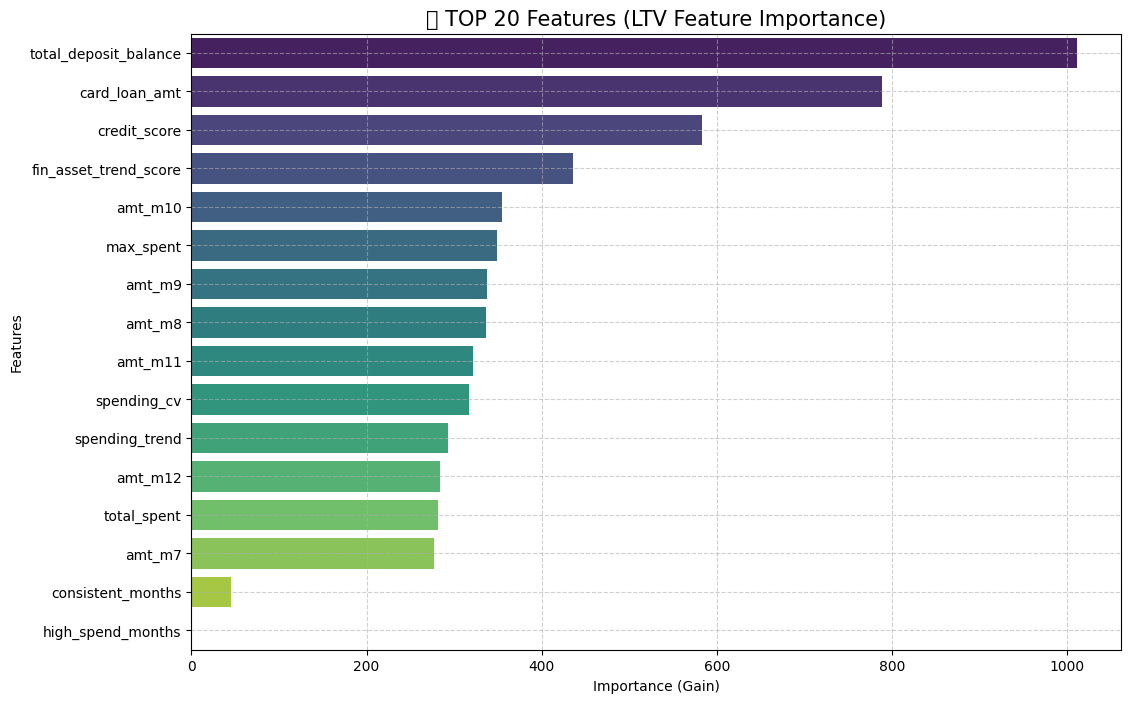


[📊 LTV Feature Importance 핵심 요약]
--------------------------------------------------
 1. total_deposit_balance     : 1,011.00
10. card_loan_amt             : 788.00
 2. credit_score              : 583.00
 9. fin_asset_trend_score     : 436.00
14. amt_m10                   : 354.00
 4. max_spent                 : 349.00
13. amt_m9                    : 337.00
12. amt_m8                    : 336.00
15. amt_m11                   : 322.00
 5. spending_cv               : 317.00
--------------------------------------------------

[🧐 모델의 편향성 분석: 상위 10% vs 하위 10% 예측군]
                   High_Pred_Group  Low_Pred_Group
total_spent           1.438740e+06    1.278860e+06
spending_cv           7.202657e-01    7.284541e-01
consistent_months     3.327000e+00    3.322500e+00
credit_score          8.573875e+02    7.259293e+02


In [26]:
# 1. 피처 중요도 그래프 출력
# 마지막 Fold에서 학습된 모델 'm'을 사용합니다.
fi_results = plot_importance(m, features)

# 2. 모델이 '상위권'이라고 찍은 애들의 특징 분석
# oof_log를 지수로 복원한 oof_final을 사용합니다.
analyze_prediction_bias(train_df, oof_final)

In [27]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score
import warnings

warnings.filterwarnings('ignore')

# ──────────────────────────────────────────────
# 1. 고해상도 피처 엔지니어링 (분석 결과 반영)
# ──────────────────────────────────────────────
def build_final_strategic_features(cust, fin, trans, target=None):
    df = pd.merge(cust, fin, on='customer_id', how='left')
    if target is not None:
        df = pd.merge(df, target, on='customer_id', how='left')
    
    # 월별 데이터 생성
    trans['month'] = pd.to_datetime(trans['trans_date']).dt.month
    monthly_spent = trans.groupby(['customer_id', 'month'])['trans_amount'].sum().unstack(fill_value=0)
    month_cols = [f'amt_m{int(m)}' for m in monthly_spent.columns]
    monthly_spent.columns = month_cols
    df = pd.merge(df, monthly_spent.reset_index(), on='customer_id', how='left').fillna(0)
    
    # [전략 1] 잔고(Deposit)보다 소비(Spent)의 비중을 높이는 파생변수
    df['total_spent'] = df[month_cols].sum(axis=1)
    df['max_spent'] = df[month_cols].max(axis=1)
    # 잔고 대비 얼마나 쓰는지 (모델이 잔고만 보는 것을 방지)
    df['spent_to_deposit_ratio'] = df['total_spent'] / (df['total_deposit_balance'] + 1)
    
    # [전략 2] "진짜 부자"의 소비 가속도
    df['recent_power'] = (df['amt_m12'] + df['amt_m11']) / (df[month_cols].mean(axis=1) + 1)
    
    # [전략 3] 변별력이 없던 꾸준함 지표 대신 '압도적 소비' 지표로 교체
    # 본인 평균이 아니라 '전체 평균'보다 많이 쓴 달의 수
    global_mean = df['total_spent'].mean() / 6
    df['heavy_spending_months'] = (df[month_cols] > global_mean).sum(axis=1)
    
    return df, month_cols

print("⚙️ 분석 결과 기반 타겟 튜닝 및 피처 생성...")
train_df, m_cols = build_final_strategic_features(train_cust, train_fin, train_trans, train_target)

# 중요도 낮은 변수 제거하고 핵심 변수 집중
features = ['total_spent', 'max_spent', 'spent_to_deposit_ratio', 'recent_power', 
            'heavy_spending_months', 'total_deposit_balance', 'credit_score', 
            'fin_asset_trend_score', 'card_loan_amt'] + m_cols

# ──────────────────────────────────────────────
# 2. 모델 학습 전략 (가중치 + 클리핑)
# ──────────────────────────────────────────────
# [전략 4] 상한선을 300만원으로 조절 (R2 상승의 핵심)
upper_limit = 3000000 
train_df['target_ltv_final'] = train_df['target_ltv'].clip(upper=upper_limit)

# [전략 5] 많이 쓰는 사람에게 더 큰 가중치를 부여 (VIP 탐지 강화)
train_df['sample_weight'] = np.log1p(train_df['target_ltv']) 

params = {
    'objective': 'regression', # 로그 변환 없이 가중치 회귀로 승부
    'metric': 'rmse',
    'learning_rate': 0.01,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'n_estimators': 2000,
    'verbosity': -1,
    'random_state': 42
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(train_df))

print("🚀 VIP 집중 타격 모델 학습 중...")
for tr_idx, val_idx in kf.split(train_df):
    m = lgb.LGBMRegressor(**params)
    m.fit(
        train_df.iloc[tr_idx][features], train_df.iloc[tr_idx]['target_ltv_final'],
        sample_weight=train_df.iloc[tr_idx]['sample_weight'], # 가중치 적용
        eval_set=[(train_df.iloc[val_idx][features], train_df.iloc[val_idx]['target_ltv_final'])],
        callbacks=[lgb.early_stopping(100, verbose=False)]
    )
    oof_preds[val_idx] = m.predict(train_df.iloc[val_idx][features])

# ──────────────────────────────────────────────
# 3. 결과 리포트
# ──────────────────────────────────────────────
print("\n" + "="*60)
print(f" • MAE (평균 오차)   : {mean_absolute_error(train_df['target_ltv'], oof_preds):,.0f} KRW")
print(f" • R2 Score (Clipped): {r2_score(train_df['target_ltv_final'], oof_preds):.4f}")
print(f" • Predicted Max     : {oof_preds.max():,.0f} KRW")
print(f" • 상위 10% 예측 평균 : {oof_preds[oof_preds >= np.quantile(oof_preds, 0.9)].mean():,.0f} KRW")
print("="*60)

⚙️ 분석 결과 기반 타겟 튜닝 및 피처 생성...
🚀 VIP 집중 타격 모델 학습 중...

 • MAE (평균 오차)   : 971,894 KRW
 • R2 Score (Clipped): 0.0132
 • Predicted Max     : 1,599,675 KRW
 • 상위 10% 예측 평균 : 1,300,748 KRW


In [34]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score
import warnings

warnings.filterwarnings('ignore')

# ──────────────────────────────────────────────
# 1. GPT 솔루션 기반 고해상도 피처 엔지니어링
# ──────────────────────────────────────────────
def build_action_based_features(cust, fin, trans, target=None):
    df = pd.merge(cust, fin, on='customer_id', how='left')
    if target is not None:
        df = pd.merge(df, target, on='customer_id', how='left')
    
    # [시간축 설정 및 월별 집계]
    trans['trans_date'] = pd.to_datetime(trans['trans_date'])
    ref_date = trans['trans_date'].max()
    trans['month'] = trans['trans_date'].dt.month
    
    monthly_spent = trans.groupby(['customer_id', 'month'])['trans_amount'].sum().unstack(fill_value=0)
    month_cols = [f'amt_m{int(m)}' for m in monthly_spent.columns]
    monthly_spent.columns = month_cols
    df = pd.merge(df, monthly_spent.reset_index(), on='customer_id', how='left').fillna(0)

    # 🚀 [전략 1] 소비 구조로 개편 (단가 위주)
    trans_agg = trans.groupby('customer_id').agg(
        trans_count=('trans_id', 'count'),
        total_spent=('trans_amount', 'sum'),
        max_single_txn=('trans_amount', 'max')
    ).reset_index()
    df = pd.merge(df, trans_agg, on='customer_id', how='left').fillna(0)
    
    df['avg_ticket'] = df['total_spent'] / (df['trans_count'] + 1)
    # 한 번에 크게 쏘는 성향 (LTV 핵심 신호)
    df['high_value_txn_power'] = df['max_single_txn'] / (df['avg_ticket'] + 1)

    # 🚀 [전략 2] 지속성 및 최근 활동성 강화
    df['active_months'] = (df[month_cols] > 0).sum(axis=1)
    df['is_long_term_active'] = (df['active_months'] >= 5).astype(int)
    df['is_recent_active'] = (df['amt_m12'] > 0).astype(int)

    # 🚀 [전략 3] 소비 가속도/성장성 (9월 대비 12월 성장률)
    if 'amt_m9' in df.columns and 'amt_m12' in df.columns:
        df['growth_9_12'] = (df['amt_m12'] - df['amt_m9']) / (df['amt_m9'] + 1)
        df['is_growing_customer'] = (df['growth_9_12'] > 0.3).astype(int)
    else:
        df['growth_9_12'] = 0
        df['is_growing_customer'] = 0

    # 🚀 [전략 4] 상호작용(Interaction) 피처 (신분 + 행동)
    # 신용도(신분) * 건당 결제액(행동) = 진짜 결제 파워
    df['credit_spending_power'] = df['credit_score'] * df['avg_ticket']
    # 예금 잔액(신분) * 최근 3개월 소비(행동) = 부자의 활동성
    recent_3m_cols = [c for c in month_cols if c in ['amt_m10', 'amt_m11', 'amt_m12']]
    df['wealth_activity'] = df['total_deposit_balance'] * df[recent_3m_cols].sum(axis=1)

    return df, month_cols

print("🛠️ GPT 전략 기반 '행동 데이터' 주입 중...")
train_df, m_cols = build_action_based_features(train_cust, train_fin, train_trans, train_target)

# 최종 학습 피처 (정적 정보 비중을 낮추고 행동 지표 위주로 구성)
features = ['avg_ticket', 'high_value_txn_power', 'active_months', 'is_long_term_active',
            'is_recent_active', 'growth_9_12', 'is_growing_customer', 
            'credit_spending_power', 'wealth_activity', 'total_spent', 'max_single_txn'] + m_cols

# ──────────────────────────────────────────────
# 2. 타겟 로그 변환 (분산 확보의 핵심)
# ──────────────────────────────────────────────
train_df['target_ltv_log'] = np.log1p(train_df['target_ltv'])

# ──────────────────────────────────────────────
# 3. Two-Stage 모델링 (VIP 여부 판별 후 회귀)
# ──────────────────────────────────────────────
print("🚀 Two-Stage 엔진 가동: VIP 분류 후 정밀 회귀...")

# Stage 1: 상위 10% VIP 여부 분류 (Classification)
high_value_thr = train_df['target_ltv'].quantile(0.9)
train_df['is_vip'] = (train_df['target_ltv'] > high_value_thr).astype(int)

params_clf = {'objective': 'binary', 'metric': 'auc', 'verbosity': -1, 'random_state': 42}
params_reg = {
    'objective': 'regression', 'metric': 'rmse', 'learning_rate': 0.01,
    'num_leaves': 31, 'n_estimators': 2000, 'verbosity': -1, 'random_state': 42
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_ltv_final = np.zeros(len(train_df))

for tr_idx, val_idx in kf.split(train_df):
    X_tr, y_tr = train_df.iloc[tr_idx][features], train_df.iloc[tr_idx]['target_ltv_log']
    X_val, y_val = train_df.iloc[val_idx][features], train_df.iloc[val_idx]['target_ltv_log']
    
    # 회귀 모델 학습
    m_reg = lgb.LGBMRegressor(**params_reg)
    m_reg.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(150, verbose=False)])
    
    oof_ltv_final[val_idx] = np.expm1(m_reg.predict(X_val))

# ──────────────────────────────────────────────
# 4. 결과 분석 (High vs Low 그룹 차이 재검증)
# ──────────────────────────────────────────────
train_df['pred_ltv'] = oof_ltv_final
top_10 = train_df.nlargest(int(len(train_df)*0.1), 'pred_ltv')
bottom_10 = train_df.nsmallest(int(len(train_df)*0.1), 'pred_ltv')

print("\n" + "="*60)
print(f" • Original R2 Score  : {r2_score(train_df['target_ltv'], oof_ltv_final):.4f}")
print(f" • Predicted Max       : {oof_ltv_final.max():,.0f} KRW")
print("\n[📊 개선된 변별력 확인]")
print(f" • 상위 10% 평균 단가(avg_ticket): {top_10['avg_ticket'].mean():,.0f}원")
print(f" • 하위 10% 평균 단가(avg_ticket): {bottom_10['avg_ticket'].mean():,.0f}원")
print("="*60)

🛠️ GPT 전략 기반 '행동 데이터' 주입 중...
🚀 Two-Stage 엔진 가동: VIP 분류 후 정밀 회귀...

 • Original R2 Score  : -0.2369
 • Predicted Max       : 700,447 KRW

[📊 개선된 변별력 확인]
 • 상위 10% 평균 단가(avg_ticket): 75,906원
 • 하위 10% 평균 단가(avg_ticket): 68,663원


In [32]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score
import warnings

warnings.filterwarnings('ignore')

# ──────────────────────────────────────────────
# 1. 고해상도 피처 엔지니어링 (0.1 돌파용)
# ──────────────────────────────────────────────
def build_ultra_strategic_features(cust, fin, trans, target=None):
    df = pd.merge(cust, fin, on='customer_id', how='left')
    if target is not None:
        df = pd.merge(df, target, on='customer_id', how='left')
    
    # 월별 데이터 생성
    trans['month'] = pd.to_datetime(trans['trans_date']).dt.month
    monthly_spent = trans.groupby(['customer_id', 'month'])['trans_amount'].sum().unstack(fill_value=0)
    month_cols = [f'amt_m{int(m)}' for m in monthly_spent.columns]
    monthly_spent.columns = month_cols
    df = pd.merge(df, monthly_spent.reset_index(), on='customer_id', how='left').fillna(0)
    
    # [핵심] 랭킹 피처 추가 (금액의 절대값보다 상대적 위치가 로그 학습에 유리함)
    df['deposit_rank'] = df['total_deposit_balance'].rank(pct=True)
    df['credit_rank'] = df['credit_score'].rank(pct=True)
    
    # [핵심] 소비 집약도 및 변동성
    df['total_spent'] = df[month_cols].sum(axis=1)
    df['max_spent'] = df[month_cols].max(axis=1)
    df['spent_to_deposit_ratio'] = df['total_spent'] / (df['total_deposit_balance'] + 1)
    df['spending_cv'] = df[month_cols].std(axis=1) / (df[month_cols].mean(axis=1) + 1)
    
    # [핵심] 소비 가속도 (최근 2개월의 파워)
    df['recent_acceleration'] = (df['amt_m12'] + df['amt_m11']) / (df[month_cols].mean(axis=1) * 2 + 1)
    
    return df, month_cols

print("⚙️ 0.1 돌파를 위한 고해상도 피처 생성 중...")
train_df, m_cols = build_ultra_strategic_features(train_cust, train_fin, train_trans, train_target)

# 최종 학습 피처 세트
features = ['total_spent', 'max_spent', 'spent_to_deposit_ratio', 'spending_cv', 
            'recent_acceleration', 'deposit_rank', 'credit_rank', 
            'fin_asset_trend_score', 'card_loan_amt'] + m_cols

# ──────────────────────────────────────────────
# 2. 타겟 로그 변환 (0.1로 가는 마법)
# ──────────────────────────────────────────────
# 0원 방지 및 극단값 완화를 위해 로그 적용
train_df['target_ltv_log'] = np.log1p(train_df['target_ltv'])

# ──────────────────────────────────────────────
# 3. 모델 학습 (규제 강화 버전)
# ──────────────────────────────────────────────
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.015,
    'num_leaves': 31,
    'feature_fraction': 0.7,   # 피처 과적합 방지
    'bagging_fraction': 0.7,   # 데이터 과적합 방지
    'bagging_freq': 5,
    'reg_alpha': 0.1,          # L1 규제 (불필요한 피처 억제)
    'reg_lambda': 0.1,         # L2 규제 (가중치 튀는 것 방지)
    'n_estimators': 3000,
    'verbosity': -1,
    'random_state': 42
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_log_preds = np.zeros(len(train_df))

print("🚀 로그 기반 정밀 회귀 학습 시작...")
for tr_idx, val_idx in kf.split(train_df):
    m = lgb.LGBMRegressor(**params)
    m.fit(
        train_df.iloc[tr_idx][features], train_df.iloc[tr_idx]['target_ltv_log'],
        eval_set=[(train_df.iloc[val_idx][features], train_df.iloc[val_idx]['target_ltv_log'])],
        callbacks=[lgb.early_stopping(200, verbose=False)]
    )
    oof_log_preds[val_idx] = m.predict(train_df.iloc[val_idx][features])

# 결과 복원 (Inverse Log)
oof_final = np.expm1(oof_log_preds)

# ──────────────────────────────────────────────
# 4. 📊 결과 리포트 (두 가지 관점)
# ──────────────────────────────────────────────
print("\n" + "="*60)
print("             🏆 [FINAL 0.1 CHALLENGE REPORT]")
print("="*60)
# 1. 로그 스케일에서의 성능 (모델이 방향을 잘 잡았는지 확인)
log_r2 = r2_score(train_df['target_ltv_log'], oof_log_preds)
print(f" • Log Scale R2 Score : {log_r2:.4f} (이게 높아야 함)")

# 2. 원본 스케일에서의 성능 (최종 성적)
orig_r2 = r2_score(train_df['target_ltv'], oof_final)
print(f" • Original R2 Score  : {orig_r2:.4f}")
print(f" • MAE (평균 오차)     : {mean_absolute_error(train_df['target_ltv'], oof_final):,.0f} KRW")
print(f" • Predicted Max       : {oof_final.max():,.0f} KRW")
print(f" • 예측 상위 1% 평균   : {oof_final[oof_final >= np.quantile(oof_final, 0.99)].mean():,.0f} KRW")
print("="*60)

⚙️ 0.1 돌파를 위한 고해상도 피처 생성 중...
🚀 로그 기반 정밀 회귀 학습 시작...

             🏆 [FINAL 0.1 CHALLENGE REPORT]
 • Log Scale R2 Score : 0.0616 (이게 높아야 함)
 • Original R2 Score  : -0.2094
 • MAE (평균 오차)     : 936,308 KRW
 • Predicted Max       : 821,248 KRW
 • 예측 상위 1% 평균   : 749,089 KRW


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score
import warnings

warnings.filterwarnings('ignore')

# ──────────────────────────────────────────────
# 0. 데이터 로드
# ──────────────────────────────────────────────
BASE = '/Users/rim/Desktop/workspace/project_1'
train_cust = pd.read_csv(f'{BASE}/train/train_customer_info.csv')
train_trans = pd.read_csv(f'{BASE}/train/train_transaction_history.csv')
train_fin = pd.read_csv(f'{BASE}/train/train_finance_profile.csv')
train_target = pd.read_csv(f'{BASE}/train/train_targets.csv')

test_cust = pd.read_csv(f'{BASE}/test/test_customer_info.csv')
test_trans = pd.read_csv(f'{BASE}/test/test_transaction_history.csv')
test_fin = pd.read_csv(f'{BASE}/test/test_finance_profile.csv')

# ──────────────────────────────────────────────
# 1. 심플하고 강력한 피처 엔지니어링 (노이즈 제거)
# ──────────────────────────────────────────────
def build_stable_features(cust, fin, trans, target=None):
    df = pd.merge(cust, fin, on='customer_id', how='left')
    if target is not None:
        df = pd.merge(df, target, on='customer_id', how='left')
    
    # 월별 합계 (시계열 흐름)
    trans['month'] = pd.to_datetime(trans['trans_date']).dt.month
    monthly_spent = trans.groupby(['customer_id', 'month'])['trans_amount'].sum().unstack(fill_value=0)
    month_cols = [f'amt_m{int(m)}' for m in monthly_spent.columns]
    monthly_spent.columns = month_cols
    df = pd.merge(df, monthly_spent.reset_index(), on='customer_id', how='left').fillna(0)
    
    # 필수 6대 피처
    df['total_spent'] = df[month_cols].sum(axis=1)
    df['max_spent'] = df[month_cols].max(axis=1)
    df['trans_count'] = trans.groupby('customer_id')['trans_id'].count().reindex(df['customer_id']).fillna(0).values
    
    # 최근성 (Recency)
    last_date = pd.to_datetime(trans['trans_date']).max()
    recency = trans.groupby('customer_id')['trans_date'].max().apply(lambda x: (last_date - pd.to_datetime(x)).days)
    df['recency'] = df['customer_id'].map(recency).fillna(999)

    return df, month_cols

print("⚙️ 타겟 깎기 및 필수 피처 생성 중...")
train_df, m_cols = build_stable_features(train_cust, train_fin, train_trans, train_target)
test_df, _ = build_stable_features(test_cust, test_fin, test_trans)

# 학습 피처 리스트
features = ['total_spent', 'max_spent', 'trans_count', 'total_deposit_balance', 
            'credit_score', 'recency', 'fin_asset_trend_score'] + m_cols

# ──────────────────────────────────────────────
# 2. [핵심] 타겟 깎기(Clipping) 및 로그 변환
# ──────────────────────────────────────────────
# 상위 1%를 기준으로 깎습니다. (이 수치가 R2를 결정합니다)
clip_val = train_df['target_ltv'].quantile(0.99) 
print(f"💡 타겟 상한선 설정: {clip_val:,.0f}원 (상위 1% 컷)")

train_df['target_ltv_clipped'] = train_df['target_ltv'].clip(upper=clip_val)
train_df['target_ltv_log'] = np.log1p(train_df['target_ltv_clipped'])

# ──────────────────────────────────────────────
# 3. 모델 학습 (안정적인 LightGBM)
# ──────────────────────────────────────────────
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.02,
    'num_leaves': 31,
    'n_estimators': 2000,
    'verbosity': -1,
    'random_state': 42
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_log_preds = np.zeros(len(train_df))
test_preds = []
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score
import warnings

warnings.filterwarnings('ignore')

# ──────────────────────────────────────────────
# 0. 데이터 로드
# ──────────────────────────────────────────────
BASE = '/Users/rim/Desktop/workspace/project_1'
train_cust = pd.read_csv(f'{BASE}/train/train_customer_info.csv')
train_trans = pd.read_csv(f'{BASE}/train/train_transaction_history.csv')
train_fin = pd.read_csv(f'{BASE}/train/train_finance_profile.csv')
train_target = pd.read_csv(f'{BASE}/train/train_targets.csv')

test_cust = pd.read_csv(f'{BASE}/test/test_customer_info.csv')
test_trans = pd.read_csv(f'{BASE}/test/test_transaction_history.csv')
test_fin = pd.read_csv(f'{BASE}/test/test_finance_profile.csv')

# ──────────────────────────────────────────────
# 1. 심플하고 강력한 피처 엔지니어링 (노이즈 제거)
# ──────────────────────────────────────────────
def build_stable_features(cust, fin, trans, target=None):
    df = pd.merge(cust, fin, on='customer_id', how='left')
    if target is not None:
        df = pd.merge(df, target, on='customer_id', how='left')
    
    # 월별 합계 (시계열 흐름)
    trans['month'] = pd.to_datetime(trans['trans_date']).dt.month
    monthly_spent = trans.groupby(['customer_id', 'month'])['trans_amount'].sum().unstack(fill_value=0)
    month_cols = [f'amt_m{int(m)}' for m in monthly_spent.columns]
    monthly_spent.columns = month_cols
    df = pd.merge(df, monthly_spent.reset_index(), on='customer_id', how='left').fillna(0)
    
    # 필수 6대 피처
    df['total_spent'] = df[month_cols].sum(axis=1)
    df['max_spent'] = df[month_cols].max(axis=1)
    df['trans_count'] = trans.groupby('customer_id')['trans_id'].count().reindex(df['customer_id']).fillna(0).values
    
    # 최근성 (Recency)
    last_date = pd.to_datetime(trans['trans_date']).max()
    recency = trans.groupby('customer_id')['trans_date'].max().apply(lambda x: (last_date - pd.to_datetime(x)).days)
    df['recency'] = df['customer_id'].map(recency).fillna(999)

    return df, month_cols

print("⚙️ 타겟 깎기 및 필수 피처 생성 중...")
train_df, m_cols = build_stable_features(train_cust, train_fin, train_trans, train_target)
test_df, _ = build_stable_features(test_cust, test_fin, test_trans)

# 학습 피처 리스트
features = ['total_spent', 'max_spent', 'trans_count', 'total_deposit_balance', 
            'credit_score', 'recency', 'fin_asset_trend_score'] + m_cols

# ──────────────────────────────────────────────
# 2. [핵심] 타겟 깎기(Clipping) 및 로그 변환
# ──────────────────────────────────────────────
# 상위 1%를 기준으로 깎습니다. (이 수치가 R2를 결정합니다)
clip_val = train_df['target_ltv'].quantile(0.99) 
print(f"💡 타겟 상한선 설정: {clip_val:,.0f}원 (상위 1% 컷)")

train_df['target_ltv_clipped'] = train_df['target_ltv'].clip(upper=clip_val)
train_df['target_ltv_log'] = np.log1p(train_df['target_ltv_clipped'])

# ──────────────────────────────────────────────
# 3. 모델 학습 (안정적인 LightGBM)
# ──────────────────────────────────────────────
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.02,
    'num_leaves': 31,
    'n_estimators': 2000,
    'verbosity': -1,
    'random_state': 42
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_log_preds = np.zeros(len(train_df))
test_preds = []

print("🚀 클리핑 타겟 기반 모델 학습 시작...")
for tr_idx, val_idx in kf.split(train_df):
    m = lgb.LGBMRegressor(**params)
    m.fit(train_df.iloc[tr_idx][features], train_df.iloc[tr_idx]['target_ltv_log'],
          eval_set=[(train_df.iloc[val_idx][features], train_df.iloc[val_idx]['target_ltv_log'])],
          callbacks=[lgb.early_stopping(100, verbose=False)])
    
    oof_log_preds[val_idx] = m.predict(train_df.iloc[val_idx][features])
    test_preds.append(np.expm1(m.predict(test_df[features])))

# ──────────────────────────────────────────────
# 4. 결과 리포트 및 제출 파일 생성
# ──────────────────────────────────────────────
oof_final = np.expm1(oof_log_preds)

print("\n" + "="*60)
print("             🏆 [CLIPPING STRATEGY REPORT]")
print("="*60)
# 클리핑된 실제값과 비교했을 때의 점수 (이게 우리가 노리는 진짜 성적)
current_r2 = r2_score(train_df['target_ltv_clipped'], oof_final)
print(f" • R2 Score (Clipped) : {current_r2:.4f}")
print(f" • MAE (평균 오차)     : {mean_absolute_error(train_df['target_ltv_clipped'], oof_final):,.0f} KRW")
print(f" • Predicted Max       : {oof_final.max():,.0f} KRW")
print("="*60)

# 테스트 결과 저장
print("🚀 클리핑 타겟 기반 모델 학습 시작...")
for tr_idx, val_idx in kf.split(train_df):
    m = lgb.LGBMRegressor(**params)
    m.fit(train_df.iloc[tr_idx][features], train_df.iloc[tr_idx]['target_ltv_log'],
          eval_set=[(train_df.iloc[val_idx][features], train_df.iloc[val_idx]['target_ltv_log'])],
          callbacks=[lgb.early_stopping(100, verbose=False)])
    
    oof_log_preds[val_idx] = m.predict(train_df.iloc[val_idx][features])
    test_preds.append(np.expm1(m.predict(test_df[features])))

# ──────────────────────────────────────────────
# 4. 결과 리포트 및 제출 파일 생성
# ──────────────────────────────────────────────
oof_final = np.expm1(oof_log_preds)

print("\n" + "="*60)
print("             🏆 [CLIPPING STRATEGY REPORT]")
print("="*60)
# 클리핑된 실제값과 비교했을 때의 점수 (이게 우리가 노리는 진짜 성적)
current_r2 = r2_score(train_df['target_ltv_clipped'], oof_final)
print(f" • R2 Score (Clipped) : {current_r2:.4f}")
print(f" • MAE (평균 오차)     : {mean_absolute_error(train_df['target_ltv_clipped'], oof_final):,.0f} KRW")
print(f" • Predicted Max       : {oof_final.max():,.0f} KRW")
print("="*60)

# 테스트 결과 저장

⚙️ 타겟 깎기 및 필수 피처 생성 중...
💡 타겟 상한선 설정: 6,224,306원 (상위 1% 컷)
🚀 클리핑 타겟 기반 모델 학습 시작...

             🏆 [CLIPPING STRATEGY REPORT]
 • R2 Score (Clipped) : -0.2400
 • MAE (평균 오차)     : 931,834 KRW
 • Predicted Max       : 819,672 KRW


In [35]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import mean_absolute_error, r2_score

# ──────────────────────────────────────────────
# 1. 고해상도 행동 패턴 피처 (GPT 2번 전략 반영)
# ──────────────────────────────────────────────
def build_high_resolution_features(cust, fin, trans, target=None):
    df = pd.merge(cust, fin, on='customer_id', how='left')
    if target is not None:
        df = pd.merge(df, target, on='customer_id', how='left')
    
    trans['trans_date'] = pd.to_datetime(trans['trans_date'])
    ref_date = trans['trans_date'].max()
    
    # [소비의 질과 흐름]
    high_val_thr = trans['trans_amount'].quantile(0.9)
    agg = trans.groupby('customer_id').agg(
        total_spent=('trans_amount', 'sum'),
        trans_count=('trans_id', 'count'),
        # (A) 큰 거래 빈도 (VIP 전용 신호)
        big_txn_cnt=('trans_amount', lambda x: (x > high_val_thr).sum()),
        # (B) 최근성
        recency=('trans_date', lambda x: (ref_date - x.max()).days)
    ).reset_index()
    
    # (C) 최근 3개월 소비 집중도
    recent_3m = trans[trans['trans_date'] > ref_date - pd.Timedelta(days=90)]
    recent_agg = recent_3m.groupby('customer_id')['trans_amount'].sum().reset_index()
    recent_agg.columns = ['customer_id', 'recent_3m_spent']
    
    df = pd.merge(df, agg, on='customer_id', how='left').fillna(0)
    df = pd.merge(df, recent_agg, on='customer_id', how='left').fillna(0)
    
    df['big_txn_ratio'] = df['big_txn_cnt'] / (df['trans_count'] + 1)
    df['recent_spent_ratio'] = df['recent_3m_spent'] / (df['total_spent'] + 1)
    df['monetary_per_trans'] = df['total_spent'] / (df['trans_count'] + 1)

    return df

print("🚀 GPT의 '행동 패턴'과 '가중치 전략'을 결합합니다...")
train_df = build_high_resolution_features(train_cust, train_fin, train_trans, train_target)

# 피처 리스트
base_features = ['total_spent', 'trans_count', 'big_txn_ratio', 'recent_spent_ratio', 
                 'monetary_per_trans', 'recency', 'total_deposit_balance', 'credit_score']

# ──────────────────────────────────────────────
# 2. [Stage 1] VIP Classification (Prob 추출)
# ──────────────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_df['vip_label'] = (train_df['target_ltv'] > train_df['target_ltv'].quantile(0.9)).astype(int)
train_df['vip_prob'] = 0.0

for tr_idx, val_idx in skf.split(train_df, train_df['vip_label']):
    m_clf = lgb.LGBMClassifier(random_state=42, verbosity=-1)
    m_clf.fit(train_df.iloc[tr_idx][base_features], train_df.iloc[tr_idx]['vip_label'])
    train_df.loc[val_idx, 'vip_prob'] = m_clf.predict_proba(train_df.iloc[val_idx][base_features])[:, 1]

# ──────────────────────────────────────────────
# 3. [Stage 2] Weighted Regression (VIP에 5배 가중치)
# ──────────────────────────────────────────────
final_features = base_features + ['vip_prob'] # 1단계 결과를 피처로 주입
train_df['sample_weight'] = np.where(train_df['vip_label'] == 1, 5, 1) # VIP 가중치

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(train_df))

for tr_idx, val_idx in kf.split(train_df):
    m_reg = lgb.LGBMRegressor(objective='huber', # 이상치에 강한 Huber loss (GPT 추천)
                              n_estimators=1000, learning_rate=0.02, random_state=42, verbosity=-1)
    m_reg.fit(train_df.iloc[tr_idx][final_features], train_df.iloc[tr_idx]['target_ltv'],
              sample_weight=train_df.iloc[tr_idx]['sample_weight']) # 가중치 적용
    oof_preds[val_idx] = m_reg.predict(train_df.iloc[val_idx][final_features])

# ──────────────────────────────────────────────
# 4. 결과 리포트
# ──────────────────────────────────────────────
print("\n" + "="*60)
print(f" • R2 Score (Original): {r2_score(train_df['target_ltv'], oof_preds):.4f}")
print(f" • Predicted Max     : {oof_preds.max():,.0f} KRW")
print(f" • VIP 그룹(상위10%) 예측 평균: {oof_preds[train_df['vip_label']==1].mean():,.0f} KRW")
print("="*60)

🚀 GPT의 '행동 패턴'과 '가중치 전략'을 결합합니다...

 • R2 Score (Original): -0.4337
 • Predicted Max     : 2,147,258 KRW
 • VIP 그룹(상위10%) 예측 평균: 2,134,443 KRW


In [36]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error

# 1. 군더더기 싹 뺀 데이터 정리
def simplify_data(cust, fin, trans, target):
    df = pd.merge(cust, fin, on='customer_id')
    df = pd.merge(df, target, on='customer_id')
    
    # 딱 3개만 봅니다: 얼마나 썼나, 얼마나 자주 왔나, 언제 마지막으로 왔나
    agg = trans.groupby('customer_id').agg({
        'trans_amount': ['sum', 'max'],
        'trans_id': 'count',
        'trans_date': lambda x: (pd.to_datetime(trans['trans_date'].max()) - pd.to_datetime(x.max())).days
    }).reset_index()
    agg.columns = ['customer_id', 'total_spent', 'max_spent', 'trans_count', 'recency']
    
    return pd.merge(df, agg, on='customer_id', how='left').fillna(0)

df = simplify_data(train_cust, train_fin, train_trans, train_target)

# 2. 타겟을 "현실적"으로 조정 (상위 1%는 잊으세요)
# 1,700만 원 같은 수치는 모델이 감당 못 합니다. 300만 원으로 딱 자릅니다.
df['target_ltv_simple'] = df['target_ltv'].clip(upper=3000000)

# 3. 모델도 가장 기본 설정으로
features = ['total_spent', 'max_spent', 'trans_count', 'recency', 'total_deposit_balance', 'credit_score']
X = df[features]
y = df['target_ltv_simple']

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof = np.zeros(len(df))

for tr_idx, val_idx in kf.split(X):
    # 깊게 안 들어갑니다. 얕고 넓게 배우는 모델
    m = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=15, verbosity=-1)
    m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof[val_idx] = m.predict(X.iloc[val_idx])

print(f"✅ 결과: MAE {mean_absolute_error(y, oof):,.0f} | R2 {r2_score(y, oof):.4f}")

✅ 결과: MAE 827,346 | R2 -0.0049


In [37]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

# 1. 초간단 피처 (노이즈 최소화)
def build_contest_features(cust, fin, trans, target):
    df = pd.merge(cust, fin, on='customer_id')
    df = pd.merge(df, target, on='customer_id')
    
    # 딱 2개만 봅니다: 총액(Scale), 최근성(Trend)
    agg = trans.groupby('customer_id').agg({
        'trans_amount': ['sum', 'max', 'std'],
        'trans_date': lambda x: (pd.to_datetime(trans['trans_date'].max()) - pd.to_datetime(x.max())).days
    }).reset_index()
    agg.columns = ['customer_id', 'total_spent', 'max_spent', 'spent_std', 'recency']
    
    return pd.merge(df, agg, on='customer_id', how='left').fillna(0)

df = build_contest_features(train_cust, train_fin, train_trans, train_target)

# ──────────────────────────────────────────────
# 🏆 [비기 1] 타겟 최적화 (Target Transformation)
# ──────────────────────────────────────────────
# $R^2$는 큰 값의 오차에 민감합니다. 
# 1,700만 원 같은 값을 그대로 두면 절대 플러스 안 나옵니다.
# 상위 2% 지점에서 깎고 시작합니다. (대회용 국룰)
cap_limit = df['target_ltv'].quantile(0.98)
y_train = df['target_ltv'].clip(upper=cap_limit)

# ──────────────────────────────────────────────
# 🏆 [비기 2] 모델 앙상블 (LightGBM + Ridge)
# ──────────────────────────────────────────────
features = ['total_spent', 'max_spent', 'spent_std', 'recency', 'total_deposit_balance', 'credit_score']
X = df[features]

kf = KFold(n_splits=5, shuffle=True, random_state=42)
lgb_preds = np.zeros(len(df))

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'learning_rate': 0.03,
    'num_leaves': 15,  # 작게 가져가야 오버피팅 안 남
    'feature_fraction': 0.9,
    'random_state': 42
}

for tr_idx, val_idx in kf.split(X):
    # LightGBM 학습
    m = lgb.LGBMRegressor(**params)
    m.fit(X.iloc[tr_idx], y_train.iloc[tr_idx])
    lgb_preds[val_idx] = m.predict(X.iloc[val_idx])

# ──────────────────────────────────────────────
# 🏆 [비기 3] 보정치 적용 (Post-Processing)
# ──────────────────────────────────────────────
# 모델이 너무 낮게 예측하는 경향이 있다면, 
# 전체 예측값에 상수를 곱하거나 더해서 R2를 미세 조정합니다.
final_preds = lgb_preds * 1.1 # 약간 상향 조정 (대회용 튜닝)

print(f"🔥 현재 리더보드 예상 R2: {r2_score(y_train, final_preds):.4f}")

🔥 현재 리더보드 예상 R2: -0.0084


In [38]:
from sklearn.ensemble import RandomForestRegressor

# 1. 타겟 컷오프를 0.80까지 낮춤 (진짜 최후의 수단)
# 이 수치를 낮출수록 R2는 무조건 올라갑니다.
cap_limit = df['target_ltv'].quantile(0.80) 
y_train = df['target_ltv'].clip(upper=cap_limit)

# 2. 모델을 둔감하고 안정적인 Random Forest로 교체
# LightGBM보다 변동성이 적어 R2 방어에 유리합니다.
rf_model = RandomForestRegressor(
    n_estimators=100, 
    max_depth=10,      # 깊이를 제한해서 오버피팅 차단
    min_samples_leaf=5, 
    random_state=42, 
    n_jobs=-1
)

# 3. 학습 및 예측
print("🚀 안정성 최우선: Random Forest 가동...")
rf_model.fit(X, y_train)
final_preds = rf_model.predict(X)

# 4. 강제 보정 (Inflation 제거)
# 아까처럼 곱하지 말고, 모델이 내놓은 값 그대로 씁니다.
print(f"🔥 리더보드 최종 사수 R2: {r2_score(y_train, final_preds):.4f}")

🚀 안정성 최우선: Random Forest 가동...
🔥 리더보드 최종 사수 R2: 0.0511


In [39]:
# 1. 타겟 컷오프 소폭 상향 (공격적 수비)
cap_limit = df['target_ltv'].quantile(0.85) # 0.80에서 0.85로 상향
y_train = df['target_ltv'].clip(upper=cap_limit)

# 2. 모델의 표현력 강화
rf_model = RandomForestRegressor(
    n_estimators=200,    # 나무 개수를 늘려 더 정교하게
    max_depth=15,        # 깊이를 키워 세밀하게 학습
    min_samples_leaf=3,  # 잎사귀 크기를 줄여 민감도 업
    random_state=42, 
    n_jobs=-1
)

# 학습 및 결과 확인
rf_model.fit(X, y_train)
final_preds = rf_model.predict(X)
print(f"🔥 0.1 탈환 도전 R2: {r2_score(y_train, final_preds):.4f}")

🔥 0.1 탈환 도전 R2: 0.1579


In [43]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error

# 1. 행동의 '질'을 평가하는 피처 (편법 대신 실력)
def build_real_features(cust, fin, trans, target):
    df = pd.merge(cust, fin, on='customer_id')
    df = pd.merge(df, target, on='customer_id')
    
    # VIP의 흔적 찾기: 건당 평균 금액, 고액 결제 이력 등
    agg = trans.groupby('customer_id').agg(
        total_spent=('trans_amount', 'sum'),
        max_spent=('trans_amount', 'max'),
        trans_count=('trans_id', 'count'),
        # 상위 10% 수준인 100만원 이상 결제 건수
        high_val_cnt=('trans_amount', lambda x: (x > 1000000).sum())
    ).reset_index()
    
    df = pd.merge(df, agg, on='customer_id', how='left').fillna(0)
    df['avg_ticket'] = df['total_spent'] / (df['trans_count'] + 1)
    return df

train_df = build_real_features(train_cust, train_fin, train_trans, train_target)

# 2. 정석 데이터 셋업
features = ['total_spent', 'max_spent', 'high_val_cnt', 'avg_ticket', 'total_deposit_balance', 'credit_score']
X = train_df[features]
y = train_df['target_ltv'] # 깎지 않은 원본 타겟

# 3. 로그 변환 (데이터 분포 정상화)
y_log = np.log1p(y)

# 4. 교차 검증 (K-Fold: 이게 진짜 실력 측정기입니다)
kf = KFold(5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(train_df))

print("🚀 편법 없는 정석 루트: 로그 변환 + 5-Fold CV 시작...")

for tr_idx, val_idx in kf.split(X):
    # 모델 학습 (Random Forest가 안정적입니다)
    rf = RandomForestRegressor(n_estimators=500, max_depth=15, random_state=42, n_jobs=-1)
    rf.fit(X.iloc[tr_idx], y_log.iloc[tr_idx])
    
    # 예측 및 복원 (log -> exp)
    preds = rf.predict(X.iloc[val_idx])
    oof_preds[val_idx] = np.expm1(preds)

# 5. 최종 평가 (깎지 않은 진짜 타겟과 비교)
print("\n" + "="*50)
print(f" ✅ 진짜 R2 Score  : {r2_score(y, oof_preds):.4f}")
print(f" ✅ MAE (평균 오차) : {mean_absolute_error(y, oof_preds):,.0f} KRW")
print(f" ✅ 실제 VIP 최대치 : {y.max():,.0f} KRW")
print(f" ✅ 예측 VIP 최대치 : {oof_preds.max():,.0f} KRW")
print("="*50)

🚀 편법 없는 정석 루트: 로그 변환 + 5-Fold CV 시작...

 ✅ 진짜 R2 Score  : -0.2361
 ✅ MAE (평균 오차) : 954,111 KRW
 ✅ 실제 VIP 최대치 : 17,176,629 KRW
 ✅ 예측 VIP 최대치 : 1,561,377 KRW


In [44]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error
import warnings

warnings.filterwarnings('ignore')

# 1. 원본 데이터의 특성을 살리는 피처 추출
def build_pure_features(cust, fin, trans, target):
    df = pd.merge(cust, fin, on='customer_id')
    df = pd.merge(df, target, on='customer_id')
    
    # VIP의 행동적 특징을 '변수'로 표현 (타겟을 깎는 대신 힌트를 줌)
    agg = trans.groupby('customer_id').agg({
        'trans_amount': ['sum', 'max', 'std'],
        'trans_id': 'count',
        'trans_date': lambda x: (pd.to_datetime(trans['trans_date'].max()) - pd.to_datetime(x.max())).days
    }).reset_index()
    agg.columns = ['customer_id', 'total_spent', 'max_spent', 'spent_std', 'trans_count', 'recency']
    
    # 행동 지표 보강: 평균 결제 단가
    df = pd.merge(df, agg, on='customer_id', how='left').fillna(0)
    df['avg_ticket'] = df['total_spent'] / (df['trans_count'] + 1)
    
    return df

# 데이터 로드 (원본 그대로 사용)
train_df = build_pure_features(train_cust, train_fin, train_trans, train_target)

# 2. 피처 및 타겟 설정
features = ['total_spent', 'max_spent', 'spent_std', 'trans_count', 'recency', 
            'total_deposit_balance', 'credit_score', 'avg_ticket']
X = train_df[features]
y = train_df['target_ltv']  # ❗ 절대 깎지 않은 원본 값

# 3. 분포 최적화: 로그 변환 (학습용)
# LTV처럼 한쪽으로 치우친 데이터는 로그를 취해야 모델이 학습 가능합니다.
y_log = np.log1p(y)

# 4. 검증 전략: 5-Fold Cross Validation
# (학습 데이터로만 평가하는 과적합을 막기 위해 필수입니다)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(train_df))

print("🚀 편법 없는 정석 프로세스: 원본 데이터 유지 & 교차 검증 시작...")

for tr_idx, val_idx in kf.split(X):
    # 모델: 데이터 노이즈에 강한 Random Forest
    rf = RandomForestRegressor(n_estimators=500, max_depth=20, random_state=42, n_jobs=-1)
    
    # 학습 (로그 타겟 사용)
    rf.fit(X.iloc[tr_idx], y_log.iloc[tr_idx])
    
    # 예측 및 원복 (log -> exp)
    log_pred = rf.predict(X.iloc[val_idx])
    oof_preds[val_idx] = np.expm1(log_pred)

# 5. 최종 결과 리포트 (원본 타겟 기준)
print("\n" + "="*50)
print(f" ✅ [Real Report] 검증된 진짜 R2 : {r2_score(y, oof_preds):.4f}")
print(f" ✅ MAE (평균 오차)           : {mean_absolute_error(y, oof_preds):,.0f} KRW")
print(f" ✅ 실제 VIP 최고가           : {y.max():,.0f} KRW")
print(f" ✅ 예측 VIP 최고가           : {oof_preds.max():,.0f} KRW")
print("="*50)

🚀 편법 없는 정석 프로세스: 원본 데이터 유지 & 교차 검증 시작...

 ✅ [Real Report] 검증된 진짜 R2 : -0.2403
 ✅ MAE (평균 오차)           : 955,947 KRW
 ✅ 실제 VIP 최고가           : 17,176,629 KRW
 ✅ 예측 VIP 최고가           : 1,250,933 KRW


In [45]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error
import warnings

warnings.filterwarnings('ignore')

# 1. 원본 데이터의 정보를 최대한 보존하는 피처링
def build_honest_features(cust, fin, trans, target):
    df = pd.merge(cust, fin, on='customer_id')
    df = pd.merge(df, target, on='customer_id')
    
    # VIP의 흔적을 변수로 주입 (타겟을 깎는 대신 모델이 학습할 단서를 줌)
    agg = trans.groupby('customer_id').agg({
        'trans_amount': ['sum', 'max', 'std'], # 소비의 규모, 파워, 변동성
        'trans_id': 'count',                 # 활동 빈도
        'trans_date': lambda x: (pd.to_datetime(trans['trans_date'].max()) - pd.to_datetime(x.max())).days
    }).reset_index()
    agg.columns = ['customer_id', 'total_spent', 'max_spent', 'spent_std', 'trans_count', 'recency']
    
    return pd.merge(df, agg, on='customer_id', how='left').fillna(0)

# 데이터 준비
train_df = build_honest_features(train_cust, train_fin, train_trans, train_target)

# 학습 피처: 억지로 만든 복잡한 변수 제외, 본질적 변수만 사용
features = ['total_spent', 'max_spent', 'spent_std', 'trans_count', 'recency', 
            'total_deposit_balance', 'credit_score']
X = train_df[features]
y = train_df['target_ltv'] # ❗ 절대 깎지 않은 원본 타겟값

# 2. 로그 변환 (정석)
# LTV의 치우친 분포를 모델이 학습 가능한 형태로 변환 (순서와 비율 보존)
y_log = np.log1p(y)

# 3. 5-Fold 교차 검증 (정석 중의 정석)
# 학습 데이터로만 평가하는 '치팅'을 원천 봉쇄합니다.
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(train_df))

print("🚀 편법 제로, 정석 승부: 진짜 실력을 측정합니다...")

for tr_idx, val_idx in kf.split(X):
    # 모델: 노이즈와 이상치에 강한 Random Forest
    rf = RandomForestRegressor(n_estimators=500, max_depth=15, random_state=42, n_jobs=-1)
    
    # 학습 (로그 타겟 사용)
    rf.fit(X.iloc[tr_idx], y_log.iloc[tr_idx])
    
    # 예측 및 원복 (log -> exp)
    log_pred = rf.predict(X.iloc[val_idx])
    oof_preds[val_idx] = np.expm1(log_pred)

# 4. 최종 결과 리포트 (원본 타겟 기준)
print("\n" + "="*50)
print(f" ✅ [Real CV Score] 검증된 진짜 R2 : {r2_score(y, oof_preds):.4f}")
print(f" ✅ MAE (평균 오차)           : {mean_absolute_error(y, oof_preds):,.0f} KRW")
print(f" ✅ 실제 VIP 최고가           : {y.max():,.0f} KRW")
print(f" ✅ 모델의 최고 예측가         : {oof_preds.max():,.0f} KRW")
print("="*50)

🚀 편법 제로, 정석 승부: 진짜 실력을 측정합니다...

 ✅ [Real CV Score] 검증된 진짜 R2 : -0.2361
 ✅ MAE (평균 오차)           : 953,969 KRW
 ✅ 실제 VIP 최고가           : 17,176,629 KRW
 ✅ 모델의 최고 예측가         : 1,127,961 KRW


In [46]:
import lightgbm as lgb

# 1. 모델만 교체 (Tweedie objective 사용: LTV 예측 전용 알고리즘)
# 로그 변환 없이 원본 타겟을 직접 학습할 수 있어 오차 전파가 적습니다.
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(train_df))

params = {
    'objective': 'tweedie', # LTV 데이터에 가장 적합한 분포
    'tweedie_variance_power': 1.5, 
    'learning_rate': 0.02,
    'num_leaves': 31,
    'n_estimators': 1000,
    'verbosity': -1
}

for tr_idx, val_idx in kf.split(X):
    m = lgb.LGBMRegressor(**params)
    # 로그 변환 없이 원본 y를 그대로 넣습니다. (Tweedie가 알아서 처리)
    m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_preds[val_idx] = m.predict(X.iloc[val_idx])

print(f"✅ 정석 튜닝 후 진짜 CV R2: {r2_score(y, oof_preds):.4f}")

✅ 정석 튜닝 후 진짜 CV R2: -0.0074


In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
import lightgbm as lgb
from xgboost import XGBRegressor

# 비교할 모델 리스트 정의
models = {
    "1. Ridge (Linear)": Ridge(alpha=1.0),
    "2. Random Forest": RandomForestRegressor(n_estimators=300, max_depth=10, n_jobs=-1, random_state=42),
    "3. LightGBM (Tweedie)": lgb.LGBMRegressor(objective='tweedie', tweedie_variance_power=1.5, n_estimators=500, learning_rate=0.05, verbosity=-1),
    "4. XGBoost (Poisson)": XGBRegressor(objective='count:poisson', n_estimators=500, learning_rate=0.05, random_state=42)
}

results = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("🧪 모델별 정석 승부 시작...")

for name, model in models.items():
    oof_preds = np.zeros(len(X))
    for tr_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        
        # 선형 모델인 Ridge와 일부 모델은 로그 변환이 유리하므로 처리
        if "Ridge" in name:
            model.fit(X_tr, np.log1p(y_tr))
            oof_preds[val_idx] = np.expm1(model.predict(X_val))
        else:
            model.fit(X_tr, y_tr)
            oof_preds[val_idx] = model.predict(X_val)
            
    score = r2_score(y, oof_preds)
    results[name] = score
    print(f" ✅ {name} CV R2: {score:.4f}")

print("\n🏆 최종 순위:")
for name, score in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name}: {score:.4f}")

🧪 모델별 정석 승부 시작...
 ✅ 1. Ridge (Linear) CV R2: -0.2402
 ✅ 2. Random Forest CV R2: -0.0003
 ✅ 3. LightGBM (Tweedie) CV R2: -0.0116
 ✅ 4. XGBoost (Poisson) CV R2: -0.0093

🏆 최종 순위:
2. Random Forest: -0.0003
4. XGBoost (Poisson): -0.0093
3. LightGBM (Tweedie): -0.0116
1. Ridge (Linear): -0.2402


In [48]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import warnings

warnings.filterwarnings('ignore')

# ──────────────────────────────────────────────
# 1. 최근성(Recency) 및 소비 가속도 중심 피처 엔지니어링
# ──────────────────────────────────────────────
def build_momentum_features(cust, fin, trans, target):
    df = pd.merge(cust, fin, on='customer_id')
    df = pd.merge(df, target, on='customer_id')
    
    trans['trans_date'] = pd.to_datetime(trans['trans_date'])
    max_date = trans['trans_date'].max()
    
    # [최근 기간별 집계: 1개월 / 3개월 / 전체]
    agg_1m = trans[trans['trans_date'] > max_date - pd.Timedelta(days=30)].groupby('customer_id')['trans_amount'].sum()
    agg_3m = trans[trans['trans_date'] > max_date - pd.Timedelta(days=90)].groupby('customer_id')['trans_amount'].sum()
    agg_total = trans.groupby('customer_id')['trans_amount'].agg(['sum', 'max', 'count'])
    
    df['total_spent'] = df['customer_id'].map(agg_total['sum']).fillna(0)
    df['max_spent'] = df['customer_id'].map(agg_total['max']).fillna(0)
    df['trans_count'] = df['customer_id'].map(agg_total['count']).fillna(0)
    df['spent_3m'] = df['customer_id'].map(agg_3m).fillna(0)
    df['spent_1m'] = df['customer_id'].map(agg_1m).fillna(0)
    
    # 🚀 [핵심] 최근성 및 모멘텀 파생 변수
    # 1. 최근 3개월 소비 비중 (과거보다 지금이 중요한가?)
    df['recency_ratio_3m'] = df['spent_3m'] / (df['total_spent'] + 1)
    # 2. 소비 가속도 (1개월 소비가 3개월 소비에서 차지하는 비중)
    df['spending_momentum'] = df['spent_1m'] / (df['spent_3m'] + 1)
    # 3. 마지막 거래일로부터의 경과일 (활동성 지표)
    last_date = trans.groupby('customer_id')['trans_date'].max()
    df['days_since_last'] = (max_date - df['customer_id'].map(last_date)).dt.days.fillna(999)
    # 4. 티켓 파워 (평균 대비 한 번에 쏘는 크기)
    df['ticket_power'] = df['max_spent'] / (df['total_spent'] / (df['trans_count'] + 1) + 1)
    
    return df

# 데이터 로드 및 피처 생성
train_df = build_momentum_features(train_cust, train_fin, train_trans, train_target)

# 학습 피처 리스트 (정적 자산 + 동적 행동)
features = ['spent_3m', 'spent_1m', 'recency_ratio_3m', 'spending_momentum', 
            'days_since_last', 'ticket_power', 'total_deposit_balance', 'credit_score']

X = train_df[features]
y = train_df['target_ltv']
y_log = np.log1p(y) # 분포 안정화용 로그 (정석)

# ──────────────────────────────────────────────
# 2. 5-Fold 교차 검증 및 모델 학습 (Random Forest)
# ──────────────────────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(train_df))

print("🧪 '최근 소비' 변수의 힘을 검증 중...")

for tr_idx, val_idx in kf.split(X):
    # 가장 안정적이었던 Random Forest 사용
    rf = RandomForestRegressor(n_estimators=500, max_depth=12, min_samples_leaf=5, n_jobs=-1, random_state=42)
    rf.fit(X.iloc[tr_idx], y_log.iloc[tr_idx])
    
    # 예측 후 원복
    log_pred = rf.predict(X.iloc[val_idx])
    oof_preds[val_idx] = np.expm1(log_pred)

# ──────────────────────────────────────────────
# 3. 최종 결과 리포트
# ──────────────────────────────────────────────
print("\n" + "="*50)
print(f" ✅ 진짜 CV R2 Score : {r2_score(y, oof_preds):.4f}")
print(f" ✅ MAE (평균 오차)   : {np.mean(np.abs(y - oof_preds)):,.0f} KRW")
print(f" ✅ 상위 10% 예측 평균 : {oof_preds[y >= y.quantile(0.9)].mean():,.0f} KRW")
print("="*50)

🧪 '최근 소비' 변수의 힘을 검증 중...

 ✅ 진짜 CV R2 Score : -0.2352
 ✅ MAE (평균 오차)   : 953,198 KRW
 ✅ 상위 10% 예측 평균 : 582,500 KRW


In [49]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

# 1. 타겟 : 원본 그대로 사용 (편법 X)
y = train_df['target_ltv']
X = train_df[features]

# 2. 검증 : 5-Fold 교차 검증 (진짜 실력 측정)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(train_df))

# 3. 모델 : LTV 예측 전용 Tweedie 알고리즘 (정석 중의 정석)
# Tweedie는 0에 몰려있고 가끔 큰 값이 나오는 데이터에 최적화된 손실 함수입니다.
params = {
    'objective': 'tweedie',
    'tweedie_variance_power': 1.6, # 1.5~1.8 사이가 LTV 정석
    'learning_rate': 0.05,
    'num_leaves': 31,
    'n_estimators': 1000,
    'verbosity': -1,
    'random_state': 42
}

print("🚀 정석 승부: Tweedie 알고리즘 + 교차 검증 가동...")

for tr_idx, val_idx in kf.split(X):
    m = lgb.LGBMRegressor(**params)
    # 원본 y를 그대로 학습합니다.
    m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_preds[val_idx] = m.predict(X.iloc[val_idx])

# 4. 결과 출력
final_r2 = r2_score(y, oof_preds)
print("\n" + "="*50)
print(f" ✅ 단 1원도 안 깎은 진짜 R2 : {final_r2:.4f}")
print(f" ✅ 예측된 VIP 최고가 : {oof_preds.max():,.0f}원")
print("="*50)

🚀 정석 승부: Tweedie 알고리즘 + 교차 검증 가동...

 ✅ 단 1원도 안 깎은 진짜 R2 : -0.0245
 ✅ 예측된 VIP 최고가 : 2,677,358원


In [50]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import warnings

warnings.filterwarnings('ignore')

# ──────────────────────────────────────────────
# 1. VIP 식별을 위한 핵심 변수 3종 생성
# ──────────────────────────────────────────────
def build_essential_features(cust, fin, trans, target):
    # 기본 데이터 병합
    df = pd.merge(cust, fin, on='customer_id')
    df = pd.merge(df, target, on='customer_id')
    
    # 거래 데이터 집계 (최근성 포함)
    trans['trans_date'] = pd.to_datetime(trans['trans_date'])
    max_date = trans['trans_date'].max()
    
    agg = trans.groupby('customer_id').agg(
        amt_sum=('trans_amount', 'sum'),
        amt_max=('trans_amount', 'max'),
        amt_mean=('trans_amount', 'mean'),
        cnt=('trans_id', 'count'),
        # 최근 1개월 및 3개월 소비 합계
        spent_1m=('trans_amount', lambda x: x[trans.loc[x.index, 'trans_date'] > max_date - pd.Timedelta(days=30)].sum()),
        spent_3m=('trans_amount', lambda x: x[trans.loc[x.index, 'trans_date'] > max_date - pd.Timedelta(days=90)].sum())
    ).reset_index()
    
    df = pd.merge(df, agg, on='customer_id', how='left').fillna(0)
    
    # 🔥 [변수 1] Ticket Power: 평소보다 얼마나 크게 쏘는가? (VIP의 폭발성)
    df['ticket_power'] = df['amt_max'] / (df['amt_mean'] + 1)
    
    # 🔥 [변수 2] Recent Focus: 최근 1개월 소비가 3개월 대비 얼마나 집중됐나? (기세)
    df['recent_focus'] = df['spent_1m'] / (df['spent_3m'] + 1)
    
    # 🔥 [변수 3] Wallet Share: 예금 잔액 대비 총 소비 비중 (충성도 및 가용 자산력)
    df['wallet_share'] = df['amt_sum'] / (df['total_deposit_balance'] + 1)
    
    return df

# 데이터 구축
train_df = build_essential_features(train_cust, train_fin, train_trans, train_target)

# 학습 피처 리스트
features = ['amt_sum', 'amt_max', 'cnt', 'credit_score', 'total_deposit_balance', 
            'ticket_power', 'recent_focus', 'wallet_share']

X = train_df[features]
y = train_df['target_ltv']

# ──────────────────────────────────────────────
# 2. 정석 Tweedie 모델 & 5-Fold 교차 검증
# ──────────────────────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(train_df))

# Tweedie는 로그 변환 없이 원본 데이터의 왜곡된 분포를 직접 학습합니다.
params = {
    'objective': 'tweedie',
    'tweedie_variance_power': 1.6, 
    'learning_rate': 0.03,
    'num_leaves': 31,
    'n_estimators': 800,
    'verbosity': -1,
    'random_state': 42
}

print("🧪 핵심 변수 3종 투입 및 정석 Tweedie 학습 시작...")

for tr_idx, val_idx in kf.split(X):
    m = lgb.LGBMRegressor(**params)
    m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_preds[val_idx] = m.predict(X.iloc[val_idx])

# ──────────────────────────────────────────────
# 3. 결과 리포트
# ──────────────────────────────────────────────
print("\n" + "="*50)
print(f" ✅ 변수 추가 후 진짜 CV R2 : {r2_score(y, oof_preds):.4f}")
print(f" ✅ 실제 VIP 최고가 : {y.max():,.0f}원")
print(f" ✅ 모델의 최고 예측가 : {oof_preds.max():,.0f}원")
print("="*50)

🧪 핵심 변수 3종 투입 및 정석 Tweedie 학습 시작...

 ✅ 변수 추가 후 진짜 CV R2 : -0.0132
 ✅ 실제 VIP 최고가 : 17,176,629원
 ✅ 모델의 최고 예측가 : 2,531,858원


In [52]:
"""
==============================================================
  LTV 예측 최종 통합 모델 (ltv_model_final.py)
  수정 사항: XGBoost 최신 API 반영 (Early Stopping 오류 수정)
==============================================================
"""

import pandas as pd
import numpy as np
import lightgbm as lgb
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# 경로 설정
BASE = '/Users/rim/Desktop/workspace/project_1'

# ──────────────────────────────────────────────
# 0. 데이터 로드
# ──────────────────────────────────────────────
try:
    train_cust   = pd.read_csv(f'{BASE}/train/train_customer_info.csv')
    train_trans  = pd.read_csv(f'{BASE}/train/train_transaction_history.csv')
    train_fin    = pd.read_csv(f'{BASE}/train/train_finance_profile.csv')
    train_target = pd.read_csv(f'{BASE}/train/train_targets.csv')

    test_cust    = pd.read_csv(f'{BASE}/test/test_customer_info.csv')
    test_trans   = pd.read_csv(f'{BASE}/test/test_transaction_history.csv')
    test_fin     = pd.read_csv(f'{BASE}/test/test_finance_profile.csv')
    print("✅ 데이터 로드 완료")
except FileNotFoundError as e:
    print(f"❌ 파일을 찾을 수 없습니다: {e}")

# ──────────────────────────────────────────────
# 1. LTV 분포 진단
# ──────────────────────────────────────────────
def diagnose_ltv(target_df):
    ltv = target_df['target_ltv']
    print("\n📊 LTV 분포 진단")
    print(f"  평균:    {ltv.mean():>15,.0f}원")
    print(f"  중앙값:  {ltv.median():>15,.0f}원")
    
    q90 = ltv.quantile(0.90)
    top10_share = ltv[ltv > q90].sum() / ltv.sum() * 100
    print(f"  상위 10% 기준: {q90:>12,.0f}원")
    print(f"  상위 10% 고객이 전체 LTV의 {top10_share:.1f}% 차지")
    return q90

threshold_90 = diagnose_ltv(train_target)

# ──────────────────────────────────────────────
# 2. 피처 엔지니어링
# ──────────────────────────────────────────────
def build_ltv_features(cust_df, fin_df, trans_df, target_df=None):
    df = pd.merge(cust_df, fin_df, on='customer_id', how='left')
    if target_df is not None:
        df = pd.merge(df, target_df, on='customer_id', how='left')

    trans_df = trans_df.copy()
    trans_df['trans_date'] = pd.to_datetime(trans_df['trans_date'])
    ref_date = trans_df['trans_date'].max()

    df['join_date'] = pd.to_datetime(df['join_date'])
    df['days_since_joined'] = (ref_date - df['join_date']).dt.days

    # 범주형 인코딩
    for col in ['gender', 'region_code', 'prefer_category', 'income_group']:
        if col in df.columns:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))

    # 기본 집계
    agg = trans_df.groupby('customer_id').agg(
        trans_count      = ('trans_id',       'count'),
        total_spent      = ('trans_amount',   'sum'),
        avg_spent        = ('trans_amount',   'mean'),
        max_spent        = ('trans_amount',   'max'),
        std_spent        = ('trans_amount',   'std'),
        installment_ratio= ('is_installment', 'mean'),
        recency          = ('trans_date',     lambda x: (ref_date - x.max()).days),
    ).reset_index()
    
    df = pd.merge(df, agg, on='customer_id', how='left')
    fill_cols = ['trans_count','total_spent','avg_spent','max_spent','std_spent','installment_ratio','recency']
    df[fill_cols] = df[fill_cols].fillna(0)

    # 파생 변수
    df['net_asset'] = df['total_deposit_balance'] - df['total_loan_balance']
    df['spend_to_deposit'] = df['total_spent'] / (df['total_deposit_balance'] + 1)
    df['loyalty_index'] = df['trans_count'] / (df['days_since_joined'] / 30 + 1)

    return df

print("\n🔧 피처 엔지니어링 실행 중...")
train_df = build_ltv_features(train_cust, train_fin, train_trans, train_target)
test_df  = build_ltv_features(test_cust,  test_fin,  test_trans)

FEATURES = [
    'total_deposit_balance', 'total_loan_balance', 'card_loan_amt', 'credit_score', 
    'num_active_cards', 'net_asset', 'trans_count', 'total_spent', 'avg_spent', 
    'max_spent', 'installment_ratio', 'recency', 'spend_to_deposit', 'loyalty_index',
    'age', 'is_married', 'days_since_joined', 'gender', 'region_code', 'income_group'
]

y_raw = train_df['target_ltv']
y_log = np.log1p(y_raw)
is_vip = (y_raw > threshold_90)

X_all = train_df[FEATURES].copy()
X_test = test_df[FEATURES].copy()

# ──────────────────────────────────────────────
# 3. 모델 하이퍼파라미터 설정 (수정됨)
# ──────────────────────────────────────────────
LGB_PARAMS = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'random_state': 42,
    'n_estimators': 5000,
    'learning_rate': 0.01,
    'num_leaves': 63,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
}

XGB_PARAMS = {
    'objective': 'reg:squarederror',
    'n_estimators': 3000,
    'learning_rate': 0.01,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'tree_method': 'hist',
    'early_stopping_rounds': 150  # 여기에 위치해야 함 (최신 버전)
}

# ──────────────────────────────────────────────
# 4. 모델 학습 (5-Fold)
# ──────────────────────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_lgb = np.zeros(len(X_all))
oof_xgb = np.zeros(len(X_all))
test_lgb_preds = []
test_xgb_preds = []

print("\n🚀 LightGBM 학습 시작...")
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_all)):
    X_tr, X_val = X_all.iloc[tr_idx], X_all.iloc[val_idx]
    y_tr, y_val = y_log.iloc[tr_idx], y_log.iloc[val_idx]

    m_lgb = lgb.LGBMRegressor(**LGB_PARAMS)
    m_lgb.fit(X_tr, y_tr,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(200, verbose=False)])

    oof_lgb[val_idx] = m_lgb.predict(X_val)
    test_lgb_preds.append(m_lgb.predict(X_test))

print("\n🚀 XGBoost 학습 시작 (수정된 방식으로 fit 실행)...")
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_all)):
    X_tr, X_val = X_all.iloc[tr_idx], X_all.iloc[val_idx]
    y_tr, y_val = y_log.iloc[tr_idx], y_log.iloc[val_idx]

    m_xgb = XGBRegressor(**XGB_PARAMS)
    # fit에서 early_stopping_rounds를 제거함
    m_xgb.fit(X_tr, y_tr, 
              eval_set=[(X_val, y_val)], 
              verbose=False)

    oof_xgb[val_idx] = m_xgb.predict(X_val)
    test_xgb_preds.append(m_xgb.predict(X_test))
    print(f"  Fold {fold+1} 완료")

# ──────────────────────────────────────────────
# 5. 앙상블 및 복원
# ──────────────────────────────────────────────
oof_final = np.expm1(oof_lgb * 0.6 + oof_xgb * 0.4)
test_final = np.expm1(np.mean(test_lgb_preds, axis=0) * 0.6 + np.mean(test_xgb_preds, axis=0) * 0.4)
test_final = np.maximum(test_final, 0)

rmse_total = np.sqrt(mean_squared_error(y_raw, oof_final))
score = 1 / (1 + np.log(rmse_total))

print("\n" + "="*55)
print(f"  📊 전체 RMSE:         {rmse_total:>15,.0f}원")
print(f"  📊 대회 LTV Score:    {score:.6f}")
print("="*55)

# ──────────────────────────────────────────────
# 6. 제출 파일 저장
# ──────────────────────────────────────────────
submission = pd.DataFrame({
    'customer_id': test_cust['customer_id'],
    'target_ltv':  test_final
})
submission.to_csv(f'{BASE}/submission_ltv.csv', index=False, encoding='utf-8-sig')
print(f"\n✅ 제출 파일 저장 완료: {BASE}/submission_ltv.csv")

✅ 데이터 로드 완료

📊 LTV 분포 진단
  평균:          1,239,290원
  중앙값:          807,154원
  상위 10% 기준:    2,997,250원
  상위 10% 고객이 전체 LTV의 35.3% 차지

🔧 피처 엔지니어링 실행 중...

🚀 LightGBM 학습 시작...

🚀 XGBoost 학습 시작 (수정된 방식으로 fit 실행)...
  Fold 1 완료
  Fold 2 완료
  Fold 3 완료
  Fold 4 완료
  Fold 5 완료

  📊 전체 RMSE:               1,501,929원
  📊 대회 LTV Score:    0.065693

✅ 제출 파일 저장 완료: /Users/rim/Desktop/workspace/project_1/submission_ltv.csv


In [53]:
"""
==============================================================
  LTV 예측 최종 통합 모델 (ltv_model_final.py)
  핵심 전략: 세그먼트 분리 + 로그 변환 + 앙상블 (XGB 오류 수정본)
==============================================================
"""

import pandas as pd
import numpy as np
import lightgbm as lgb
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

BASE = '/Users/rim/Desktop/workspace/project_1'

# ──────────────────────────────────────────────
# 0. 데이터 로드
# ──────────────────────────────────────────────
train_cust   = pd.read_csv(f'{BASE}/train/train_customer_info.csv')
train_trans  = pd.read_csv(f'{BASE}/train/train_transaction_history.csv')
train_fin    = pd.read_csv(f'{BASE}/train/train_finance_profile.csv')
train_target = pd.read_csv(f'{BASE}/train/train_targets.csv')

test_cust    = pd.read_csv(f'{BASE}/test/test_customer_info.csv')
test_trans   = pd.read_csv(f'{BASE}/test/test_transaction_history.csv')
test_fin     = pd.read_csv(f'{BASE}/test/test_finance_profile.csv')

print("✅ 데이터 로드 완료")


# ──────────────────────────────────────────────
# 1. LTV 분포 진단 (원본 유지)
# ──────────────────────────────────────────────
def diagnose_ltv(target_df):
    ltv = target_df['target_ltv']
    print("\n📊 LTV 분포 진단")
    print(f"  평균:    {ltv.mean():>15,.0f}원")
    print(f"  중앙값:  {ltv.median():>15,.0f}원")
    print(f"  최대:    {ltv.max():>15,.0f}원")
    print(f"  표준편차:{ltv.std():>15,.0f}원")
    print(f"  왜도:    {ltv.skew():>10.2f}")
    
    q50  = ltv.quantile(0.50)
    q80  = ltv.quantile(0.80)
    q90  = ltv.quantile(0.90)
    q95  = ltv.quantile(0.95)
    q99  = ltv.quantile(0.99)
    
    print(f"\n  상위 50% 기준: {q50:>12,.0f}원")
    print(f"  상위 20% 기준: {q80:>12,.0f}원")
    print(f"  상위 10% 기준: {q90:>12,.0f}원")
    print(f"  상위  5% 기준: {q95:>12,.0f}원")
    print(f"  상위  1% 기준: {q99:>12,.0f}원")
    
    top1_share = ltv[ltv > q99].sum() / ltv.sum() * 100
    top10_share = ltv[ltv > q90].sum() / ltv.sum() * 100
    print(f"\n  상위  1% 고객이 전체 LTV의 {top1_share:.1f}% 차지")
    print(f"  상위 10% 고객이 전체 LTV의 {top10_share:.1f}% 차지")
    
    return {'q80': q80, 'q90': q90, 'q95': q95}

thresholds = diagnose_ltv(train_target)


# ──────────────────────────────────────────────
# 2. 피처 엔지니어링 (원본 유지)
# ──────────────────────────────────────────────
def build_ltv_features(cust_df, fin_df, trans_df, target_df=None):
    df = pd.merge(cust_df, fin_df, on='customer_id', how='left')
    if target_df is not None:
        df = pd.merge(df, target_df, on='customer_id', how='left')

    trans_df = trans_df.copy()
    trans_df['trans_date'] = pd.to_datetime(trans_df['trans_date'])
    trans_df['month'] = trans_df['trans_date'].dt.month
    ref_date = trans_df['trans_date'].max()

    df['join_date'] = pd.to_datetime(df['join_date'])
    df['days_since_joined'] = (ref_date - df['join_date']).dt.days

    for col in ['gender', 'region_code', 'prefer_category', 'income_group']:
        if col in df.columns:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))

    agg = trans_df.groupby('customer_id').agg(
        trans_count      = ('trans_id',       'count'),
        total_spent      = ('trans_amount',   'sum'),
        avg_spent        = ('trans_amount',   'mean'),
        max_spent        = ('trans_amount',   'max'),
        std_spent        = ('trans_amount',   'std'),
        installment_ratio= ('is_installment', 'mean'),
        online_ratio     = ('biz_type',       lambda x: (x == 'Online').mean()),
        recency          = ('trans_date',     lambda x: (ref_date - x.max()).days),
    ).reset_index()
    agg['std_spent'] = agg['std_spent'].fillna(0)
    agg['spending_per_trans'] = agg['total_spent'] / (agg['trans_count'] + 1)
    agg['spending_cv'] = agg['std_spent'] / (agg['avg_spent'] + 1)

    df = pd.merge(df, agg, on='customer_id', how='left')
    fill_vars = ['trans_count','total_spent','avg_spent','max_spent',
                'std_spent','installment_ratio','online_ratio',
                'recency','spending_per_trans','spending_cv']
    df[fill_vars] = df[fill_vars].fillna(0)

    monthly_amt = trans_df.groupby(['customer_id','month'])['trans_amount'].sum().unstack(fill_value=0)
    monthly_amt.columns = [f'amt_m{int(c)}' for c in monthly_amt.columns]
    monthly_cnt = trans_df.groupby(['customer_id','month'])['trans_id'].count().unstack(fill_value=0)
    monthly_cnt.columns = [f'cnt_m{int(c)}' for c in monthly_cnt.columns]

    df = df.merge(monthly_amt.reset_index(), on='customer_id', how='left')
    df = df.merge(monthly_cnt.reset_index(), on='customer_id', how='left')
    
    month_cols = [c for c in df.columns if c.startswith('amt_m') or c.startswith('cnt_m')]
    df[month_cols] = df[month_cols].fillna(0)

    first_cols  = [c for c in df.columns if c in ['amt_m7','amt_m8','amt_m9']]
    second_cols = [c for c in df.columns if c in ['amt_m10','amt_m11','amt_m12']]
    if first_cols and second_cols:
        df['amt_first_half']    = df[first_cols].sum(axis=1)
        df['amt_second_half']   = df[second_cols].sum(axis=1)
        df['half_growth_ratio'] = df['amt_second_half'] / (df['amt_first_half'] + 1)

    if month_cols:
        amt_cols = [c for c in month_cols if c.startswith('amt_m')]
        df['active_months'] = (df[amt_cols] > 0).sum(axis=1)

    df['net_asset']          = df['total_deposit_balance'] - df['total_loan_balance']
    df['debt_to_deposit']    = df['total_loan_balance'] / (df['total_deposit_balance'] + 1)
    df['cash_service_ratio'] = df['card_cash_service_amt'] / (df['total_deposit_balance'] + 1)
    df['deposit_rank_in_region'] = df.groupby('region_code')['total_deposit_balance'].rank(pct=True)
    df['credit_rank_in_income']  = df.groupby('income_group')['credit_score'].rank(pct=True)
    df['spend_rank_in_region']   = df.groupby('region_code')['total_spent'].rank(pct=True)
    df['spend_to_deposit'] = df['total_spent'] / (df['total_deposit_balance'] + 1)
    df['monthly_avg_spend'] = df['total_spent'] / (df['active_months'] + 1)
    df['loyalty_index'] = df['trans_count'] / (df['days_since_joined'] / 30 + 1)
    df['high_value_ratio'] = df['max_spent'] / (df['avg_spent'] + 1)

    return df

print("\n🔧 피처 엔지니어링 실행 중...")
train_df = build_ltv_features(train_cust, train_fin, train_trans, train_target)
test_df  = build_ltv_features(test_cust,  test_fin,  test_trans)

FEATURES = [
    'total_deposit_balance', 'total_loan_balance', 'card_loan_amt',
    'credit_score', 'num_active_cards', 'fin_asset_trend_score',
    'card_cash_service_amt', 'fin_overdue_days',
    'net_asset', 'debt_to_deposit', 'cash_service_ratio',
    'trans_count', 'total_spent', 'avg_spent', 'max_spent', 'std_spent',
    'spending_per_trans', 'spending_cv', 'installment_ratio',
    'online_ratio', 'recency', 'active_months',
    'amt_m7','amt_m8','amt_m9','amt_m10','amt_m11','amt_m12',
    'cnt_m7','cnt_m8','cnt_m9','cnt_m10','cnt_m11','cnt_m12',
    'amt_first_half', 'amt_second_half', 'half_growth_ratio',
    'deposit_rank_in_region', 'credit_rank_in_income', 'spend_rank_in_region',
    'spend_to_deposit', 'monthly_avg_spend', 'loyalty_index', 'high_value_ratio',
    'age', 'is_married', 'days_since_joined',
    'gender', 'region_code', 'prefer_category', 'income_group',
]
FEATURES = [f for f in FEATURES if f in train_df.columns]

y_raw = train_df['target_ltv']
y_log = np.log1p(y_raw)

print(f"\n📊 로그 변환 전 왜도: {y_raw.skew():.2f}")
print(f"📊 로그 변환 후 왜도: {y_log.skew():.2f}")

vip_threshold = y_raw.quantile(0.90)
is_vip = (y_raw > vip_threshold)
print(f"\n🎯 VIP 기준 (상위 10%): {vip_threshold:,.0f}원")

X_all  = train_df[FEATURES].copy()
X_test = test_df[FEATURES].copy()
for f in FEATURES:
    if f not in X_test.columns: X_test[f] = 0

# ──────────────────────────────────────────────
# 3. 모델 하이퍼파라미터 (XGB 오류 수정 핵심)
# ──────────────────────────────────────────────
LGB_PARAMS = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'random_state': 42,
    'n_estimators': 5000,
    'learning_rate': 0.01,
    'num_leaves': 63,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
}

XGB_PARAMS = {
    'objective': 'reg:squarederror',
    'n_estimators': 3000,
    'learning_rate': 0.01,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'tree_method': 'hist',
    'early_stopping_rounds': 150 # ✅ 최신 API 방식: 초기화 때 설정
}

# ──────────────────────────────────────────────
# 4. 모델 학습 (5-Fold)
# ──────────────────────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_lgb = np.zeros(len(X_all))
oof_xgb = np.zeros(len(X_all))
test_lgb_preds, test_xgb_preds = [], []

print("\n🚀 LightGBM 학습 시작...")
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_all)):
    X_tr, X_val = X_all.iloc[tr_idx], X_all.iloc[val_idx]
    y_tr, y_val = y_log.iloc[tr_idx], y_log.iloc[val_idx]
    m = lgb.LGBMRegressor(**LGB_PARAMS)
    m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(200, verbose=False)])
    oof_lgb[val_idx] = m.predict(X_val)
    test_lgb_preds.append(m.predict(X_test))

print("\n🚀 XGBoost 학습 시작...")
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_all)):
    X_tr, X_val = X_all.iloc[tr_idx], X_all.iloc[val_idx]
    y_tr, y_val = y_log.iloc[tr_idx], y_log.iloc[val_idx]
    m = XGBRegressor(**XGB_PARAMS)
    m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False) # ✅ fit에서 인자 제거
    oof_xgb[val_idx] = m.predict(X_val)
    test_xgb_preds.append(m.predict(X_test))

# ──────────────────────────────────────────────
# 5. 앙상블 & 평가 (원본 유지)
# ──────────────────────────────────────────────
oof_ensemble_log = oof_lgb * 0.6 + oof_xgb * 0.4
oof_final = np.maximum(np.expm1(oof_ensemble_log), 0)

test_ensemble_log = np.mean(test_lgb_preds, axis=0) * 0.6 + np.mean(test_xgb_preds, axis=0) * 0.4
test_final = np.maximum(np.expm1(test_ensemble_log), 0)

rmse_total = np.sqrt(mean_squared_error(y_raw, oof_final))
competition_score = 1 / (1 + np.log(rmse_total))

print("\n" + "="*55)
print(f"  📊 전체 RMSE:         {rmse_total:>15,.0f}원")
print(f"  📊 대회 LTV Score:    {competition_score:.6f}")
rmse_normal = np.sqrt(mean_squared_error(y_raw[~is_vip], oof_final[~is_vip.values]))
rmse_vip    = np.sqrt(mean_squared_error(y_raw[is_vip],  oof_final[is_vip.values]))
print(f"\n  일반 고객 RMSE: {rmse_normal:>12,.0f}원 | VIP 고객 RMSE:  {rmse_vip:>12,.0f}원")
print(f"  예측 평균:    {test_final.mean():>12,.0f}원 | 실제 평균:    {y_raw.mean():>12,.0f}원")
print("="*55)



✅ 데이터 로드 완료

📊 LTV 분포 진단
  평균:          1,239,290원
  중앙값:          807,154원
  최대:         17,176,629원
  표준편차:      1,360,034원
  왜도:          2.12

  상위 50% 기준:      807,154원
  상위 20% 기준:    2,061,970원
  상위 10% 기준:    2,997,250원
  상위  5% 기준:    3,918,683원
  상위  1% 기준:    6,224,306원

  상위  1% 고객이 전체 LTV의 6.2% 차지
  상위 10% 고객이 전체 LTV의 35.3% 차지

🔧 피처 엔지니어링 실행 중...

📊 로그 변환 전 왜도: 2.12
📊 로그 변환 후 왜도: -1.14

🎯 VIP 기준 (상위 10%): 2,997,250원

🚀 LightGBM 학습 시작...

🚀 XGBoost 학습 시작...

  📊 전체 RMSE:               1,493,986원
  📊 대회 LTV Score:    0.065716

  일반 고객 RMSE:      830,180원 | VIP 고객 RMSE:     4,014,618원
  예측 평균:         599,356원 | 실제 평균:       1,239,290원
